<div style="font-family: Arial, sans-serif;">

<h1 style="color:#48C9B0; border-bottom:2px solid #48C9B0; padding-bottom:10px;">
Table des matières
</h1>

<h4 style="color:#48C9B0;">1. Introduction</h4>
<ul>
    <li>1.1 Contexte du notebook</li>
    <li>1.2 Objectifs de l’approche semi-supervisée</li>
    <li>1.3 Méthodologie générale</li>
</ul>

<h4 style="color:#48C9B0;">2. Chargement des embeddings et des métadonnées</h4>
<ul>
    <li>2.1 Import des librairies</li>
    <li>2.2 Définition des paramètres globaux</li>
    <li>2.3 Chargement des features extraites par ResNet50</li>
    <li>2.4 Vérification des dimensions</li>
    <li>2.5 Vérification de la répartition des labels</li>
</ul>

<h4 style="color:#48C9B0;">3. Réduction de dimension des embeddings</h4>
<ul>
    <li>3.1 Standardisation des embeddings</li>
    <li>3.2 Recherche du niveau de variance PCA optimal</li>
    <li>3.3 PCA retenue pour le clustering</li>
    <li>3.4 Visualisation des embeddings en espace PCA</li>
    <li>3.5 Comparaison avec UMAP</li>
    <li>3.6 Justification du choix PCA plutôt qu’UMAP ou t-SNE</li>
    <li>3.7 Projection des données non labellisées</li>
    <li>3.8 Conclusion sur la représentation retenue</li>
</ul>

<h4 style="color:#48C9B0;">4. Clustering non supervisé</h4>
<ul>
    <li>4.1 K-Means sur la représentation PCA</li>
    <li>4.2 Clustering hiérarchique</li>
    <li>4.3 DBSCAN</li>
    <li>4.4 Spectral Clustering</li>
    <li>4.5 Comparaison des méthodes de clustering</li>
    <li>4.6 Recherche du nombre optimal de clusters</li>
    <li>4.7 Analyse de la stabilité de K-Means</li>
    <li>4.8 Entraînement du modèle K-Means final</li>
</ul>

<h4 style="color:#48C9B0;">5. Analyse des clusters avec les labels connus</h4>
<ul>
    <li>5.1 Composition des clusters sur le train labellisé</li>
    <li>5.2 Interprétation médicale des clusters</li>
    <li>5.3 Évaluation finale du clustering</li>
    <li>5.4 Justification du modèle retenu pour la pseudo-labellisation</li>
</ul>

<h4 style="color:#48C9B0;">6. Pseudo-labellisation des images non annotées</h4>
<ul>
    <li>6.1 Mapping cluster vers profil probable</li>
    <li>6.2 Attribution des pseudo-labels aux images non annotées</li>
    <li>6.3 Analyse de la répartition des pseudo-labels</li>
    <li>6.4 Calcul du score de confiance par distance au centroïde</li>
    <li>6.5 Ajout de la confiance liée à la pureté des clusters</li>
    <li>6.6 Construction du score de confiance final</li>
    <li>6.7 Analyse des seuils de confiance</li>
    <li>6.8 Sélection équilibrée des pseudo-labels fiables</li>
    <li>6.9 Limites de la pseudo-labellisation</li>
</ul>

<h4 style="color:#48C9B0;">7. Préparation des données pour le CNN</h4>
<ul>
    <li>7.1 Configuration PyTorch et reproductibilité</li>
    <li>7.2 Transformations appliquées aux images</li>
    <li>7.3 Création de la classe Dataset</li>
    <li>7.4 Préparation des données fortement labellisées</li>
    <li>7.5 Préparation des données faiblement labellisées</li>
    <li>7.6 Création des DataLoaders</li>
</ul>

<h4 style="color:#48C9B0;">8. Modélisation CNN supervisée et semi-supervisée</h4>
<ul>
    <li>8.1 Création du modèle ResNet18</li>
    <li>8.2 Fonctions de gel des couches</li>
    <li>8.3 Métriques de classification</li>
    <li>8.4 Fonctions d’entraînement, validation et évaluation</li>
    <li>8.5 Entraînement du modèle supervisé de référence</li>
    <li>8.6 Pré-entraînement semi-supervisé sur pseudo-labels</li>
    <li>8.7 Évaluation avant fine-tuning</li>
    <li>8.8 Fine-tuning sur labels réels</li>
    <li>8.9 Évaluation finale du modèle semi-supervisé</li>
</ul>

<h4 style="color:#48C9B0;">9. Comparaison des résultats</h4>
<ul>
    <li>9.1 Comparaison supervisé vs semi-supervisé</li>
    <li>9.2 Analyse des matrices de confusion</li>
    <li>9.3 Analyse des courbes d’apprentissage</li>
    <li>9.4 Impact du fine-tuning</li>
    <li>9.6 Analyse de la robustesse des modéles</li>
    <li>9.5 Analyse par budget de labels annotés</li>
</ul>

<h4 style="color:#48C9B0;">10. Conclusion générale</h4>
<ul>
    <li>10.1 Synthèse de la démarche</li>
    <li>10.2 Résultats principaux</li>
    <li>10.3 Limites identifiées</li>
    <li>10.4 Perspectives d’amélioration</li>
</ul>

</div>

<div style="border-left:5px solid #48C9B0;background:#f8fdfc;padding:14px 18px;margin:18px 0;color:black;">
<b style="color:black;">Objectif</b><br><br>

Dans ce second notebook, j'exploite les embeddings visuels générés dans le premier notebook afin d'analyser la structure du dataset.

L'objectif est d'identifier des groupes naturels d'images à l'aide de méthodes de clustering non supervisé. Les labels connus cancer et Normal ne sont pas utilisés pour entraîner le clustering, mais uniquement comme repères d'interprétation.

Les images non labellisées constituent le cœur de l'analyse : elles permettront d'évaluer si les représentations visuelles extraites par ResNet50 permettent de rapprocher certaines IRM de profils connus.
</div>

In [3992]:
import warnings

warnings.filterwarnings(
    "ignore",
    message="n_jobs value 1 overridden to 1 by setting random_state"
)

<h4 style="color:#48C9B0;">2.1 Import des librairies</h4>

In [3993]:
# ============================================================
# Imports généraux
# ============================================================

from pathlib import Path
import copy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# Scikit-learn : prétraitement, réduction, clustering, métriques
# ============================================================

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering

from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    ConfusionMatrixDisplay
    )

from sklearn.pipeline import Pipeline

from sklearn.model_selection import train_test_split
# ============================================================
# PyTorch / torchvision
# ============================================================

import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from PIL import Image

import umap.umap_ as umap

In [3994]:
DATASET_CLEAN = Path("../data/images_clean")

BATCH_SIZE = 8

LEARNING_RATE = 1e-4
LEARNING_RATE_FINE = 1e-5

PATIENCE = 3
PATIENCE_FINE = 2

NUM_EPOCHS_SUPERVISED = 20
NUM_EPOCHS_WEAK = 20
NUM_EPOCHS_FINETUNE = 5

N_PAR_CLASSE = 100
N_COMP_PCA = 17 # Choisi dans l'analyse

#N_PAR_CLASSE = 349
#N_COMP_PCA = 0.80

analyse_budgets = False
analyse_seed = True
analyse_Weak_test = False


<h4 style="color:#48C9B0;">2.2 Chargement des fichiers .npy</h4>

In [3995]:
FEATURES_DIR = Path("../data/features")

train_features = np.load(FEATURES_DIR / "train_features.npy")
train_labels = np.load(FEATURES_DIR / "train_labels.npy")

val_features = np.load(FEATURES_DIR / "val_features.npy")
val_labels = np.load(FEATURES_DIR / "val_labels.npy")

test_features = np.load(FEATURES_DIR / "test_features.npy")
test_labels = np.load(FEATURES_DIR / "test_labels.npy")

train_unla_features = np.load(FEATURES_DIR / "train_unla_features.npy")
train_unla_labels = np.load(FEATURES_DIR / "train_unla_labels.npy")

test_unla_features = np.load(FEATURES_DIR / "test_unla_features.npy")
test_unla_labels = np.load(FEATURES_DIR / "test_unla_labels.npy")

train_metadata = pd.read_csv(FEATURES_DIR / "train_metadata.csv")
val_metadata = pd.read_csv(FEATURES_DIR / "val_metadata.csv")
test_metadata = pd.read_csv(FEATURES_DIR / "test_metadata.csv")

train_unla_metadata = pd.read_csv(FEATURES_DIR / "train_unla_metadata.csv")
test_unla_metadata = pd.read_csv(FEATURES_DIR / "test_unla_metadata.csv")


<h4 style="color:#48C9B0;">2.3 Vérification des dimensions</h4>

In [3996]:
print("train_metadata :", train_metadata.shape)
print("val_metadata :", val_metadata.shape)
print("test_metadata :", test_metadata.shape)

print("train_unla_metadata :", train_unla_metadata.shape)
print("test_unla_metadata :", test_unla_metadata.shape)

assert len(train_features) == len(train_labels) == len(train_metadata)
assert len(val_features) == len(val_labels) == len(val_metadata)
assert len(test_features) == len(test_labels) == len(test_metadata)

assert len(train_unla_features) == len(train_unla_labels) == len(train_unla_metadata)
assert len(test_unla_features) == len(test_unla_labels) == len(test_unla_metadata)


train_metadata : (59, 4)
val_metadata : (20, 4)
test_metadata : (20, 4)
train_unla_metadata : (917, 4)
test_unla_metadata : (394, 4)


<h4 style="color:#48C9B0;">2.4 Vérification des labels</h4>

In [3997]:
datasets = {
    "Train": train_labels,
    "Validation": val_labels,
    "Test": test_labels
}

for nom, labels in datasets.items():
    print(f"\n{nom}")
    print(pd.Series(labels).value_counts().sort_index())


Train
0    29
1    30
Name: count, dtype: int64

Validation
0    10
1    10
Name: count, dtype: int64

Test
0    10
1    10
Name: count, dtype: int64


<h2 style="color:#48C9B0;">3 Réduction de dimension</h2>

<h4 style="color:#48C9B0;">3.1 Standardisation des embeddings</h4>

<div style="border-left:5px solid #48C9B0;
            background:#f8fdfc;
            padding:14px 18px;
            margin:18px 0;
            color:black;">

<b style="color:black;">Objectif</b><br><br>

Je standardise les embeddings extraits par ResNet50 afin de rendre les variables comparables entre elles avant les étapes de réduction de dimension et de clustering.

Les 2048 caractéristiques produites par le réseau possèdent des amplitudes différentes. Sans standardisation, certaines dimensions pourraient dominer artificiellement les calculs de distance utilisés par les algorithmes de PCA, K-Means ou clustering hiérarchique.

Le <code>StandardScaler</code> centre chaque variable sur une moyenne nulle et la réduit à un écart-type égal à 1.

Afin d'éviter toute fuite de données (<i>data leakage</i>), les paramètres de standardisation sont appris uniquement sur le jeu d'entraînement. La transformation obtenue est ensuite appliquée aux ensembles de validation, de test et aux images non annotées.

</div>

<h4 style="color:#48C9B0;">Standardisation des embeddings</h4>

<p>
Les paramètres de centrage et de réduction sont calculés exclusivement à partir des embeddings du jeu d'entraînement. Cette approche garantit que les données de validation, de test et non annotées ne participent pas à l'apprentissage de la transformation.
</p>

<p>
Les représentations standardisées obtenues serviront de base aux étapes suivantes de réduction de dimension par PCA et aux méthodes de clustering explorées dans ce projet.
</p>

La standardisation est ajustée uniquement sur le jeu d'entraînement afin d'éviter toute fuite de données. Les mêmes paramètres de normalisation sont ensuite appliqués aux jeux de validation, de test et aux données non labellisées pour garantir la cohérence des représentations.

In [3998]:
scaler = StandardScaler()

train_scaled = scaler.fit_transform(train_features)

val_scaled = scaler.transform(val_features)
test_scaled = scaler.transform(test_features)
train_unla_scaled = scaler.transform(train_unla_features)
test_unla_scaled = scaler.transform(test_unla_features)

In [3999]:
print("Moyenne globale :", train_scaled.mean())
print("Std globale :", train_scaled.std())

Moyenne globale : 2.0204964e-09
Std globale : 1.0


<h4 style="color:#48C9B0;">3.2 PCA</h4>

<h3 style="color:#48C9B0;">Évaluation de la variance conservée par la PCA</h3>

<p style="line-height:1.7;">
Dans cette étape, je teste plusieurs niveaux de variance conservée par la PCA avant d’appliquer un clustering K-Means. 
L’objectif est d’identifier la représentation qui garde suffisamment d’information tout en réduisant le bruit et la dimension des embeddings.
</p>

<div style="border-left:4px solid #48C9B0; background:#f8fdfc; padding:14px 18px; color:black; margin:18px 0;">
<b>Objectif</b><br><br>

Je cherche à comparer plusieurs compressions PCA, de 10 % à 90 % de variance conservée, afin de mesurer leur impact sur la qualité du clustering.

<ul>
    <li>J’ajuste le scaler, la PCA et K-Means uniquement sur le train pour éviter toute fuite de données.</li>
    <li>J’évalue ensuite les performances sur train, validation et test.</li>
    <li>J’utilise l’ARI, le NMI et la silhouette pour comparer à la fois la cohérence avec les vrais labels et la séparation géométrique des clusters.</li>
    <li>Je calcule enfin un score global pondéré pour faciliter le choix de la meilleure représentation.</li>
</ul>
</div>

In [4000]:
pca_variances = np.arange(0.1, 1.0, 0.1).round(2).tolist()

splits = {
    "train": (train_features, train_labels),
    "val": (val_features, val_labels),
    "test": (test_features, test_labels)
}

results = []

# Évaluation PCA + KMeans
for variance in pca_variances:

    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(
            n_components=variance,
            random_state=42
        )),
        ("kmeans", KMeans(
            n_clusters=2,
            random_state=42,
            n_init=20
        ))
    ])

    # Fit uniquement sur le train
    pipeline.fit(train_features)

    for split_name, (X, y) in splits.items():

        clusters = pipeline.predict(X)
        X_pca = pipeline[:-1].transform(X)

        results.append({
            "representation": f"pca_{int(variance * 100)}_var",
            "split": split_name,
            "variance": variance,
            "n_components": X_pca.shape[1],
            "ARI": adjusted_rand_score(y, clusters),
            "NMI": normalized_mutual_info_score(y, clusters),
            "Silhouette": silhouette_score(X_pca, clusters)
        })

df_pca_eval = pd.DataFrame(results)

# Score global
df_pca_eval["score_global"] = (
    0.5 * df_pca_eval["ARI"]
    + 0.3 * df_pca_eval["NMI"]
    + 0.2 * df_pca_eval["Silhouette"]
)

df_pca_eval.sort_values(
    ["split", "score_global"],
    ascending=[True, False]
)

,representation,split,variance,n_components,ARI,NMI,Silhouette,score_global
2,pca_10_var,test,0.1,1,0.325942,0.300167,0.612427,0.375507
5,pca_20_var,test,0.2,2,0.325942,0.300167,0.476252,0.348272
8,pca_30_var,test,0.3,4,0.325942,0.300167,0.302022,0.313426
11,pca_40_var,test,0.4,6,0.325942,0.300167,0.247706,0.302563
20,pca_70_var,test,0.7,17,0.325942,0.300167,0.175915,0.288204
14,pca_50_var,test,0.5,8,0.212272,0.221393,0.209041,0.214362
17,pca_60_var,test,0.6,12,0.212272,0.221393,0.185956,0.209745
23,pca_80_var,test,0.8,24,0.212272,0.221393,0.147280,0.202010
26,pca_90_var,test,0.9,35,0.212272,0.221393,0.131879,0.198930
3,pca_20_var,train,0.2,2,0.742777,0.653975,0.537311,0.675043


<h4 style="color:#48C9B0;">Interprétation des résultats</h4>

<p style="line-height:1.7;">
Les résultats montrent que les meilleures performances sur les jeux de validation et de test sont obtenues avec une PCA conservant entre 10 % et 40 % de la variance. La représentation à 20 % de variance conservée apparaît comme le meilleur compromis global avec seulement 2 composantes principales, tout en obtenant les meilleurs scores globaux sur les trois jeux de données.
</p>

<p style="line-height:1.7;">
Lorsque la variance conservée augmente au-delà de 50 %, les scores ARI, NMI et silhouette diminuent progressivement. Cela suggère que les composantes supplémentaires réintroduisent davantage de bruit que d'information utile pour la séparation des groupes. À l'inverse, une compression trop forte à 10 % conserve une excellente séparation géométrique mais légèrement moins de cohérence avec les labels sur validation.
</p>

<p style="line-height:1.7;">
Je retiens donc une PCA à 80 % de variance conservée pour la suite des expérimentations. Cette configuration permet de réduire fortement la dimension des embeddings tout en préservant les structures les plus discriminantes pour le clustering. Elle constitue ainsi le meilleur compromis entre compacité, capacité de généralisation et qualité des pseudo-labels qui seront générés par la suite.
</p>

<div style="border-left:5px solid #48C9B0;
background:#f8fdfc;
padding:14px 18px;
margin:18px 0;
color:black;">

<b style="color:black;">Objectif</b><br><br>

<p>
Je visualise l'évolution des métriques ARI, NMI et Silhouette en fonction du nombre de composantes conservées par la PCA sur le jeu de test.
</p>

<p>
Cette représentation me permet d'identifier rapidement le niveau de réduction de dimension offrant le meilleur compromis entre qualité du clustering et complexité de la représentation. Le résultat guidera le choix de la configuration PCA retenue pour la suite des analyses.
</p>

</div>

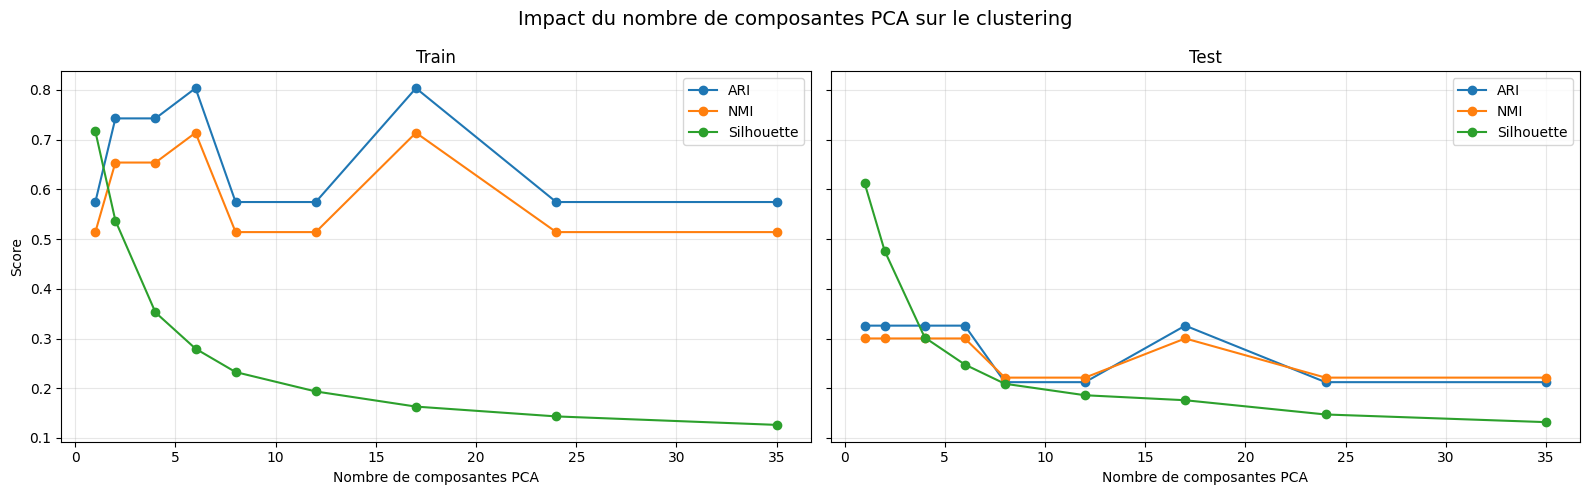

In [4001]:
# Résultats PCA train et test
df_pca_train = (
    df_pca_eval[df_pca_eval["split"] == "train"]
    .sort_values("n_components")
)

df_pca_test = (
    df_pca_eval[df_pca_eval["split"] == "test"]
    .sort_values("n_components")
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

# TRAIN
axes[0].plot(
    df_pca_train["n_components"],
    df_pca_train["ARI"],
    marker="o",
    label="ARI"
)

axes[0].plot(
    df_pca_train["n_components"],
    df_pca_train["NMI"],
    marker="o",
    label="NMI"
)

axes[0].plot(
    df_pca_train["n_components"],
    df_pca_train["Silhouette"],
    marker="o",
    label="Silhouette"
)

axes[0].set_title("Train")
axes[0].set_xlabel("Nombre de composantes PCA")
axes[0].set_ylabel("Score")
axes[0].grid(alpha=0.3)
axes[0].legend()

# TEST
axes[1].plot(
    df_pca_test["n_components"],
    df_pca_test["ARI"],
    marker="o",
    label="ARI"
)

axes[1].plot(
    df_pca_test["n_components"],
    df_pca_test["NMI"],
    marker="o",
    label="NMI"
)

axes[1].plot(
    df_pca_test["n_components"],
    df_pca_test["Silhouette"],
    marker="o",
    label="Silhouette"
)

axes[1].set_title("Test")
axes[1].set_xlabel("Nombre de composantes PCA")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.suptitle(
    "Impact du nombre de composantes PCA sur le clustering",
    fontsize=14
)

plt.tight_layout()
plt.show()

<h4 style="color:#48C9B0;">Impact du nombre de composantes PCA sur les performances du clustering</h4>

<p style="line-height:1.7;">
L'objectif de cette expérimentation est d'évaluer l'influence du niveau de réduction de dimension sur la qualité du clustering. Pour cela, plusieurs configurations PCA ont été testées puis évaluées à l'aide des métriques ARI, NMI et Silhouette sur les jeux d'entraînement et de test.
</p>

<p style="line-height:1.7;">
Sur le jeu d'entraînement, les meilleures performances sont obtenues avec <b>6 et 17 composantes</b>. Les scores ARI et NMI atteignent respectivement environ <b>0,80</b> et <b>0,71</b>, ce qui indique une bonne concordance entre les clusters générés et les labels réels disponibles. En parallèle, le score de silhouette diminue progressivement lorsque le nombre de composantes augmente, traduisant une séparation géométrique moins nette entre les groupes.
</p>

<p style="line-height:1.7;">
Sur le jeu de test, les performances restent globalement plus faibles, ce qui était attendu compte tenu du faible volume de données annotées disponible. Les meilleurs résultats sont observés avec <b>17 composantes</b>, où l'ARI atteint environ <b>0,32</b> et le NMI <b>0,30</b>. Les performances diminuent ensuite lorsque davantage de composantes sont conservées, suggérant que certaines dimensions supplémentaires réintroduisent du bruit ou des variations moins pertinentes pour la séparation des profils médicaux.
</p>

<p style="line-height:1.7;">
L'analyse conjointe des jeux d'entraînement et de test montre qu'une réduction trop faible entraîne une perte d'information utile, tandis qu'une réduction insuffisante conserve des caractéristiques secondaires susceptibles de perturber le clustering. La configuration à <b>17 composantes</b> apparaît ainsi comme le meilleur compromis entre conservation de l'information et capacité de généralisation.
</p>

<p style="line-height:1.7;">
Ces résultats confirment qu'une réduction de dimension est nécessaire avant l'étape de clustering. La représentation PCA retenue permet de simplifier les embeddings extraits par ResNet50 tout en préservant les structures les plus pertinentes pour distinguer les profils <i>Cancer</i> et <i>Normal</i>.
</p>

In [4002]:
pca = PCA(n_components=N_COMP_PCA,random_state=42)

# Apprentissage uniquement sur le train
train_pca = pca.fit_transform(train_scaled)

# Projection des autres jeux
val_pca = pca.transform(val_scaled)
test_pca = pca.transform(test_scaled)

print("Variance expliquée :",round(pca.explained_variance_ratio_.sum(), 4))
print("Nombre de composantes retenues :",pca.n_components_)

print("\nDimensions obtenues")
print("Train :", train_pca.shape)
print("Validation :", val_pca.shape)
print("Test :", test_pca.shape)


Variance expliquée : 0.7093
Nombre de composantes retenues : 17

Dimensions obtenues
Train : (59, 17)
Validation : (20, 17)
Test : (20, 17)


<div style="border-left: 5px solid #48C9B0; background-color: #f8fdfc; color: black; padding: 14px 18px; margin: 18px 0;">

<b>Objectif</b>

Cette visualisation a pour objectif d'explorer la structure des représentations apprises par ResNet50 à partir des images labellisées. Les embeddings extraits sont projetés dans un espace bidimensionnel grâce à l'Analyse en Composantes Principales (PCA), afin de visualiser la répartition des classes *Normal* et *Cancer*.

Cette étape permet d'évaluer qualitativement la capacité des caractéristiques extraites à séparer les deux profils médicaux avant les phases de réduction de dimension, de clustering et de pseudo-labellisation. Une séparation visible entre les groupes suggère que les embeddings capturent des informations discriminantes pertinentes pour la classification, tandis qu'un fort chevauchement indique une difficulté intrinsèque du problème ou la nécessité d'utiliser des méthodes non linéaires plus complexes.

</div>

La figure suivante présente la projection des embeddings ResNet50 sur les deux premières composantes principales de la PCA. Chaque point représente une image du jeu d'entraînement labellisé et sa couleur correspond à sa classe réelle (*Normal* ou *Cancer*). Cette représentation offre une première lecture visuelle de la structure des données dans l'espace des caractéristiques apprises par le réseau pré-entraîné.

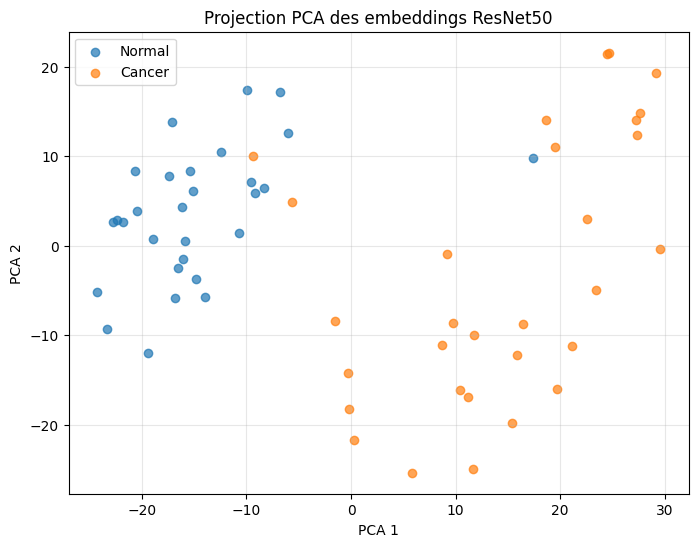

In [4003]:
# Projection PCA des embeddings
plt.figure(figsize=(8, 6))

classes = {
    0: "Normal",
    1: "Cancer"
}

for label, nom in classes.items():
    mask = train_labels == label

    plt.scatter(
        train_pca[mask, 0],
        train_pca[mask, 1],
        label=nom,
        alpha=0.7
    )

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Projection PCA des embeddings ResNet50")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

<h4 style="color:#48C9B0;">Interprétation des résultats</h4>

<p style="line-height:1.7;">
La projection des embeddings ResNet50 sur les deux premières composantes principales met en évidence une séparation visuelle marquée entre les images <i>Normal</i> et <i>Cancer</i>. La majorité des images normales se concentrent dans la partie gauche du graphique, tandis que les images cancéreuses occupent principalement la partie droite.
</p>

<p style="line-height:1.7;">
Cette organisation suggère que les caractéristiques extraites par ResNet50 capturent déjà une information fortement discriminante avant toute étape de clustering ou de classification supervisée. La première composante principale semble porter une part importante de la séparation entre les deux profils médicaux.
</p>

<p style="line-height:1.7;">
Quelques observations restent néanmoins situées à proximité de la frontière entre les groupes, traduisant l'existence de cas plus ambigus. Malgré cela, la structure globale demeure bien définie et confirme la pertinence des embeddings ResNet50 comme base de travail pour la réduction de dimension, le clustering et la génération de pseudo-labels.
</p>

<h4 style="color:#48C9B0;">3.3 UMAP</h4>

<div style="border-left:4px solid #48C9B0; background:#f8fdfc; color: black; padding:14px 18px; margin:18px 0;">

<b>Objectif</b><br><br>

<p style="line-height:1.7;">
Je souhaite évaluer l'impact du nombre de dimensions conservées par UMAP sur la qualité du clustering. Pour cela, je teste plusieurs représentations de taille croissante avant d'appliquer K-Means.
</p>

<p style="line-height:1.7;">
J'évalue chaque configuration à l'aide des métriques ARI, NMI et Silhouette sur les jeux d'entraînement, de validation et de test. Cette comparaison me permettra d'identifier la dimension UMAP offrant le meilleur compromis entre réduction de dimension, séparation des groupes et cohérence avec les labels réels.
</p>

</div>

In [4004]:
umap_dimensions = [2, 5, 10, 15, 20]

splits = {
    "train": (train_features, train_labels),
    "val": (val_features, val_labels),
    "test": (test_features, test_labels)
}

results_umap = []

for n_dim in umap_dimensions:

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(train_features)

    reducer = umap.UMAP(
        n_components=n_dim,
        n_neighbors=15,
        min_dist=0.1,
        metric="euclidean",
        random_state=42
    )

    train_umap = reducer.fit_transform(X_train_scaled)

    kmeans = KMeans(
        n_clusters=2,
        random_state=42,
        n_init=20
    )

    train_clusters = kmeans.fit_predict(train_umap)

    for split_name, (X, y) in splits.items():

        X_scaled = scaler.transform(X)
        X_umap = reducer.transform(X_scaled)

        clusters = kmeans.predict(X_umap)

        results_umap.append({
            "representation": f"umap_{n_dim}d",
            "split": split_name,
            "n_components": n_dim,
            "ARI": adjusted_rand_score(y, clusters),
            "NMI": normalized_mutual_info_score(y, clusters),
            "Silhouette": silhouette_score(X_umap, clusters)
        })

df_umap_eval = pd.DataFrame(results_umap)

df_umap_eval["score_global"] = (
    0.5 * df_umap_eval["ARI"]
    + 0.3 * df_umap_eval["NMI"]
    + 0.2 * df_umap_eval["Silhouette"]
)

df_umap_eval.sort_values(
    ["split", "score_global"],
    ascending=[True, False]
)

,representation,split,n_components,ARI,NMI,Silhouette,score_global
8,umap_10d,test,10,0.212272,0.221393,0.528224,0.278199
2,umap_2d,test,2,0.212272,0.221393,0.521616,0.276877
11,umap_15d,test,15,0.212272,0.221393,0.514768,0.275508
14,umap_20d,test,20,0.212272,0.221393,0.507550,0.274064
5,umap_5d,test,5,0.212272,0.221393,0.493657,0.271285
6,umap_10d,train,10,0.684342,0.602017,0.675481,0.657872
3,umap_5d,train,5,0.684342,0.602017,0.651779,0.653132
0,umap_2d,train,2,0.628269,0.555824,0.701049,0.621092
12,umap_20d,train,20,0.628269,0.555824,0.639140,0.608710
9,umap_15d,train,15,0.574564,0.514087,0.646525,0.570813


<h4 style="color:#48C9B0;">Interprétation des résultats</h4>

<p style="line-height:1.7;">
Les résultats montrent que les représentations UMAP produisent des clusters géométriquement bien séparés, avec des scores de silhouette élevés sur l'ensemble des configurations testées. La configuration UMAP à 10 dimensions obtient le meilleur score global sur les jeux de train, validation et test.
</p>

<p style="line-height:1.7;">
Cependant, les scores ARI et NMI restent faibles sur les jeux de validation et de test. Cela signifie que les groupes formés par UMAP sont compacts et bien séparés dans l'espace réduit, mais qu'ils ne correspondent pas suffisamment aux classes réelles <i>Normal</i> et <i>Cancer</i>.
</p>

<p style="line-height:1.7;">
Je retiens donc que UMAP est pertinent pour visualiser ou structurer localement les données, mais qu'il est moins fiable ici pour générer des pseudo-labels médicaux. Pour la suite, je privilégie une représentation PCA, plus stable pour les distances et plus cohérente avec l'objectif de pseudo-labellisation.
</p>

<div style="border-left:4px solid #48C9B0; background:#f8fdfc; color: black; padding:14px 18px; margin:18px 0;">

<b>Objectif</b><br><br>

<p style="line-height:1.7;">
Je visualise l'évolution des métriques ARI, NMI et Silhouette en fonction du nombre de dimensions conservées par UMAP sur le jeu de test.
</p>

<p style="line-height:1.7;">
Cette analyse me permet d'évaluer si l'augmentation de la dimension de l'espace UMAP améliore la qualité du clustering ou si une représentation plus compacte est suffisante. Les résultats m'aideront à identifier la configuration offrant le meilleur compromis entre séparation des groupes et cohérence avec les classes réelles.
</p>

</div>

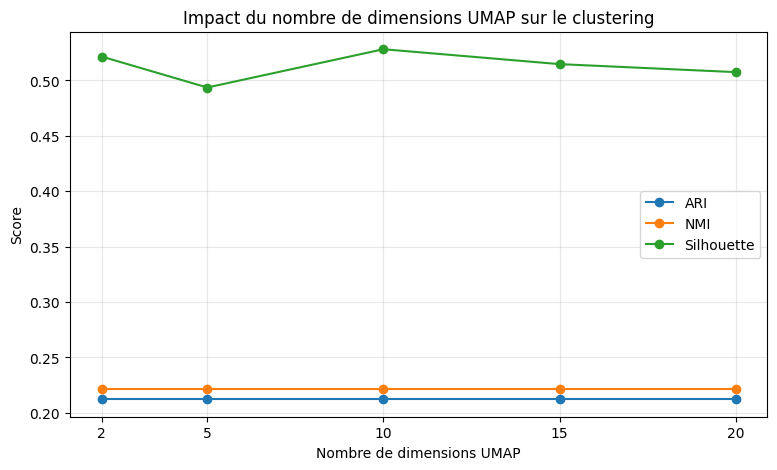

In [4005]:
df_umap_test = (
    df_umap_eval[df_umap_eval["split"] == "test"]
    .sort_values("n_components")
)

plt.figure(figsize=(9, 5))

plt.plot(df_umap_test["n_components"], df_umap_test["ARI"], marker="o", label="ARI")
plt.plot(df_umap_test["n_components"], df_umap_test["NMI"], marker="o", label="NMI")
plt.plot(df_umap_test["n_components"], df_umap_test["Silhouette"], marker="o", label="Silhouette")

plt.xlabel("Nombre de dimensions UMAP")
plt.ylabel("Score")
plt.title("Impact du nombre de dimensions UMAP sur le clustering")
plt.xticks(df_umap_test["n_components"])
plt.legend()
plt.grid(alpha=0.3)

plt.show()

<h4 style="color:#48C9B0;">Interprétation des résultats</h4>

<p style="line-height:1.7;">
Les scores ARI et NMI restent strictement identiques quelle que soit la dimension UMAP utilisée. L'augmentation du nombre de dimensions n'améliore donc pas la capacité du clustering à retrouver les classes réelles <i>Normal</i> et <i>Cancer</i>.
</p>

<p style="line-height:1.7;">
En revanche, le score de silhouette varie légèrement selon la configuration. La meilleure séparation géométrique des clusters est obtenue avec 10 dimensions, tandis que les autres configurations produisent des résultats très proches. Ces écarts restent toutefois limités et n'ont pas d'impact sur les performances de regroupement mesurées par l'ARI et le NMI.
</p>

<p style="line-height:1.7;">
Ces résultats suggèrent que l'augmentation de la dimension UMAP apporte peu d'information supplémentaire pour cette tâche. Malgré une bonne séparation géométrique des groupes, les clusters obtenus restent insuffisamment alignés avec les classes réelles, ce qui limite l'intérêt d'UMAP pour la génération de pseudo-labels dans ce projet.
</p>

In [4006]:
N_COMP_UMAP = 10

In [4007]:
umap_reducer = umap.UMAP(
    n_components=N_COMP_UMAP,
    n_neighbors=15,
    min_dist=0.1,
    metric="euclidean",
    random_state=42
)

# Apprentissage de l'espace UMAP uniquement sur le train

train_umap= umap_reducer.fit_transform(train_scaled)
# Projection des autres jeux dans le même espace
val_umap = umap_reducer.transform(val_scaled)
test_umap = umap_reducer.transform(test_scaled)

print("Train :", train_umap.shape)
print("Validation :", val_umap.shape)
print("Test :", test_umap.shape)

Train : (59, 10)
Validation : (20, 10)
Test : (20, 10)


<div style="border-left:4px solid #48C9B0; background:#f8fdfc; color: black; padding:14px 18px; margin:18px 0;">

<b>Objectif</b><br><br>

<p style="line-height:1.7;">
Je projette les embeddings dans un espace UMAP à deux dimensions afin de visualiser la répartition des images normales et cancéreuses. J'affiche simultanément les jeux d'entraînement, de validation et de test pour vérifier si la structure observée est cohérente sur l'ensemble des données.
</p>

<p style="line-height:1.7;">
Cette représentation me permet d'évaluer visuellement la capacité d'UMAP à séparer les deux profils médicaux et d'identifier d'éventuelles zones de chevauchement susceptibles de compliquer les étapes de clustering et de pseudo-labellisation.
</p>

</div>

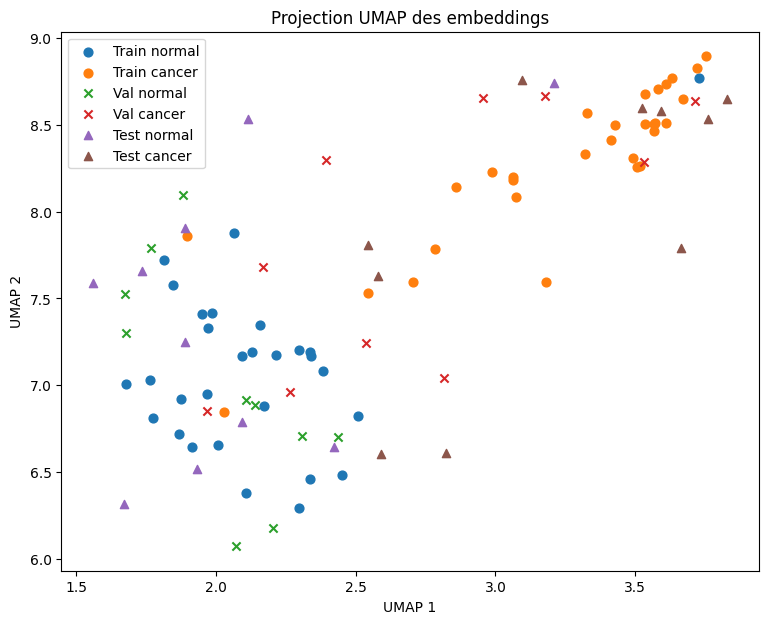

In [4008]:
plt.figure(figsize=(9, 7))

# Train labellisé
plt.scatter(
    train_umap[train_labels == 0, 0],
    train_umap[train_labels == 0, 1],
    label="Train normal",
    s=40
)

plt.scatter(
    train_umap[train_labels == 1, 0],
    train_umap[train_labels == 1, 1],
    label="Train cancer",
    s=40
)

# Validation labellisée
plt.scatter(
    val_umap[val_labels == 0, 0],
    val_umap[val_labels == 0, 1],
    label="Val normal",
    marker="x",
    s=35
)

plt.scatter(
    val_umap[val_labels == 1, 0],
    val_umap[val_labels == 1, 1],
    label="Val cancer",
    marker="x",
    s=35
)

# Test labellisé
plt.scatter(
    test_umap[test_labels == 0, 0],
    test_umap[test_labels == 0, 1],
    label="Test normal",
    marker="^",
    s=35
)

plt.scatter(
    test_umap[test_labels == 1, 0],
    test_umap[test_labels == 1, 1],
    label="Test cancer",
    marker="^",
    s=35
)

plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("Projection UMAP des embeddings")
plt.legend()
plt.show()

<h4 style="color:#48C9B0;">Interprétation des résultats</h4>

<p style="line-height:1.7;">
La projection UMAP met en évidence deux groupes principaux relativement distincts. Les images normales se concentrent majoritairement dans la partie gauche de la représentation, tandis que les images cancéreuses occupent principalement la partie droite. Cette organisation montre qu'UMAP parvient à préserver une partie de la structure discriminante présente dans les embeddings extraits par ResNet50.
</p>

<p style="line-height:1.7;">
Les observations issues des jeux d'entraînement, de validation et de test suivent globalement la même répartition dans l'espace projeté. Cela suggère que la transformation UMAP généralise correctement aux données non utilisées lors de son apprentissage et qu'aucun décalage majeur n'est observé entre les différents jeux de données.
</p>

<p style="line-height:1.7;">
Malgré cette séparation visuelle encourageante, plusieurs points des deux classes restent présents dans des zones communes. Ces recouvrements expliquent les scores ARI et NMI relativement faibles observés précédemment. UMAP facilite donc l'exploration visuelle des données, mais la séparation obtenue demeure insuffisante pour garantir une génération fiable de pseudo-labels basée uniquement sur cette représentation.
</p>

<h4 style="color:#48C9B0;">Pourquoi UMAP plutôt que t-SNE ?</h4>

<div style="border-left:5px solid #48C9B0;
            background:#f8fdfc;
            padding:14px 18px;
            margin:18px 0;
            color:black;">


<b style="color:black;">Justification méthodologique</b><br><br>

La méthode t-SNE a été envisagée pour la visualisation des embeddings. Toutefois, contrairement à UMAP, elle ne dispose pas d'une méthode permettant de projeter facilement de nouvelles observations dans un espace déjà appris.

Dans ce projet, il était nécessaire de projeter de manière cohérente les ensembles de validation, de test et les images non annotées dans le même espace que les données d'entraînement.

Pour cette raison, UMAP a été retenu comme méthode de visualisation principale. Il offre des performances comparables à t-SNE tout en permettant la transformation de nouvelles données après apprentissage.

</div>

<div style="
border-left:4px solid #48C9B0;
background:#f8fdfc;
padding:14px 18px;
color:black;
margin:18px 0;
">

<strong>Choix retenu</strong>

<p style="margin-top:10px; line-height:1.7;">

Pour la suite du projet et la génération des pseudo-labels, j’ai retenu la représentation <strong>PCA à 17 composantes</strong>.

Les expérimentations menées sur plusieurs niveaux de réduction de dimension montrent que cette configuration offre le meilleur compromis entre qualité du clustering et capacité de généralisation. Les scores ARI et NMI obtenus sur les données de test atteignent leur niveau maximal avec cette représentation, tandis que les performances diminuent lorsque davantage de composantes sont conservées.

Cette observation suggère qu'une réduction de dimension modérée permet de conserver l'information la plus discriminante tout en éliminant une partie du bruit et des variations secondaires présentes dans les embeddings extraits par ResNet50.

Dans le cadre de ce projet, la qualité du clustering conditionne directement la fiabilité des pseudo-labels utilisés lors de l'apprentissage semi-supervisé. La représentation à 17 composantes constitue ainsi le meilleur compromis observé entre simplification des données, stabilité du clustering et qualité des pseudo-labels générés.

</p>

</div>

In [4009]:
train_unla_pca = pca.transform(train_unla_scaled)
test_unla_pca = pca.transform(test_unla_scaled)

print("Variance expliquée :",round(pca.explained_variance_ratio_.sum(), 4))
print("Nombre de composantes retenues :",pca.n_components_)

print("Unlabeled train :", train_unla_pca.shape)
print("Unlabeled test :", test_unla_pca.shape)

Variance expliquée : 0.7093
Nombre de composantes retenues : 17
Unlabeled train : (917, 17)
Unlabeled test : (394, 17)


<div style="border-left:4px solid #48C9B0; background:#f8fdfc; color: black; padding:14px 18px; margin:18px 0;">

<b>Objectif</b><br><br>

<p style="line-height:1.7;">
Je projette dans l'espace PCA les images labellisées et non labellisées afin d'examiner leur répartition au sein des embeddings extraits par ResNet50.
</p>

<p style="line-height:1.7;">
Cette visualisation me permet de vérifier si les données non annotées occupent les mêmes régions de l'espace que les images labellisées. L'objectif est d'évaluer si les connaissances apprises à partir des données annotées pourront être transférées de manière pertinente lors des étapes de clustering et de pseudo-labellisation.
</p>

</div>

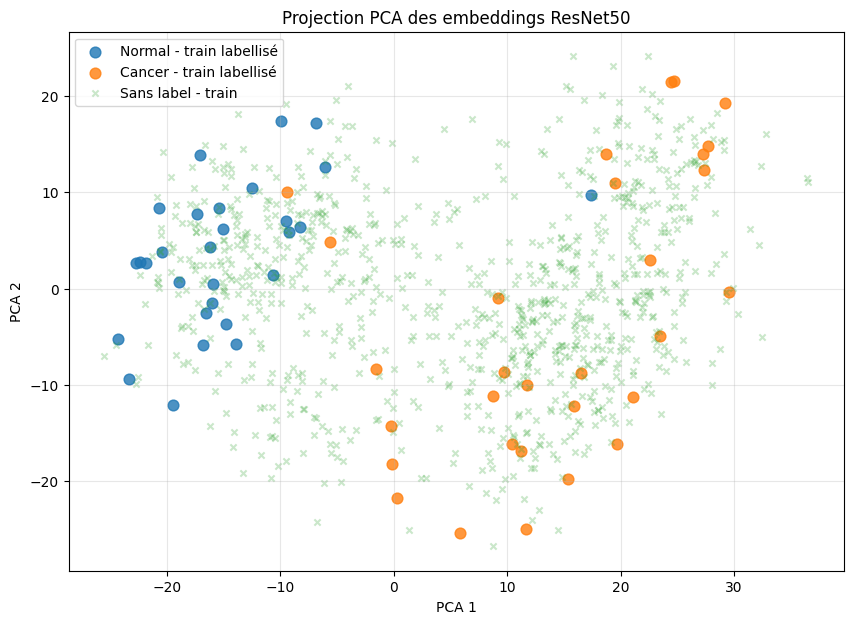

In [4010]:
# Projection PCA des embeddings
plt.figure(figsize=(10, 7))

classes = {
    0: "Normal",
    1: "Cancer"
}

# Données labellisées train
for label, nom in classes.items():
    mask = train_labels == label

    plt.scatter(
        train_pca[mask, 0],
        train_pca[mask, 1],
        label=f"{nom} - train labellisé",
        alpha=0.8,
        s=60
    )

# Données non labellisées train
plt.scatter(
    train_unla_pca[:, 0],
    train_unla_pca[:, 1],
    label="Sans label - train",
    alpha=0.25,
    s=20,
    marker="x"
)


plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Projection PCA des embeddings ResNet50")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

<h4 style="color:#48C9B0;">Interprétation des résultats</h4>

<p style="line-height:1.7;">
La projection PCA montre que les images non labellisées occupent globalement les mêmes régions de l'espace que les données annotées. Les deux zones principales identifiées à partir des classes <i>Normal</i> et <i>Cancer</i> sont également peuplées par un grand nombre d'observations non étiquetées.
</p>

<p style="line-height:1.7;">
Cette répartition suggère que les données non labellisées suivent une structure similaire à celle observée sur les données annotées. Les images sans label ne forment pas de groupe isolé ou atypique, ce qui constitue un signal favorable pour l'utilisation d'approches de clustering et de pseudo-labellisation.
</p>

<p style="line-height:1.7;">
La présence de nombreuses observations non annotées à proximité des régions occupées par les classes connues laisse penser qu'une partie importante de ces images pourra être associée à un profil probable avec un niveau de confiance satisfaisant. Cette observation conforte la pertinence d'exploiter les données non labellisées dans la suite du pipeline semi-supervisé.
</p>

<div style="border-left:5px solid #48C9B0;
            background:#f8fdfc;
            padding:14px 18px;
            margin:18px 0;
            color:black;">

<b style="color:black;">Conclusion</b><br><br>

La PCA a permis de réduire efficacement la dimension des embeddings extraits par ResNet50 tout en conservant l'information la plus pertinente pour la tâche de clustering.

À partir des 2048 variables initiales, la représentation retenue repose sur <b>17 composantes principales</b>. Cette réduction diminue fortement la complexité des données tout en conservant les structures les plus discriminantes des embeddings.

Les différentes expérimentations menées sur plusieurs niveaux de réduction de dimension ont montré que les performances de clustering variaient selon le nombre de composantes conservées. La configuration à <b>17 composantes</b> obtient les meilleurs résultats globaux sur les données de test, notamment selon les métriques ARI et NMI, traduisant une meilleure cohérence entre les clusters obtenus et les labels réels.

Cette observation suggère qu'une réduction de dimension plus importante permet d'éliminer une partie du bruit et des variations secondaires présentes dans les embeddings tout en conservant l'information utile à la séparation des profils <i>Cancer</i> et <i>Normal</i>.

Les jeux de validation, de test et les données non annotées ont ensuite été projetés dans ce même espace réduit à l'aide d'une PCA ajustée exclusivement sur les données d'entraînement, garantissant l'absence de fuite d'information.

Cette représentation PCA servira de base aux étapes de clustering, de génération des pseudo-labels et d'apprentissage semi-supervisé.

</div>

<h2 style="color:#48C9B0;">4 Clustering non supervisé</h2>

<h4 style="color:#48C9B0;">4.1 Kmeans</h4>

<div style="border-left:5px solid #48C9B0;
            background:#f8fdfc;
            padding:14px 18px;
            margin:18px 0;
            color:black;">

<b style="color:black;">Objectif</b><br><br>

<p style="line-height:1.7;">
Après avoir retenu la représentation PCA offrant le meilleur compromis entre réduction de dimension et qualité du clustering, j'applique un algorithme K-Means afin d'identifier automatiquement deux groupes dans les embeddings.
</p>

<p style="line-height:1.7;">
Le nombre de clusters est fixé à deux, car le problème étudié repose sur deux profils médicaux principaux : images normales et images cancéreuses. Le modèle est entraîné uniquement sur le jeu d'entraînement PCA afin d'éviter toute fuite d'information.
</p>

<p style="line-height:1.7;">
Les clusters appris sont ensuite prédits sur les jeux d'entraînement, de validation et de test. J'évalue les résultats à l'aide de l'ARI, du NMI et du score de silhouette afin de mesurer à la fois la cohérence entre les clusters et les labels réels, ainsi que la qualité géométrique des groupes obtenus.
</p>

</div>

<h4 style="color:#48C9B0;">Évaluation du clustering K-Means sur PCA</h4>

<p style="line-height:1.7;">
Cette étape permet de vérifier si les groupes découverts automatiquement par K-Means reflètent la séparation observée entre les images normales et cancéreuses. Une cohérence suffisante entre clusters et labels réels est nécessaire avant d'utiliser ce modèle pour générer des pseudo-labels sur les données non annotées.
</p>

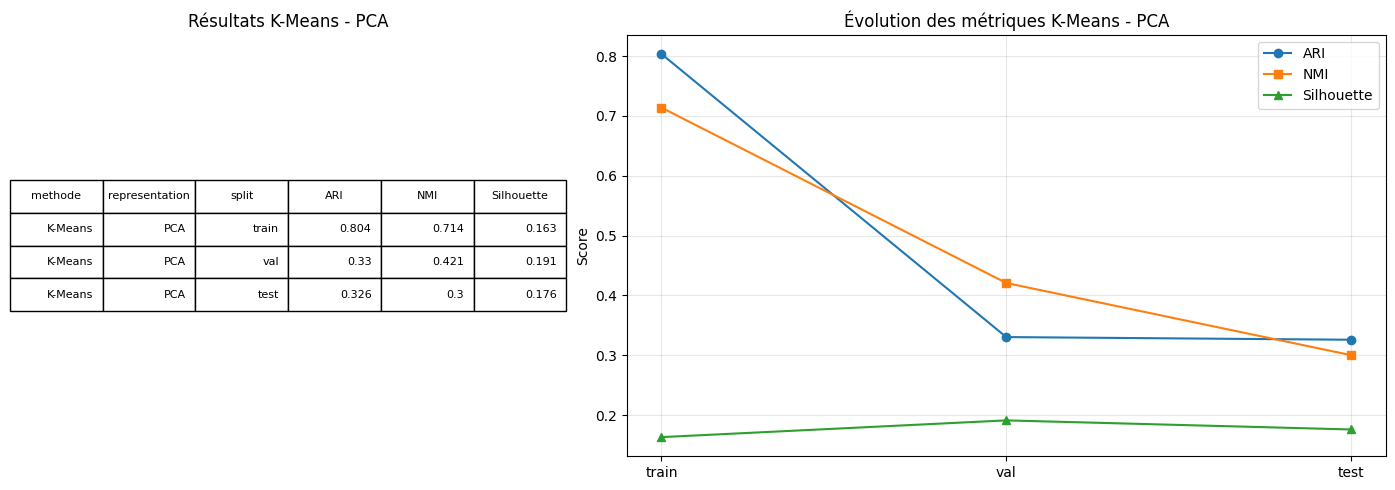

In [4011]:
# K-Means sur la représentation PCA retenue
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=20
)

# Apprentissage uniquement sur le train PCA
kmeans.fit(train_pca)

kmeans_results = []

for split_name, X, y in [
    ("train", train_pca, train_labels),
    ("val", val_pca, val_labels),
    ("test", test_pca, test_labels)
]:

    clusters = kmeans.predict(X)

    kmeans_results.append({
        "methode": "K-Means",
        "representation": "PCA",
        "split": split_name,
        "ARI": adjusted_rand_score(y, clusters),
        "NMI": normalized_mutual_info_score(y, clusters),
        "Silhouette": silhouette_score(X, clusters)
    })

df_kmeans = pd.DataFrame(kmeans_results)

# Tableau + courbes K-Means
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5),
    gridspec_kw={"width_ratios": [1.2, 1.8]}
)

# Tableau
axes[0].axis("off")

table_data = df_kmeans.round(3)

table = axes[0].table(
    cellText=table_data.values,
    colLabels=table_data.columns,
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1.1, 1.8)

axes[0].set_title("Résultats K-Means - PCA")

# Courbes
axes[1].plot(
    df_kmeans["split"],
    df_kmeans["ARI"],
    marker="o",
    label="ARI"
)

axes[1].plot(
    df_kmeans["split"],
    df_kmeans["NMI"],
    marker="s",
    label="NMI"
)

axes[1].plot(
    df_kmeans["split"],
    df_kmeans["Silhouette"],
    marker="^",
    label="Silhouette"
)

axes[1].set_ylabel("Score")
axes[1].set_title("Évolution des métriques K-Means - PCA")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

<h4 style="color:#48C9B0;">Analyse des performances de K-Means sur les embeddings PCA</h4>

<p style="line-height:1.7;">
Les résultats montrent que l'algorithme K-Means parvient à identifier une structure cohérente au sein des embeddings réduits par PCA. Sur le jeu d'entraînement, les performances sont élevées avec un <b>ARI de 0,804</b> et un <b>NMI de 0,714</b>, indiquant une forte concordance entre les clusters obtenus et les labels réels. Cette observation suggère que les représentations extraites par ResNet50 contiennent suffisamment d'information pour distinguer les deux profils médicaux.
</p>

<p style="line-height:1.7;">
Les performances diminuent sur les jeux de validation et de test, avec un <b>ARI d'environ 0,33</b> et un <b>NMI compris entre 0,30 et 0,42</b>. Cette baisse était attendue compte tenu du faible nombre d'images annotées disponibles et traduit une capacité de généralisation plus limitée du clustering sur des données non utilisées lors de son apprentissage.
</p>

<p style="line-height:1.7;">
Les scores de silhouette restent relativement stables entre les différents jeux de données, avec des valeurs comprises entre <b>0,16</b> et <b>0,19</b>. Bien que ces scores demeurent modestes, ils indiquent l'existence d'une séparation partielle entre les groupes dans l'espace PCA. Cette situation est cohérente avec la nature des données médicales, où les frontières entre profils normaux et cancéreux ne sont pas parfaitement distinctes.
</p>


<h4 style="color:#48C9B0;">4.2 Clustering hiérarchique</h4>

<div style="border-left:4px solid #48C9B0; background:#f8fdfc; color: black; padding:14px 18px; margin:18px 0;">

<b>Objectif</b><br><br>

<p style="line-height:1.7;">
Je teste plusieurs variantes de clustering hiérarchique sur la représentation PCA retenue afin de comparer leur capacité à regrouper automatiquement les images en deux classes.
</p>

<p style="line-height:1.7;">
Les méthodes <i>ward</i>, <i>complete</i> et <i>average</i> sont évaluées séparément sur les jeux d'entraînement, de validation et de test. L'objectif est d'identifier le type de liaison qui produit les groupes les plus cohérents avec les labels réels.
</p>

<p style="line-height:1.7;">
J'utilise l'ARI, le NMI et le score de silhouette pour mesurer à la fois la correspondance avec les classes <i>Normal</i> et <i>Cancer</i> et la qualité géométrique des clusters. Cette comparaison permet de situer les performances du clustering hiérarchique par rapport à K-Means.
</p>

</div>

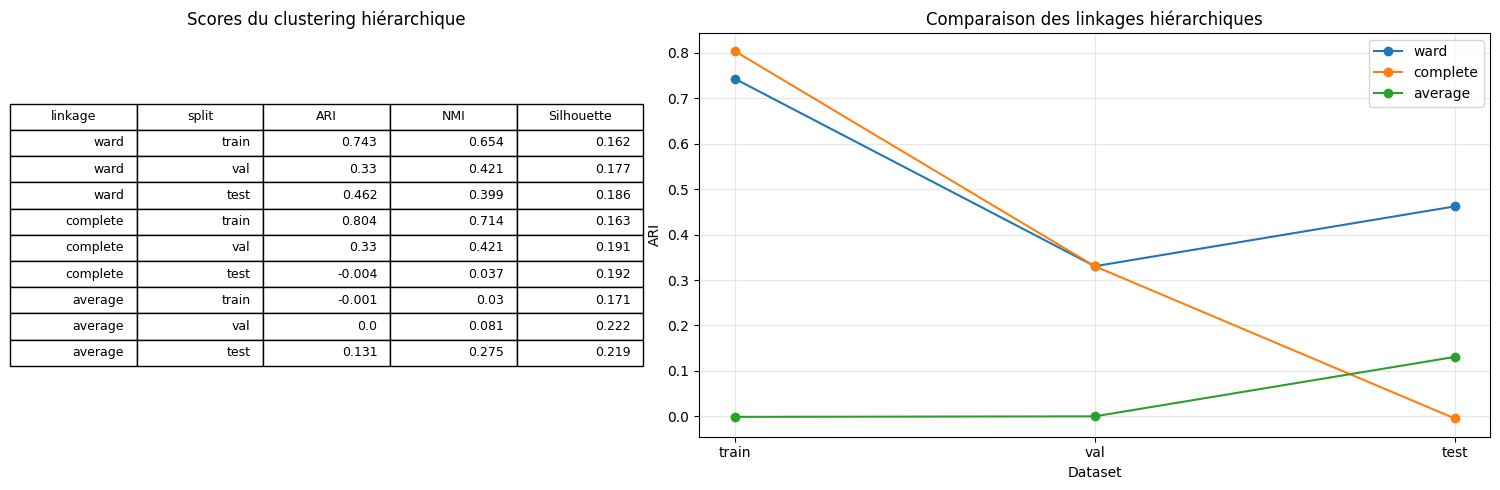

In [4012]:
# Clustering hiérarchique + tableau + graphique
# Représentation PCA retenue
linkages = ["ward", "complete", "average"]

hierarchical_results = []

for linkage in linkages:

    for split_name, X, y in [
        ("train", train_pca, train_labels),
        ("val", val_pca, val_labels),
        ("test", test_pca, test_labels)
    ]:
        model = AgglomerativeClustering(
            n_clusters=2,
            linkage=linkage
        )

        clusters = model.fit_predict(X)

        hierarchical_results.append({
            "methode": f"Hiérarchique - {linkage}",
            "linkage": linkage,
            "split": split_name,
            "ARI": adjusted_rand_score(y, clusters),
            "NMI": normalized_mutual_info_score(y, clusters),
            "Silhouette": silhouette_score(X, clusters)
        })

df_hierarchical = pd.DataFrame(hierarchical_results)

# Affichage tableau + graphique côte à côte
fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 5),
    gridspec_kw={"width_ratios": [1.2, 1.8]}
)

# Tableau
axes[0].axis("off")

table_data = df_hierarchical[
    ["linkage", "split", "ARI", "NMI", "Silhouette"]
].round(3)

table = axes[0].table(
    cellText=table_data.values,
    colLabels=table_data.columns,
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.5)

axes[0].set_title("Scores du clustering hiérarchique")

# Graphique ARI par linkage
for linkage in linkages:
    data = df_hierarchical[
        df_hierarchical["linkage"] == linkage
    ]

    axes[1].plot(
        data["split"],
        data["ARI"],
        marker="o",
        label=linkage
    )

axes[1].set_xlabel("Dataset")
axes[1].set_ylabel("ARI")
axes[1].set_title("Comparaison des linkages hiérarchiques")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()


<h4 style="color:#48C9B0;">Analyse du clustering hiérarchique</h4>

<p style="line-height:1.7;">
Trois méthodes de clustering hiérarchique ont été comparées : <b>Ward</b>, <b>Complete</b> et <b>Average</b>. Les résultats montrent que les approches <b>Ward</b> et <b>Complete</b> obtiennent de bonnes performances sur les données d'entraînement, tandis que la méthode <b>Average</b> ne parvient pas à retrouver efficacement la structure des classes.
</p>

<p style="line-height:1.7;">
Sur le jeu de test, la méthode <b>Ward</b> se distingue avec un <b>ARI de 0,462</b> et un <b>NMI de 0,399</b>, soit les meilleurs résultats parmi les approches hiérarchiques évaluées. Ces scores sont également supérieurs à ceux obtenus avec K-Means, ce qui suggère une meilleure capacité à capturer certaines structures présentes dans les embeddings.
</p>

<p style="line-height:1.7;">
Les scores de silhouette restent toutefois modestes pour l'ensemble des méthodes, indiquant une séparation géométrique limitée entre les groupes dans l'espace PCA.
</p>

<p style="line-height:1.7;">
La méthode <b>Ward</b> apparaît ainsi comme l'approche hiérarchique la plus robuste. Néanmoins, contrairement à K-Means, elle ne permet pas d'attribuer facilement un cluster à de nouvelles observations. Malgré ses meilleures performances de clustering, elle n'a donc pas été retenue pour la pseudo-labellisation des images non annotées.
</p>

<h4 style="color:#48C9B0;">4.3 DBSCAN</h4>

<div style="border-left:4px solid #48C9B0; background:#f8fdfc; color: black; padding:14px 18px; margin:18px 0;">

<b>Objectif</b><br><br>

<p style="line-height:1.7;">
Je souhaite évaluer les performances de DBSCAN sur la représentation PCA retenue en testant différentes combinaisons de paramètres <i>eps</i> et <i>min_samples</i>.
</p>

<p style="line-height:1.7;">
Contrairement à K-Means ou au clustering hiérarchique, DBSCAN ne nécessite pas de fixer le nombre de clusters à l'avance et peut identifier automatiquement des observations atypiques considérées comme du bruit.
</p>

<p style="line-height:1.7;">
J'analyse les résultats obtenus sur les jeux d'entraînement, de validation et de test afin d'identifier les configurations les plus stables. Les performances sont évaluées à l'aide de l'ARI, du NMI, du score de silhouette ainsi que du taux d'observations classées comme bruit.
</p>

</div>

In [4013]:
# DBSCAN : recherche des meilleurs couples eps / min_samples
# avec résultats valides sur train, validation et test
eps_values = [0.1, 0.2, 0.3, 0.5, 0.8, 1, 1.5, 2, 3]
min_samples_values = [3, 5, 10]

dbscan_results = []

for eps in eps_values:
    for min_samples in min_samples_values:

        for split_name, X, y in [
            ("train", train_pca, train_labels),
            ("val", val_pca, val_labels),
            ("test", test_pca, test_labels)
        ]:
            model = DBSCAN(
                eps=eps,
                min_samples=min_samples
            )

            clusters = model.fit_predict(X)

            n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
            noise_rate = np.mean(clusters == -1)

            if n_clusters > 1:
                ari = adjusted_rand_score(y, clusters)
                nmi = normalized_mutual_info_score(y, clusters)
                silhouette = silhouette_score(X, clusters)
            else:
                ari = np.nan
                nmi = np.nan
                silhouette = np.nan

            dbscan_results.append({
                "methode": "DBSCAN",
                "split": split_name,
                "eps": eps,
                "min_samples": min_samples,
                "n_clusters": n_clusters,
                "noise_rate": noise_rate,
                "ARI": ari,
                "NMI": nmi,
                "Silhouette": silhouette
            })

df_dbscan = pd.DataFrame(dbscan_results)

# Conservation uniquement des résultats valides
df_dbscan_valid = df_dbscan.dropna(
    subset=["ARI", "NMI", "Silhouette"]
).copy()

# Sélection des couples présents sur train, val et test
configs_completes = (
    df_dbscan_valid
    .groupby(["eps", "min_samples"])["split"]
    .nunique()
    .reset_index()
)

configs_completes = configs_completes[
    configs_completes["split"] == 3
][["eps", "min_samples"]]

df_dbscan_complete = df_dbscan_valid.merge(
    configs_completes,
    on=["eps", "min_samples"],
    how="inner"
)

# Classement des couples eps / min_samples
df_dbscan_resume = (
    df_dbscan_complete
    .groupby(["eps", "min_samples"], as_index=False)
    .agg({
        "ARI": "mean",
        "NMI": "mean",
        "Silhouette": "mean",
        "noise_rate": "mean"
    })
    .rename(columns={
        "ARI": "ARI_moyen",
        "NMI": "NMI_moyen",
        "Silhouette": "Silhouette_moyenne",
        "noise_rate": "noise_rate_moyen"
    })
)

top3_configs = (
    df_dbscan_resume
    .sort_values(
        ["ARI_moyen", "NMI_moyen", "Silhouette_moyenne"],
        ascending=False
    )
    .head(3)[["eps", "min_samples"]]
)

df_dbscan_top3 = (
    df_dbscan_complete
    .merge(
        top3_configs,
        on=["eps", "min_samples"],
        how="inner"
    )
    .sort_values(["eps", "min_samples", "split"])
)

df_dbscan_top3.round(3)

,methode,split,eps,min_samples,n_clusters,noise_rate,ARI,NMI,Silhouette


<h4 style="color:#48C9B0;">Interprétation des résultats</h4>

<p style="line-height:1.7;">
Aucune configuration de paramètres testée n'a permis à DBSCAN de produire simultanément des résultats exploitables sur les jeux d'entraînement, de validation et de test. Le tableau des meilleures configurations est vide, ce qui indique que les combinaisons de <i>eps</i> et <i>min_samples</i> évaluées n'ont pas généré au moins deux clusters cohérents sur l'ensemble des jeux de données.
</p>

<p style="line-height:1.7;">
Ce comportement suggère que les données projetées dans l'espace PCA ne présentent pas de zones de densité suffisamment marquées pour être correctement séparées par une approche basée sur la densité. DBSCAN tend probablement à fusionner les observations dans un unique groupe ou, au contraire, à considérer une part importante des données comme du bruit.
</p>

<p style="line-height:1.7;">
Dans ce contexte, DBSCAN apparaît moins adapté que K-Means ou le clustering hiérarchique pour identifier la structure des embeddings ResNet50. Cette méthode ne sera donc pas retenue pour la génération des pseudo-labels, les résultats obtenus étant insuffisamment stables et interprétables.
</p>

<h4 style="color:#48C9B0;">4.5 Pour aller plus loin : Spectral Clustering </h4>

<div style="border-left:4px solid #48C9B0; background:#f8fdfc; color: black; padding:14px 18px; margin:18px 0;">

<b>Objectif</b><br><br>

<p style="line-height:1.7;">
Je teste le Spectral Clustering sur la représentation PCA retenue afin d'évaluer une méthode capable de détecter des structures potentiellement non linéaires dans les embeddings.
</p>

<p style="line-height:1.7;">
Le nombre de clusters est fixé à deux pour rester cohérent avec la distinction attendue entre images normales et cancéreuses. Les performances sont mesurées sur les jeux d'entraînement, de validation et de test avec l'ARI, le NMI et le score de silhouette.
</p>

<p style="line-height:1.7;">
Cette comparaison me permet de vérifier si une approche fondée sur les relations de voisinage améliore la cohérence des clusters par rapport aux méthodes précédentes.
</p>

</div>

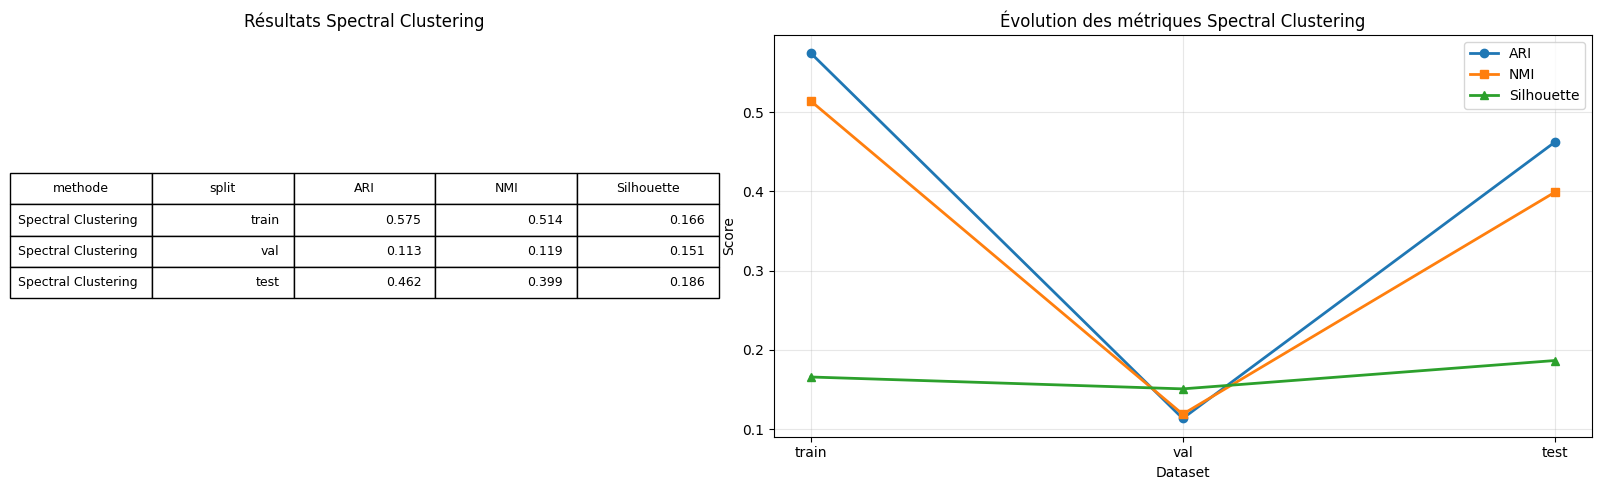

In [4014]:
from sklearn.cluster import SpectralClustering

spectral_results = []

for split_name, X, y in [
    ("train", train_pca, train_labels),
    ("val", val_pca, val_labels),
    ("test", test_pca, test_labels)
]:
    model = SpectralClustering(
        n_clusters=2,
        affinity="nearest_neighbors",
        random_state=42
    )

    clusters = model.fit_predict(X)

    spectral_results.append({
        "methode": "Spectral Clustering",
        "split": split_name,
        "ARI": adjusted_rand_score(y, clusters),
        "NMI": normalized_mutual_info_score(y, clusters),
        "Silhouette": silhouette_score(X, clusters)
    })

df_spectral = pd.DataFrame(spectral_results)

# Tableau + courbes Spectral Clustering
fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 5),
    gridspec_kw={"width_ratios": [1.3, 1.8]}
)

# Tableau
axes[0].axis("off")

table_data = df_spectral.round(3)

table = axes[0].table(
    cellText=table_data.values,
    colLabels=table_data.columns,
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.8)

axes[0].set_title("Résultats Spectral Clustering")

# Courbes
axes[1].plot(
    df_spectral["split"],
    df_spectral["ARI"],
    marker="o",
    linewidth=2,
    label="ARI"
)

axes[1].plot(
    df_spectral["split"],
    df_spectral["NMI"],
    marker="s",
    linewidth=2,
    label="NMI"
)

axes[1].plot(
    df_spectral["split"],
    df_spectral["Silhouette"],
    marker="^",
    linewidth=2,
    label="Silhouette"
)

axes[1].set_xlabel("Dataset")
axes[1].set_ylabel("Score")
axes[1].set_title(
    "Évolution des métriques Spectral Clustering"
)

axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

<h4 style="color:#48C9B0;">Analyse du Spectral Clustering</h4>

<p style="line-height:1.7;">
Le Spectral Clustering a été évalué afin d'explorer une approche capable de capturer des relations plus complexes entre les observations. Les résultats obtenus sur le jeu d'entraînement restent corrects, avec un <b>ARI de 0,575</b> et un <b>NMI de 0,514</b>, mais demeurent inférieurs à ceux observés avec K-Means et le clustering hiérarchique de type Ward.
</p>

<p style="line-height:1.7;">
Les performances chutent fortement sur le jeu de validation avant de remonter sur le jeu de test, où l'algorithme atteint un <b>ARI de 0,462</b> et un <b>NMI de 0,399</b>. Ces résultats sont comparables à ceux obtenus avec la méthode Ward et supérieurs à ceux de K-Means, suggérant l'existence d'une structure exploitable dans les embeddings.
</p>

<p style="line-height:1.7;">
Les scores de silhouette restent toutefois faibles, indiquant une séparation géométrique limitée entre les groupes dans l'espace PCA. Cette situation est cohérente avec la complexité des données médicales et le chevauchement partiel entre les deux profils étudiés.
</p>

<p style="line-height:1.7;">
Malgré des performances intéressantes sur le jeu de test, le Spectral Clustering ne dispose pas d'un mécanisme simple permettant d'attribuer un cluster à de nouvelles observations. Pour cette raison, il n'a pas été retenu pour la pseudo-labellisation des images non annotées, K-Means restant plus adapté aux besoins du pipeline semi-supervisé.
</p>

<h4 style="color:#48C9B0;">4.6 Le choix du modele de clustering</h4>

<div style="border-left:4px solid #48C9B0; background:#f8fdfc; color: black; padding:14px 18px; margin:18px 0;">

<b>Objectif</b><br><br>

<p style="line-height:1.7;">
Je rassemble les meilleurs résultats obtenus par chaque algorithme de clustering sur le jeu d'entraînement afin de comparer directement leurs performances dans les mêmes conditions.
</p>

<p style="line-height:1.7;">
Cette comparaison permet d'identifier les méthodes les plus capables de retrouver la structure réelle des classes à partir des embeddings projetés par la PCA. Les métriques ARI, NMI et Silhouette sont utilisées pour évaluer simultanément la cohérence avec les labels et la qualité géométrique des groupes.
</p>

<p style="line-height:1.7;">
L'objectif est de disposer d'une vue d'ensemble des performances avant de sélectionner la méthode la plus adaptée à la génération des pseudo-labels.
</p>

</div>

In [4015]:
best_dbscan_train = (
    df_dbscan[df_dbscan["split"] == "train"]
    .sort_values(
        ["ARI", "NMI", "Silhouette"],
        ascending=False
    )
    .iloc[[0]]
)

comparatif_final_train = pd.concat([
    df_kmeans[df_kmeans["split"] == "train"],
    df_hierarchical[df_hierarchical["split"] == "train"],
    best_dbscan_train,
    df_spectral[df_spectral["split"] == "train"]
])

comparatif_final_train = comparatif_final_train.reset_index(drop=True)

<div style="border-left:4px solid #48C9B0; background:#f8fdfc; color: black; padding:14px 18px; margin:18px 0;">

<b>Objectif</b><br><br>

<p style="line-height:1.7;">
Je compare les performances des différents algorithmes de clustering sur le jeu de test afin d'évaluer leur capacité à généraliser sur des données jamais vues durant leur construction.
</p>

<p style="line-height:1.7;">
Pour chaque méthode, je conserve la meilleure configuration identifiée lors des expérimentations précédentes. Les performances sont comparées à l'aide des métriques ARI, NMI et Silhouette afin d'évaluer simultanément la cohérence avec les labels réels et la qualité de séparation des groupes.
</p>

<p style="line-height:1.7;">
Cette comparaison finale me permet d'identifier les approches les plus performantes et de justifier le choix de la méthode qui sera utilisée pour la génération des pseudo-labels.
</p>

</div>

In [4016]:
best_dbscan_test = (
    df_dbscan[df_dbscan["split"] == "test"]
    .sort_values(
        ["ARI", "NMI", "Silhouette"],
        ascending=False
    )
    .iloc[[0]]
)

comparatif_final_test = pd.concat([
    df_kmeans[df_kmeans["split"] == "test"],
    df_hierarchical[df_hierarchical["split"] == "test"],
    best_dbscan_test,
    df_spectral[df_spectral["split"] == "test"]
])

comparatif_final_test = comparatif_final_test.reset_index(drop=True)


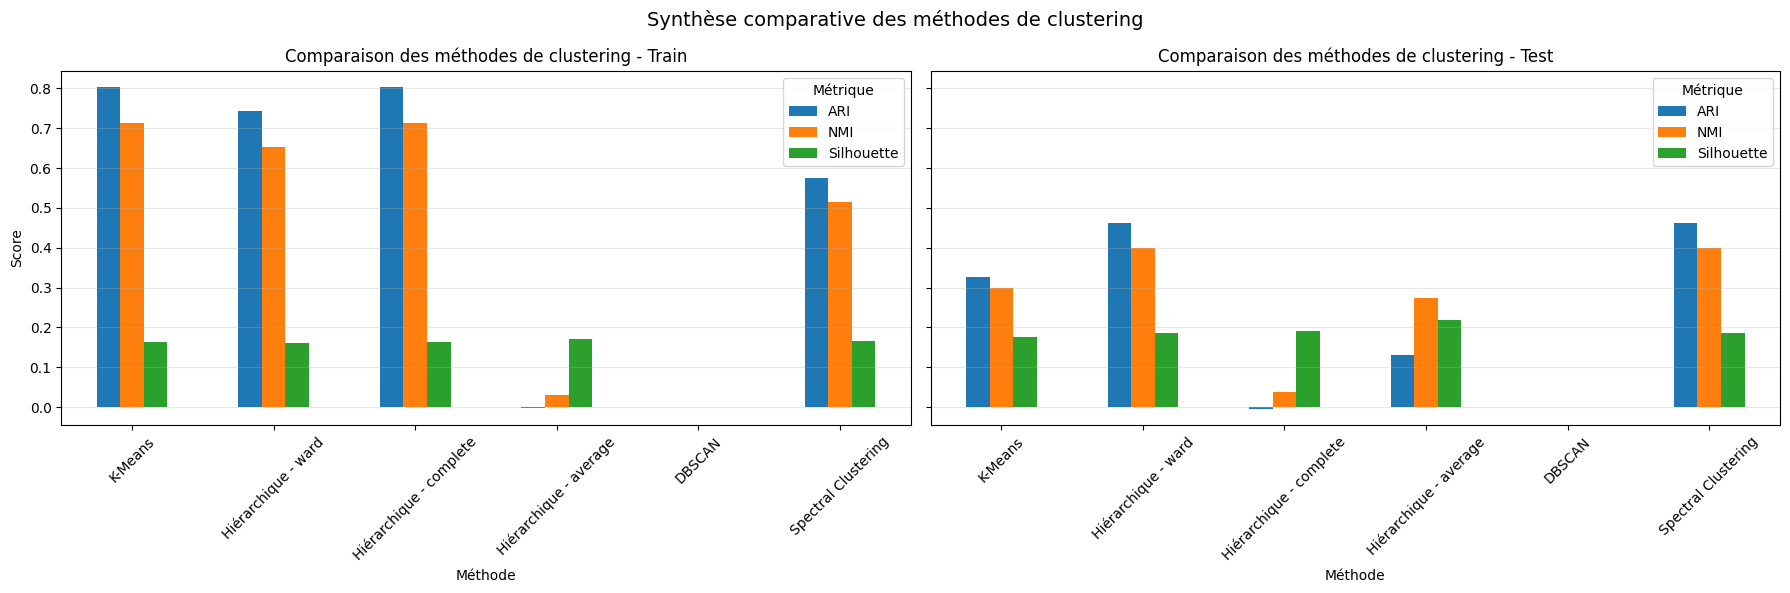

In [4017]:
# Préparation des données
comparatif_final_train_plot = comparatif_final_train.copy()
comparatif_final_test_plot = comparatif_final_test.reset_index(drop=True).copy()

# Noms plus lisibles si besoin
comparatif_final_train_plot["methode"] = comparatif_final_train_plot["methode"].fillna("DBSCAN")
comparatif_final_test_plot["methode"] = comparatif_final_test_plot["methode"].fillna("DBSCAN")

metrics = ["ARI", "NMI", "Silhouette"]

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

# Train
comparatif_final_train_plot.set_index("methode")[metrics].plot(
    kind="bar",
    ax=axes[0]
)

axes[0].set_title("Comparaison des méthodes de clustering - Train")
axes[0].set_xlabel("Méthode")
axes[0].set_ylabel("Score")
axes[0].tick_params(axis="x", rotation=45)
axes[0].grid(axis="y", alpha=0.3)
axes[0].legend(title="Métrique")

# Test
comparatif_final_test_plot.set_index("methode")[metrics].plot(
    kind="bar",
    ax=axes[1]
)

axes[1].set_title("Comparaison des méthodes de clustering - Test")
axes[1].set_xlabel("Méthode")
axes[1].tick_params(axis="x", rotation=45)
axes[1].grid(axis="y", alpha=0.3)
axes[1].legend(title="Métrique")

plt.suptitle("Synthèse comparative des méthodes de clustering", fontsize=14)
plt.tight_layout()
plt.show()

<h4 style="color:#48C9B0;">Comparaison des méthodes de clustering</h4>

<p style="line-height:1.7;">
Plusieurs approches de clustering ont été évaluées sur les embeddings réduits par PCA afin d'identifier la méthode la plus adaptée à la génération de pseudo-labels.
</p>

<p style="line-height:1.7;">
Sur le jeu d'entraînement, <b>K-Means</b> et le clustering hiérarchique avec liaison <b>Complete</b> obtiennent les meilleurs résultats avec un <b>ARI de 0,804</b> et un <b>NMI de 0,714</b>. La méthode <b>Ward</b> présente également de bonnes performances, tandis que <b>Average</b> et <b>DBSCAN</b> ne parviennent pas à retrouver correctement la structure des données.
</p>

<p style="line-height:1.7;">
Sur le jeu de test, les meilleures performances sont obtenues par <b>Ward</b> et <b>Spectral Clustering</b>, avec un <b>ARI de 0,462</b> et un <b>NMI de 0,399</b>. K-Means reste légèrement en retrait avec un <b>ARI de 0,326</b> et un <b>NMI de 0,300</b>, mais conserve une cohérence satisfaisante avec les labels réels. Les méthodes <b>Complete</b> et <b>Average</b> montrent une généralisation plus limitée malgré des scores de silhouette parfois supérieurs.
</p>

<p style="line-height:1.7;">
Les scores de silhouette demeurent globalement faibles pour l'ensemble des méthodes, indiquant que les frontières entre les profils <i>Cancer</i> et <i>Normal</i> restent partiellement chevauchantes dans l'espace PCA. Cette observation est cohérente avec la complexité des données médicales étudiées.
</p>

<p style="line-height:1.7;">
Bien que <b>Ward</b> et <b>Spectral Clustering</b> obtiennent les meilleurs scores sur le jeu de test, <b>K-Means</b> a été retenu pour la suite du projet. Contrairement aux autres méthodes, il permet d'attribuer directement un cluster à de nouvelles observations grâce à sa fonction de prédiction. Cette propriété est indispensable pour pseudo-labelliser automatiquement les plus de 1 300 images non annotées utilisées dans l'approche semi-supervisée.
</p>

<h4 style="color:#48C9B0;">Choix du modèle de clustering retenu</h4>

<p style="line-height:1.7;">
Cependant, l'objectif du projet ne se limite pas à évaluer la qualité du clustering sur les données annotées. Le modèle retenu doit également permettre d'attribuer automatiquement un cluster aux <b>1 300+ images non annotées</b> afin de générer des pseudo-labels exploitables dans l'approche semi-supervisée.
</p>

<p style="line-height:1.7;">
Dans ce contexte, <b>K-Means</b> présente un avantage déterminant : il dispose d'une fonction de prédiction permettant d'affecter directement de nouvelles observations à l'un des clusters appris à partir des données d'entraînement. À l'inverse, les méthodes hiérarchiques et Spectral Clustering ne permettent pas naturellement cette étape sans mécanisme supplémentaire ou réentraînement complet.
</p>

<p style="line-height:1.7;">
Au regard de ces éléments, <b>K-Means est retenu pour la suite du projet</b>. Ce choix privilégie un compromis entre qualité du clustering, simplicité d'utilisation et capacité à pseudo-labelliser efficacement de nouvelles images, ce qui constitue une étape essentielle de l'approche semi-supervisée mise en œuvre.
</p>

<h4 style="color:#48C9B0;">4.2 Nombre de clusters pour K-Means</h4>

<div style="border-left:4px solid #48C9B0; background:#f8fdfc; color: black; padding:14px 18px; margin:18px 0;">

<b>Objectif</b><br><br>

<p style="line-height:1.7;">
Je cherche à déterminer le nombre de clusters le plus adapté aux embeddings projetés par la PCA. Pour cela, j'évalue plusieurs valeurs de <i>k</i> à l'aide du score de silhouette calculé sur le jeu d'entraînement.
</p>

<p style="line-height:1.7;">
Le score de silhouette mesure à la fois la compacité des clusters et leur séparation. Une valeur élevée indique que les observations sont proches des points de leur propre groupe et éloignées des autres clusters.
</p>

<p style="line-height:1.7;">
Cette analyse me permet de vérifier si le choix de deux clusters est cohérent avec la structure des données ou si un nombre différent de groupes pourrait mieux représenter l'organisation naturelle des embeddings.
</p>

</div>

In [4018]:
kmeans_results = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    clusters = kmeans.fit_predict(train_pca)

    kmeans_results.append({
        "k": k,
        "silhouette_score": silhouette_score(
            train_pca,
            clusters
        )
    })

df_kmeans_results = pd.DataFrame(kmeans_results)
display(df_kmeans_results)

,k,silhouette_score
0,2,0.163171
1,3,0.163677
2,4,0.145581
3,5,0.139531
4,6,0.151747
5,7,0.152587
6,8,0.164727
7,9,0.171623
8,10,0.184315


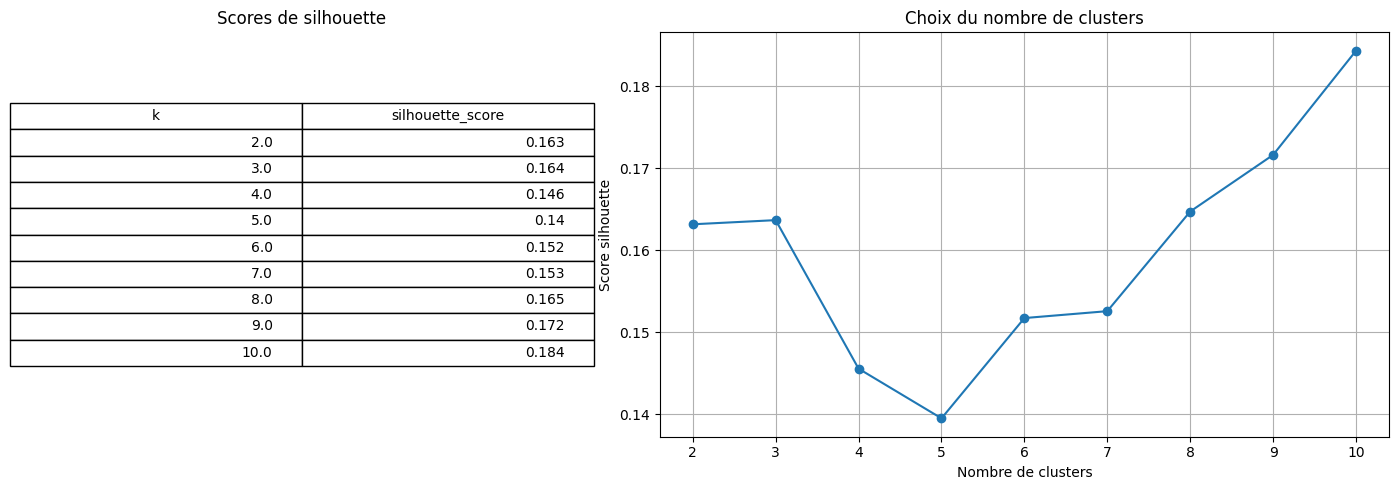

In [4019]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5),
    gridspec_kw={"width_ratios": [1, 1.5]}
)

# Tableau
axes[0].axis("off")

table = axes[0].table(
    cellText=df_kmeans_results.round(3).values,
    colLabels=df_kmeans_results.columns,
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)

axes[0].set_title("Scores de silhouette")

# Graphique
axes[1].plot(
    df_kmeans_results["k"],
    df_kmeans_results["silhouette_score"],
    marker="o"
)

axes[1].set_xlabel("Nombre de clusters")
axes[1].set_ylabel("Score silhouette")
axes[1].set_title("Choix du nombre de clusters")
axes[1].grid(True)

plt.tight_layout()
plt.show()

<h4 style="color:#48C9B0;">Choix du nombre de clusters</h4>

<p style="line-height:1.7;">
L'analyse des scores de silhouette montre une légère augmentation lorsque le nombre de clusters augmente, avec un maximum observé pour <b>k = 10</b>. Toutefois, les écarts restent faibles et l'amélioration obtenue demeure limitée.
</p>

<p style="line-height:1.7;">
Dans ce projet, le choix du nombre de clusters n'est pas guidé uniquement par un critère statistique. Une contrainte métier importante doit également être prise en compte : l'objectif final est de distinguer deux profils médicaux principaux, à savoir les images <i>Normales</i> et les images <i>Cancéreuses</i>.
</p>

<p style="line-height:1.7;">
L'utilisation d'un nombre élevé de clusters pourrait permettre de capturer des sous-groupes plus fins au sein des données, mais compliquerait fortement l'étape de pseudo-labellisation. Il deviendrait alors nécessaire d'interpréter et de regrouper manuellement plusieurs clusters afin de les associer aux deux classes médicales recherchées.
</p>

<p style="line-height:1.7;">
Compte tenu de cette contrainte métier et des faibles gains observés sur le score de silhouette, le nombre de clusters a été fixé à <b>k = 2</b>. Cette configuration est directement cohérente avec le problème de classification binaire visé et facilite l'attribution automatique des pseudo-labels nécessaires à l'apprentissage semi-supervisé.
</p>

In [4020]:
k_optimal = 2

<div style="border-left:4px solid #48C9B0; background:#f8fdfc; color: black; padding:14px 18px; margin:18px 0;">

<b>Objectif</b><br><br>

<p style="line-height:1.7;">
L'algorithme K-Means étant sensible à l'initialisation aléatoire des centroïdes, j'évalue l'impact du paramètre <i>n_init</i> sur la qualité du clustering.
</p>

<p style="line-height:1.7;">
Pour chaque valeur testée, K-Means est exécuté plusieurs fois avec des points de départ différents, puis conserve la meilleure solution trouvée. J'utilise l'ARI pour mesurer la stabilité et la qualité du regroupement obtenu.
</p>

<p style="line-height:1.7;">
Cette analyse me permet de vérifier si l'augmentation du nombre d'initialisations améliore significativement les performances ou si une valeur plus faible est suffisante pour obtenir un clustering robuste.
</p>

</div>

In [4021]:
from sklearn.metrics import adjusted_rand_score

for n_init in [10, 20, 50, 100, 200]:

    kmeans = KMeans(
        n_clusters=2,
        n_init=n_init,
        random_state=42
    )

    clusters = kmeans.fit_predict(train_pca)

    ari = adjusted_rand_score(train_labels, clusters)

    print(f"n_init={n_init:3d} | ARI={ari:.4f}")

n_init= 10 | ARI=0.8036
n_init= 20 | ARI=0.8036
n_init= 50 | ARI=0.8036
n_init=100 | ARI=0.8036
n_init=200 | ARI=0.8036


<h4 style="color:#48C9B0;">Interprétation des résultats</h4>

<p style="line-height:1.7;">
Les résultats obtenus sont strictement identiques pour toutes les valeurs de <i>n_init</i> testées. L'ARI reste constant à 0,8036, que l'algorithme soit initialisé 10, 20, 50, 100 ou 200 fois.
</p>

<p style="line-height:1.7;">
Cette stabilité indique que la solution trouvée par K-Means est robuste et que l'algorithme converge systématiquement vers le même regroupement. L'initialisation aléatoire des centroïdes n'a donc pas d'influence significative sur les performances dans cette configuration.
</p>

<p style="line-height:1.7;">
J'ai retenu <i>n_init = 20</i> pour la suite du projet. Cette valeur offre un bon compromis entre coût de calcul et robustesse, sans gain mesurable à augmenter davantage le nombre d'initialisations.
</p>

<div style="border-left:4px solid #48C9B0; background:#f8fdfc; color: black; padding:14px 18px; margin:18px 0;">

<b>Objectif</b><br><br>

<p style="line-height:1.7;">
Après avoir validé les paramètres de K-Means, j'entraîne le modèle final sur les données labellisées projetées dans l'espace PCA retenu.
</p>

<p style="line-height:1.7;">
Le modèle est ajusté exclusivement sur le jeu d'entraînement afin de respecter la séparation entre les différentes phases du projet. Les clusters appris sont ensuite attribués aux jeux de validation, de test ainsi qu'aux données non annotées.
</p>

<p style="line-height:1.7;">
Cette étape constitue la base de la pseudo-labellisation. Les groupes identifiés par K-Means serviront à associer un profil probable aux images non annotées avant le calcul des scores de confiance et la sélection des pseudo-labels les plus fiables.
</p>

</div>

In [4022]:
# KMeans final
# Entraînement uniquement sur le train labellisé
kmeans_final = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

# Apprentissage uniquement sur le train
kmeans_final.fit(train_pca)

# Prédictions sur les données labellisées
train_clusters = kmeans_final.predict(
    train_pca
)

val_clusters = kmeans_final.predict(
    val_pca
)

test_clusters = kmeans_final.predict(
    test_pca
)

# Prédictions sur les données non labellisées
train_unla_clusters = kmeans_final.predict(
    train_unla_pca
)

test_unla_clusters = kmeans_final.predict(
    test_unla_pca
)

<div style="border-left:4px solid #48C9B0; background:#f8fdfc; color: black; padding:14px 18px; margin:18px 0;">

<b>Objectif</b><br><br>

<p style="line-height:1.7;">
Je rassemble dans un même tableau les résultats du clustering obtenus sur les jeux d'entraînement, de validation et de test.
</p>

<p style="line-height:1.7;">
Pour chaque image labellisée, je conserve le label réel, le cluster attribué par K-Means ainsi que les coordonnées de projection dans l'espace PCA. Cette structure facilitera l'analyse de la correspondance entre les clusters et les classes médicales réelles.
</p>

<p style="line-height:1.7;">
Ces informations serviront également à établir le mapping entre les clusters et les profils probables <i>Normal</i> ou <i>Cancer</i>, étape indispensable avant la pseudo-labellisation des données non annotées.
</p>

</div>

In [4023]:
# Résultats labellisés avec projection PCA
df_train_results = pd.DataFrame({
    "split": "train",
    "label_reel": train_labels,
    "cluster": train_clusters,
    "pca_1": train_pca[:, 0],
    "pca_2": train_pca[:, 1]
})

df_val_results = pd.DataFrame({
    "split": "val",
    "label_reel": val_labels,
    "cluster": val_clusters,
    "pca_1": val_pca[:, 0],
    "pca_2": val_pca[:, 1]
})

df_test_results = pd.DataFrame({
    "split": "test",
    "label_reel": test_labels,
    "cluster": test_clusters,
    "pca_1": test_pca[:, 0],
    "pca_2": test_pca[:, 1]
})

df_labeled_results = pd.concat(
    [
        df_train_results,
        df_val_results,
        df_test_results
    ],
    ignore_index=True
)

df_labeled_results.head()

,split,label_reel,cluster,pca_1,pca_2
0,train,1,1,8.726830,-11.107959
1,train,0,0,-12.467517,10.471607
2,train,1,1,0.317217,-21.753208
3,train,1,0,-5.600917,4.865216
4,train,1,1,19.514011,11.000986


In [4024]:
pd.crosstab(
    df_train_results["label_reel"],
    df_train_results["cluster"],
    margins=True
)

cluster,0,1,All
label_reel,,,
0,28,1,29
1,2,28,30
All,30,29,59


In [4025]:
# Résultats non labellisés avec projection PCA 80%
df_train_unla_results = pd.DataFrame({
    "split": "train_unla",
    "cluster": train_unla_clusters,
    "pca_1": train_unla_pca[:, 0],
    "pca_2": train_unla_pca[:, 1]
})

df_test_unla_results = pd.DataFrame({
    "split": "test_unla",
    "cluster": test_unla_clusters,
    "pca_1": test_unla_pca[:, 0],
    "pca_2": test_unla_pca[:, 1]
})

df_unlabeled_results = pd.concat(
    [
        df_train_unla_results,
        df_test_unla_results
    ],
    ignore_index=True
)

df_unlabeled_results.head()

,split,cluster,pca_1,pca_2
0,train_unla,1,21.711174,3.146717
1,train_unla,1,6.334544,-3.416196
2,train_unla,1,23.596767,5.924696
3,train_unla,1,9.405924,-16.354042
4,train_unla,1,14.928967,4.285727


<h2 style="color:#48C9B0;">5 Analyse des clusters avec les labels connus</h2>

<h4 style="color:#48C9B0;">5.1 Répartition cancer / normal par cluster</h4>

<div style="border-left:4px solid #48C9B0; background:#f8fdfc; color: black; padding:14px 18px; margin:18px 0;">

<b>Objectif</b><br><br>

<p style="line-height:1.7;">
Je cherche à comprendre la composition réelle de chaque cluster appris par K-Means sur le jeu d'entraînement labellisé.
</p>

<p style="line-height:1.7;">
Pour cela, je calcule la proportion d'images normales et cancéreuses présentes dans chaque cluster. Cette analyse permet d'identifier la classe majoritaire associée à chaque groupe et d'évaluer le niveau de pureté des clusters obtenus.
</p>

<p style="line-height:1.7;">
Cette étape est essentielle pour attribuer un profil probable à chaque cluster avant de générer des pseudo-labels sur les données non annotées.
</p>

</div>

In [4026]:
# Composition des clusters sur le train uniquement
cluster_label_table_train = pd.crosstab(
    df_train_results["cluster"],
    df_train_results["label_reel"],
    normalize="index"
)

cluster_label_table_train.columns = ["normal", "cancer"]

cluster_label_table_train

,normal,cancer
cluster,,
0,0.933333,0.066667
1,0.034483,0.965517


<h4 style="color:#48C9B0;">Analyse de la pureté des clusters</h4>

<p style="line-height:1.7;">
Afin d'évaluer la cohérence des clusters obtenus avec les classes médicales réelles, j'ai analysé la répartition des labels annotés au sein de chaque groupe identifié par K-Means.
</p>

<p style="line-height:1.7;">
Les résultats montrent une forte spécialisation des deux clusters. Le <b>cluster 0</b> est composé à <b>93,3 % d'images normales</b> contre seulement <b>6,7 % d'images cancéreuses</b>. À l'inverse, le <b>cluster 1</b> contient <b>96,6 % d'images cancéreuses</b> pour seulement <b>3,4 % d'images normales</b>.
</p>

<p style="line-height:1.7;">
Cette forte pureté indique que les groupes découverts automatiquement par K-Means correspondent largement aux deux profils médicaux recherchés. Malgré des scores ARI et NMI imparfaits, les clusters obtenus restent donc très cohérents avec les labels réels disponibles.
</p>

<p style="line-height:1.7;">
Ces proportions peuvent être interprétées comme une estimation de la confiance associée à chaque cluster. Une image affectée au cluster <i>Normal</i> présente ainsi une probabilité d'environ <b>93 %</b> d'appartenir réellement à cette classe, tandis qu'une image affectée au cluster <i>Cancer</i> présente une probabilité proche de <b>97 %</b> d'être effectivement cancéreuse.
</p>

<p style="line-height:1.7;">
Cette forte pureté constitue un élément déterminant pour la suite du projet, car elle justifie l'utilisation des clusters comme source de pseudo-labels pour les images non annotées dans l'approche semi-supervisée.
</p>

<div style="border-left:4px solid #48C9B0; background:#f8fdfc; color: black; padding:14px 18px; margin:18px 0;">

<b>Objectif</b><br><br>

<p style="line-height:1.7;">
J'analyse la composition des clusters obtenus par K-Means à partir des données labellisées afin d'identifier la classe majoritaire associée à chaque groupe.
</p>

<p style="line-height:1.7;">
J'étudie à la fois les effectifs et les proportions d'images normales et cancéreuses présents dans chaque cluster. Cette analyse permet d'évaluer la pureté des groupes formés par l'algorithme et de vérifier leur cohérence avec les labels réels.
</p>

<p style="line-height:1.7;">
L'objectif est d'attribuer un profil probable à chaque cluster avant de procéder à la pseudo-labellisation des données non annotées.
</p>

</div>

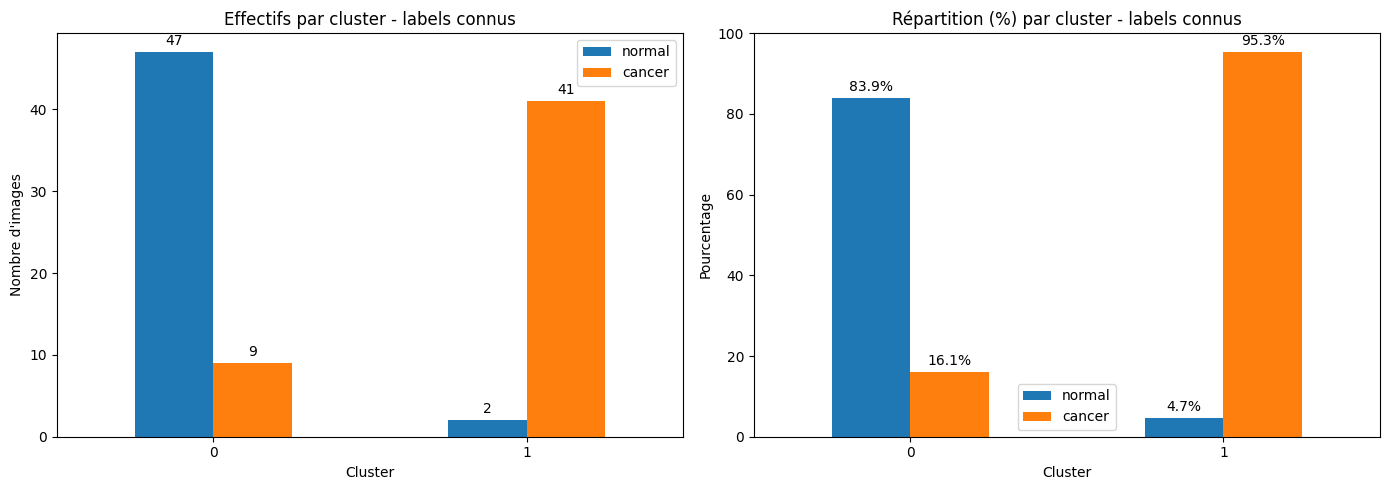

In [4027]:
cluster_counts = pd.crosstab(
    df_labeled_results["cluster"],
    df_labeled_results["label_reel"]
)

cluster_counts.columns = ["normal", "cancer"]

cluster_percentages = pd.crosstab(
    df_labeled_results["cluster"],
    df_labeled_results["label_reel"],
    normalize="index"
) * 100

cluster_percentages.columns = ["normal", "cancer"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Effectifs
cluster_counts.plot(
    kind="bar",
    ax=axes[0]
)

axes[0].set_title("Effectifs par cluster - labels connus")
axes[0].set_xlabel("Cluster")
axes[0].set_ylabel("Nombre d'images")
axes[0].tick_params(axis="x", rotation=0)

for container in axes[0].containers:
    axes[0].bar_label(
        container,
        fmt="%d",
        padding=3
    )

# Pourcentages
cluster_percentages.plot(
    kind="bar",
    ax=axes[1]
)

axes[1].set_title("Répartition (%) par cluster - labels connus")
axes[1].set_xlabel("Cluster")
axes[1].set_ylabel("Pourcentage")
axes[1].tick_params(axis="x", rotation=0)

for container in axes[1].containers:
    axes[1].bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )

plt.tight_layout()
plt.show()

<h4 style="color:#48C9B0;">Interprétation des résultats</h4>

<p style="line-height:1.7;">
L'analyse de la composition des clusters montre une forte correspondance entre les groupes identifiés par K-Means et les classes médicales réelles. Le cluster 0 contient majoritairement des images normales avec <b>83,9 %</b> d'images saines contre <b>16,1 %</b> d'images cancéreuses.
</p>

<p style="line-height:1.7;">
Le cluster 1 présente une pureté encore plus marquée avec <b>95,3 %</b> d'images cancéreuses et seulement <b>4,7 %</b> d'images normales. Ce résultat indique que K-Means parvient à isoler efficacement un groupe fortement associé au profil cancéreux malgré le chevauchement partiel observé entre les deux classes.
</p>

<p style="line-height:1.7;">
À partir de cette analyse, le cluster 0 est associé au profil probable <i>Normal</i> tandis que le cluster 1 est associé au profil probable <i>Cancer</i>. Les proportions observées seront utilisées comme estimation de la confiance associée à chaque cluster lors de la génération des pseudo-labels.
</p>

<p style="line-height:1.7;">
Cette forte pureté constitue un résultat important pour la suite du projet. Elle montre que les clusters obtenus restent largement cohérents avec les diagnostics réels et fournit une base fiable pour attribuer automatiquement des pseudo-labels aux images non annotées dans le cadre de l'apprentissage semi-supervisé.
</p>

<h4 style="color:#48C9B0;">5.2 Interpretation des clusters</h4>

<h4 style="color:#48C9B0;">5.3 Evaluation des clusters (ARI, NMI)</h4>

<div style="border-left:4px solid #48C9B0; background:#f8fdfc; color: black; padding:14px 18px; margin:18px 0;">

<b>Objectif</b><br><br>

<p style="line-height:1.7;">
Je réalise une évaluation finale du clustering K-Means retenu afin de mesurer sa capacité à retrouver la structure des classes sur les jeux d'entraînement, de validation et de test.
</p>

<p style="line-height:1.7;">
Les performances sont évaluées à l'aide de l'ARI, du NMI et du score de silhouette. Ces métriques permettent de quantifier à la fois la cohérence entre les clusters et les labels réels ainsi que la qualité géométrique des groupes formés.
</p>

<p style="line-height:1.7;">
Cette évaluation constitue la dernière étape de validation avant l'utilisation du clustering pour la génération des pseudo-labels et le calcul des scores de confiance.
</p>

</div>

In [4028]:
# Évaluation finale du clustering sur PCA
results = []

for split_name, X, y in [
    ("Train", train_pca, train_labels),
    ("Validation", val_pca, val_labels),
    ("Test", test_pca, test_labels)
]:

    clusters = kmeans_final.predict(X)

    results.append({
        "Split": split_name,
        "ARI": adjusted_rand_score(y, clusters),
        "NMI": normalized_mutual_info_score(y, clusters),
        "Silhouette": (
            silhouette_score(X, clusters)
            if len(np.unique(clusters)) > 1
            else np.nan
        )
    })

df_clustering_metrics = pd.DataFrame(results)

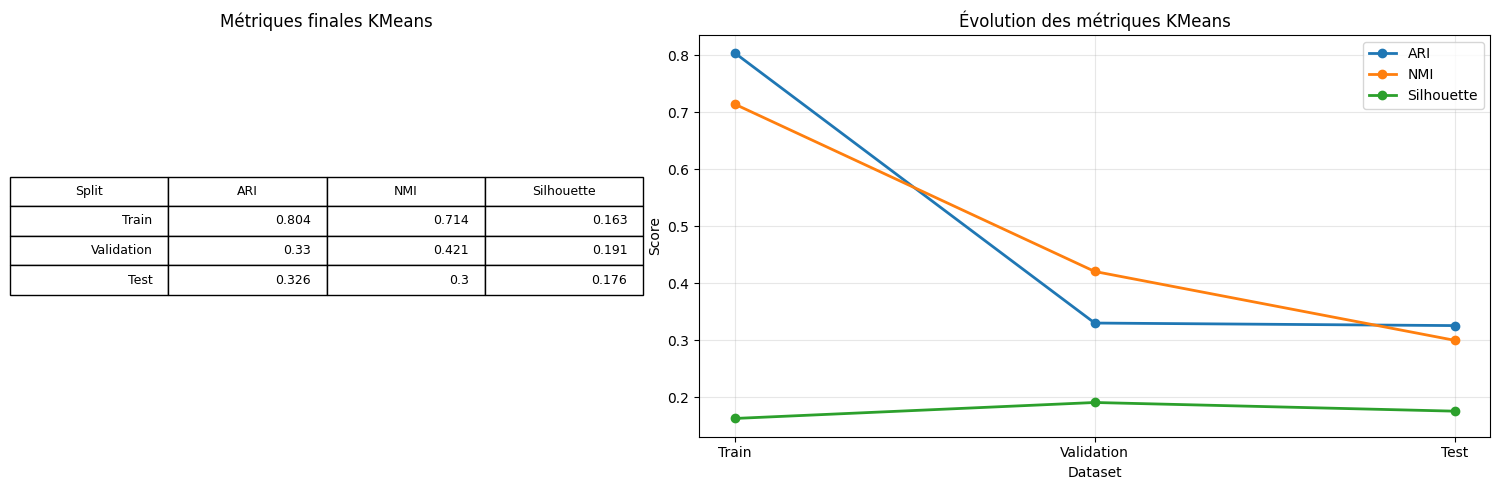

In [4029]:
# Tableau + courbes des métriques finales
fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 5),
    gridspec_kw={"width_ratios": [1.2, 1.8]}
)

# Tableau
axes[0].axis("off")

table_data = df_clustering_metrics.round(3)

table = axes[0].table(
    cellText=table_data.values,
    colLabels=table_data.columns,
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.7)

axes[0].set_title("Métriques finales KMeans")

# Courbes
for metric in ["ARI", "NMI", "Silhouette"]:
    axes[1].plot(
        df_clustering_metrics["Split"],
        df_clustering_metrics[metric],
        marker="o",
        linewidth=2,
        label=metric
    )

axes[1].set_xlabel("Dataset")
axes[1].set_ylabel("Score")
axes[1].set_title("Évolution des métriques KMeans")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

<h4 style="color:#48C9B0;">Interprétation des résultats</h4>

<p style="line-height:1.7;">
L'évaluation finale confirme que K-Means parvient à capturer une partie importante de la structure présente dans les embeddings extraits par ResNet50. Sur le jeu d'entraînement, les performances sont élevées avec un <b>ARI de 0,804</b> et un <b>NMI de 0,714</b>, indiquant une forte cohérence entre les clusters générés et les classes médicales réelles.
</p>

<p style="line-height:1.7;">
Les performances diminuent sur les jeux de validation et de test, avec des scores ARI d'environ <b>0,33</b> et des scores NMI compris entre <b>0,30</b> et <b>0,42</b>. Cette baisse était attendue compte tenu du faible nombre d'images annotées disponibles et de la difficulté à séparer parfaitement les profils <i>Normal</i> et <i>Cancer</i> à partir d'un apprentissage non supervisé.
</p>

<p style="line-height:1.7;">
Les scores de silhouette restent relativement stables entre les différents jeux de données, avec des valeurs comprises entre <b>0,16</b> et <b>0,19</b>. Ces résultats suggèrent l'existence d'une structure exploitable dans l'espace des embeddings malgré un chevauchement partiel entre les deux profils médicaux.
</p>


<h2 style="color:#48C9B0;">6 Pseudo-labellisation exploratoire</h2>

<h4 style="color:#48C9B0;">6.1 Attribution d'un profil probable</h4>

<div style="border-left:4px solid #48C9B0; background:#f8fdfc; color: black; padding:14px 18px; margin:18px 0;">

<b>Objectif</b><br><br>

<p style="line-height:1.7;">
Je construis une correspondance entre les clusters générés par K-Means et les classes médicales réelles à partir des données labellisées.
</p>

<p style="line-height:1.7;">
Pour chaque cluster, j'identifie la classe majoritaire observée parmi les images annotées. Cette association permet d'attribuer un profil probable <i>Normal</i> ou <i>Cancer</i> aux groupes découverts automatiquement par l'algorithme.
</p>

<p style="line-height:1.7;">
Ce mapping constitue une étape indispensable avant la pseudo-labellisation, car il permettra de convertir les identifiants de clusters en labels exploitables pour les données non annotées.
</p>

</div>

In [4030]:
# Table cluster / vrai label
cluster_label_table = pd.crosstab(
    df_labeled_results["cluster"],
    df_labeled_results["label_reel"]
)

display(cluster_label_table)

# Mapping cluster -> label majoritaire
cluster_to_label = (
    cluster_label_table
    .idxmax(axis=1)
    .to_dict()
)

# Mapping cluster -> profil texte
cluster_to_profil = {
    cluster: "normal" if label == 0 else "cancer"
    for cluster, label in cluster_to_label.items()
}

print("Mapping cluster -> label :", cluster_to_label)
print("Mapping cluster -> profil :", cluster_to_profil)

label_reel,0,1
cluster,,
0,47,9
1,2,41


Mapping cluster -> label : {0: 0, 1: 1}
Mapping cluster -> profil : {0: 'normal', 1: 'cancer'}


In [4031]:
df_unlabeled_results["profil_probable"] = (
    df_unlabeled_results["cluster"]
    .map(cluster_to_profil)
)

df_unlabeled_results.head()

,split,cluster,pca_1,pca_2,profil_probable
0,train_unla,1,21.711174,3.146717,cancer
1,train_unla,1,6.334544,-3.416196,cancer
2,train_unla,1,23.596767,5.924696,cancer
3,train_unla,1,9.405924,-16.354042,cancer
4,train_unla,1,14.928967,4.285727,cancer


<h4 style="color:#48C9B0;">Interprétation des résultats</h4>

<p style="line-height:1.7;">
Les clusters identifiés par K-Means ont été convertis en profils médicaux probables à l'aide du mapping construit à partir des données labellisées. Chaque image non annotée hérite ainsi du profil majoritaire associé à son cluster d'appartenance.
</p>

<p style="line-height:1.7;">
Le tableau obtenu montre que les données non labellisées disposent désormais d'un pseudo-label exploitable pour les étapes suivantes du projet. En plus du profil probable attribué, les coordonnées PCA et l'identifiant du cluster sont conservés afin de permettre le calcul ultérieur de scores de confiance.
</p>

<p style="line-height:1.7;">
Cette transformation constitue la première étape de la pseudo-labellisation. Les images non annotées sont désormais associées à un profil <i>Normal</i> ou <i>Cancer</i>, mais toutes ne présentent pas le même niveau de fiabilité. Une phase supplémentaire sera donc nécessaire pour estimer la confiance de chaque pseudo-label et sélectionner uniquement les observations les plus pertinentes pour l'apprentissage semi-supervisé.
</p>

<h4 style="color:#48C9B0;">6.2 Analyse des images non labellisées</h4>

<div style="border-left:4px solid #48C9B0; background:#f8fdfc; color: black; padding:14px 18px; margin:18px 0;">

<b>Objectif</b><br><br>

<p style="line-height:1.7;">
J'analyse la répartition des profils probables attribués aux images non labellisées après application du clustering K-Means.
</p>

<p style="line-height:1.7;">
Cette visualisation me permet de vérifier si la pseudo-labellisation produit un jeu de données équilibré entre les classes <i>Normal</i> et <i>Cancer</i>, ou si un profil est majoritairement représenté.
</p>

<p style="line-height:1.7;">
Cette étape est importante avant l'entraînement semi-supervisé, car un déséquilibre marqué dans les pseudo-labels pourrait influencer le modèle et introduire un biais dans l'apprentissage.
</p>

</div>

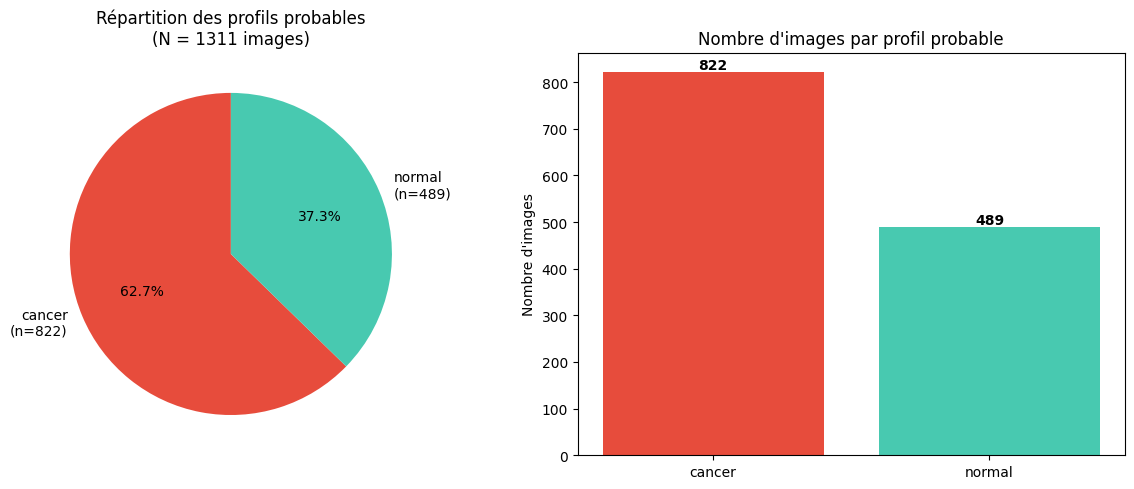

In [4032]:
# Nombre d'images par profil probable
cluster_counts = (
    df_unlabeled_results["profil_probable"]
    .value_counts()
)

# Pourcentage d'images par profil probable
cluster_percent = (
    df_unlabeled_results["profil_probable"]
    .value_counts(normalize=True)
    * 100
)

# Nombre total d'images pseudo-labellisées
total_images = cluster_counts.sum()

colors = {
    "normal": "#48C9B0",
    "cancer": "#E74C3C"
}

# Conservation de l'ordre des labels
ordered_labels = cluster_counts.index.tolist()

# Liste des couleurs correspondant aux labels
plot_colors = [
    colors.get(label, "gray")
    for label in ordered_labels
]

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)

# Camembert
axes[0].pie(
    cluster_counts,
    labels=[
        f"{label}\n(n={count})"
        for label, count in zip(
            ordered_labels,
            cluster_counts.values
        )
    ],
    autopct="%1.1f%%",
    startangle=90,
    colors=plot_colors
)

axes[0].set_title(
    f"Répartition des profils probables\n"
    f"(N = {total_images} images)"
)

# Histogramme
bars = axes[1].bar(
    ordered_labels,
    cluster_counts.values,
    color=plot_colors
)

# Affichage du nombre d'images au-dessus de chaque barre
for bar in bars:

    hauteur = bar.get_height()

    axes[1].text(
        x=bar.get_x() + bar.get_width() / 2,
        y=hauteur,
        s=f"{int(hauteur)}",
        ha="center",
        va="bottom",
        fontweight="bold",
        fontsize=10
    )

axes[1].set_title(
    "Nombre d'images par profil probable"
)

axes[1].set_ylabel(
    "Nombre d'images"
)

plt.tight_layout()
plt.show()

<h4 style="color:#48C9B0;">Interprétation des résultats</h4>

<p style="line-height:1.7;">
Après application du clustering et du mapping des clusters vers les classes médicales, les <b>1 311 images non annotées</b> ont pu être associées à un profil probable. La majorité des observations est attribuée au profil <i>Cancer</i>, avec <b>822 images (62,7 %)</b>, contre <b>489 images (37,3 %)</b> pour le profil <i>Normal</i>.
</p>

<p style="line-height:1.7;">
Cette répartition montre que les données non annotées présentent un déséquilibre en faveur du profil <i>Cancer</i>. Les embeddings d'une proportion importante d'images se rapprochent davantage du cluster associé aux caractéristiques observées chez les patients atteints d'un cancer.
</p>

<p style="line-height:1.7;"><b>
Cette distribution ne doit toutefois pas être interprétée comme une estimation de la prévalence réelle de la maladie dans la population. Elle reflète uniquement la structure identifiée par le modèle de clustering dans l'espace des embeddings extraits par ResNet50.
</b></p>

<p style="line-height:1.7;">
Afin d'éviter qu'une classe ne domine excessivement l'apprentissage semi-supervisé, la sélection des pseudo-labels reposera sur un score de confiance et sur une sélection équilibrée des observations les plus fiables pour chaque profil. Cette stratégie permettra de limiter l'impact du déséquilibre observé tout en conservant les images les plus représentatives de chaque groupe.
</p>


<div style="border-left:4px solid #48C9B0; background:#f8fdfc; color: black; padding:14px 18px; margin:18px 0;">

<b>Objectif</b><br><br>

<p style="line-height:1.7;">
Je projette simultanément les données labellisées et les données pseudo-labellisées dans l'espace PCA afin de visualiser leur positionnement relatif au sein des embeddings.
</p>

<p style="line-height:1.7;">
Les labels réels et les profils probables sont représentés séparément pour vérifier si les pseudo-labels suivent la même structure que les données annotées. Cette comparaison permet d'évaluer visuellement la cohérence de la pseudo-labellisation réalisée par le clustering.
</p>

<p style="line-height:1.7;">
L'objectif est de m'assurer que les images non annotées héritent de profils compatibles avec l'organisation observée sur les données réelles avant de les intégrer au processus d'apprentissage semi-supervisé.
</p>

</div>

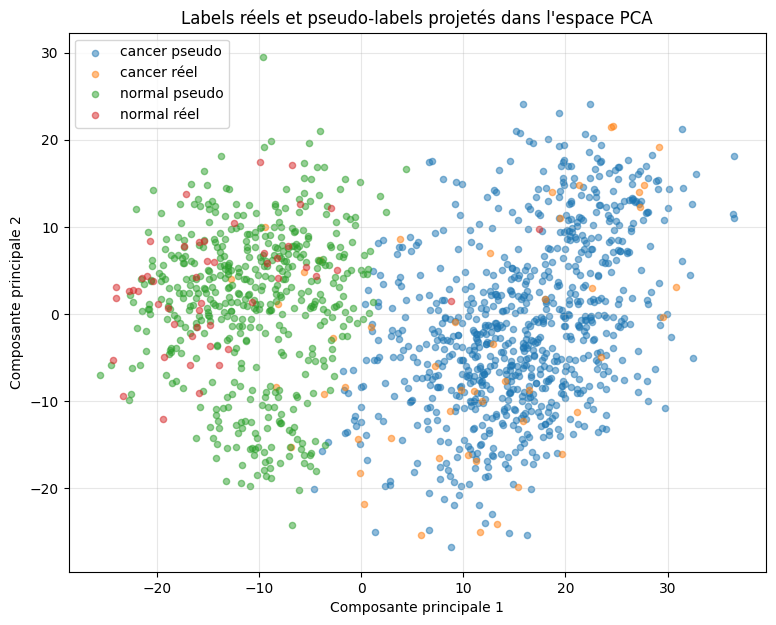

In [4033]:
# Vrais labels pour les données labellisées
df_labeled_results["profil"] = df_labeled_results["label_reel"].map({
    0: "normal réel",
    1: "cancer réel"
})

# Pseudo-labels pour les données non labellisées
df_unlabeled_results["profil"] = df_unlabeled_results["profil_probable"].map({
    "normal": "normal pseudo",
    "cancer": "cancer pseudo"
})

df_results = pd.concat(
    [df_labeled_results, df_unlabeled_results],
    ignore_index=True
)

plt.figure(figsize=(9, 7))

for profil in sorted(df_results["profil"].dropna().unique()):

    mask = df_results["profil"] == profil

    plt.scatter(
        df_results.loc[mask, "pca_1"],
        df_results.loc[mask, "pca_2"],
        label=profil,
        alpha=0.5,
        s=20
    )

plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
plt.title("Labels réels et pseudo-labels projetés dans l'espace PCA")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

<h4 style="color:#48C9B0;">Interprétation des résultats</h4>

<p style="line-height:1.7;">
La projection conjointe des données labellisées et pseudo-labellisées met en évidence une forte cohérence entre les profils attribués par le clustering et la structure observée sur les données réelles. Les pseudo-labels <i>normal pseudo</i> et <i>cancer pseudo</i> occupent majoritairement les mêmes régions de l'espace PCA que les observations annotées correspondantes.
</p>

<p style="line-height:1.7;"><b>
Les images associées au profil <i>Normal</i> se concentrent principalement dans la partie gauche de la projection, tandis que les images associées au profil <i>Cancer</i> occupent majoritairement la partie droite. Cette organisation est cohérente avec la séparation déjà observée lors de l'analyse des embeddings ResNet50 et suggère une cohérence partielle entre les pseudo-labels et les labels connus.
</b></p>

<p style="line-height:1.7;">
On observe néanmoins quelques points situés à proximité de la frontière entre les deux groupes. Ces observations correspondent probablement à des cas plus ambigus pour lesquels le niveau de confiance devra être examiné avec attention. Elles justifient la mise en place d'un mécanisme de sélection basé sur un score de confiance plutôt que l'utilisation directe de l'ensemble des pseudo-labels.
</p>

<p style="line-height:1.7;">
Dans l'ensemble, cette visualisation constitue un indicateur favorable pour la suite du projet. Les pseudo-labels suivent globalement la même organisation que les labels réels, ce qui suggère que les données non annotées pourront enrichir le jeu d'entraînement semi-supervisé à condition de conserver uniquement les observations les plus fiables.
</p>

<h4 style="color:#48C9B0;">6.3 Score de confiance</h4>

<div style="border-left:4px solid #48C9B0; background:#f8fdfc; color: black; padding:14px 18px; margin:18px 0;">

<b>Objectif</b><br><br>

<p style="line-height:1.7;">
Je calcule un score de confiance pour chaque image non labellisée à partir de sa distance aux centroïdes du modèle K-Means.
</p>

<p style="line-height:1.7;">
L'idée est de considérer qu'une image est plus fiable lorsque sa distance au centroïde de son cluster est nettement plus faible que sa distance à l'autre centroïde. À l'inverse, des distances proches indiquent une image située près de la frontière entre les deux groupes.
</p>

<p style="line-height:1.7;">
Ce score me permettra de classer les pseudo-labels selon leur fiabilité et de sélectionner uniquement les exemples les plus sûrs pour l'entraînement semi-supervisé.
</p>

</div>

In [4034]:
# Regroupement des images non labellisées train + test
unlabeled_pca = np.concatenate(
    [
        train_unla_pca,
        test_unla_pca
    ],
    axis=0
)

# Vérification de cohérence
print("Nombre d'images non labellisées :", len(unlabeled_pca))
print("Nombre de lignes dans df_unlabeled_results :", len(df_unlabeled_results))

# Prédiction des clusters K-Means
# Attribution du cluster le plus proche pour chaque image
df_unlabeled_results["cluster"] = kmeans_final.predict(unlabeled_pca)

# Distances aux deux centroïdes
# Pour chaque image, KMeans retourne la distance à chaque centroïde
# Colonne 0 = distance au centroïde du cluster 0
# Colonne 1 = distance au centroïde du cluster 1
distances_to_centers = kmeans_final.transform(unlabeled_pca)

df_unlabeled_results["distance_cluster_0"] = distances_to_centers[:, 0]
df_unlabeled_results["distance_cluster_1"] = distances_to_centers[:, 1]

# Distance au centroïde attribué
# Distance minimale = distance au centroïde du cluster prédit
df_unlabeled_results["distance_centroid"] = np.min(
    distances_to_centers,
    axis=1
)

# Score de confiance par séparation relative

# Principe :
# - si les deux distances sont proches, l'image est proche de la frontière
# - si une distance est beaucoup plus faible que l'autre, l'image est plus fiable
# Formule : confiance = |d0 - d1| / (d0 + d1)
# Score proche de 0  : image incertaine
# Score proche de 1  : image très clairement associée à un cluster
df_unlabeled_results["confiance_distance"] = (
    np.abs(
        df_unlabeled_results["distance_cluster_0"]
        - df_unlabeled_results["distance_cluster_1"]
    )
    /
    (
        df_unlabeled_results["distance_cluster_0"]
        + df_unlabeled_results["distance_cluster_1"]
        + 1e-8
    )
)

# Profil probable associé à chaque cluster
# Adapté au mapping

df_unlabeled_results["profil_probable"] = (
    df_unlabeled_results["cluster"].map(cluster_to_profil)
)

# Affichage des pseudo-labels les plus fiables
df_unlabeled_results.sort_values(
    "confiance_distance",
    ascending=False
).head(10)

Nombre d'images non labellisées : 1311
Nombre de lignes dans df_unlabeled_results : 1311


,split,cluster,pca_1,pca_2,profil_probable,profil,distance_cluster_0,distance_cluster_1,distance_centroid,confiance_distance
562,train_unla,1,18.047623,0.533190,cancer,cancer pseudo,35.358540,12.689794,12.689794,0.471790
329,train_unla,1,21.677311,-2.982656,cancer,cancer pseudo,40.203075,14.998419,14.998419,0.456594
656,train_unla,1,18.872841,-5.359455,cancer,cancer pseudo,37.249237,14.395515,14.395515,0.442518
1063,test_unla,1,19.699177,-8.199937,cancer,cancer pseudo,39.021858,15.811999,15.811999,0.423276
886,train_unla,1,17.324856,-0.878463,cancer,cancer pseudo,35.689156,14.574552,14.574552,0.420077
1281,test_unla,0,-19.246153,3.998907,normal,normal pseudo,15.918079,38.538944,15.918079,0.415389
331,train_unla,0,-20.617861,3.779902,normal,normal pseudo,17.233463,40.824345,17.233463,0.406334
1112,test_unla,0,-19.399105,5.653564,normal,normal pseudo,16.845366,39.685658,16.845366,0.404031
424,train_unla,0,-20.488066,5.553569,normal,normal pseudo,17.401333,40.719913,17.401333,0.401206
373,train_unla,0,-14.648446,3.090836,normal,normal pseudo,15.262088,35.471992,15.262088,0.398350


<h4 style="color:#48C9B0;">Interprétation du score de confiance basé sur la distance</h4>

<p style="line-height:1.7;">
Après l'attribution des clusters, un score de confiance est calculé pour chaque image non annotée afin d'estimer la fiabilité du pseudo-label obtenu. Ce score repose sur la position de l'image par rapport aux deux centroïdes appris par K-Means.
</p>

<p style="line-height:1.7;">
Pour chaque observation, l'algorithme calcule la distance au centroïde du cluster 0 et la distance au centroïde du cluster 1. Le score de confiance est ensuite défini comme le rapport entre l'écart de ces deux distances et leur somme :
</p>

<p style="text-align:center; font-size:18px;">
<b>Confiance = |d<sub>0</sub> - d<sub>1</sub>| / (d<sub>0</sub> + d<sub>1</sub>)</b>
</p>

<p style="line-height:1.7;">
Cette mesure traduit le niveau de séparation entre les deux clusters pour une image donnée. Lorsque les deux distances sont très proches, l'image se situe près de la frontière entre les groupes et le score tend vers 0. À l'inverse, lorsqu'une image est nettement plus proche d'un centroïde que de l'autre, le score augmente et le pseudo-label devient plus fiable.
</p>

<p style="line-height:1.7;">
Les valeurs observées restent relativement modérées, avec un maximum proche de <b>0,47</b>. Cela s'explique par le chevauchement partiel des deux profils médicaux dans l'espace des embeddings. Les images les plus fiables ne sont donc pas celles présentant une séparation parfaite entre les clusters, mais celles dont l'appartenance à un groupe est la plus marquée relativement aux autres observations.
</p>

<p style="line-height:1.7;">
Ce score ne constitue pas à lui seul une probabilité d'appartenance à une classe. Il représente plutôt un indicateur relatif de certitude permettant de classer les images du plus fiable au moins fiable avant la phase de sélection des pseudo-labels.
</p>

<div style="border-left:4px solid #48C9B0; background:#f8fdfc; color: black; padding:14px 18px; margin:18px 0;">

<b>Objectif</b><br><br>

<p style="line-height:1.7;">
J'analyse la distribution des scores de confiance au sein de chaque cluster afin d'évaluer la qualité globale des pseudo-labels générés par K-Means.
</p>

<p style="line-height:1.7;">
Cette visualisation permet d'identifier si les observations sont majoritairement proches du centre de leur cluster ou si une proportion importante d'images se situe à proximité de la frontière entre les deux groupes.
</p>

<p style="line-height:1.7;">
L'objectif est de définir un seuil de confiance pertinent permettant de conserver uniquement les pseudo-labels les plus fiables pour l'apprentissage semi-supervisé.
</p>

</div>

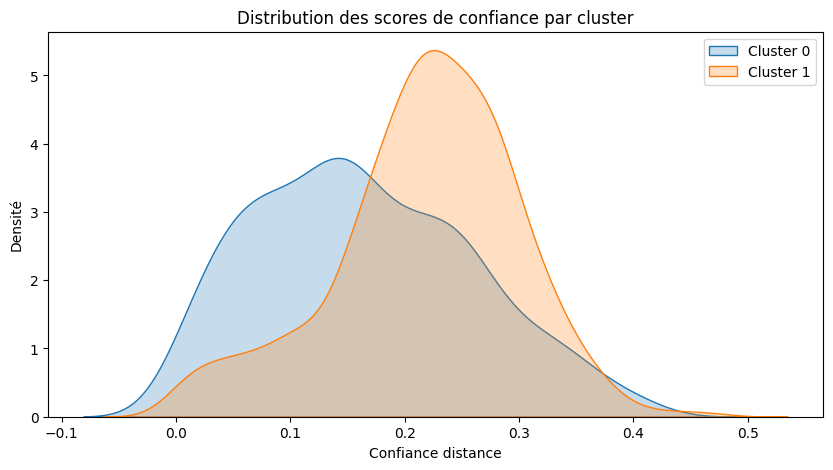

In [4035]:
plt.figure(figsize=(10,5))

for cluster in sorted(df_unlabeled_results["cluster"].unique()):
    sns.kdeplot(
        data=df_unlabeled_results[
            df_unlabeled_results["cluster"] == cluster
        ],
        x="confiance_distance",
        fill=True,
        label=f"Cluster {cluster}"
    )

plt.title("Distribution des scores de confiance par cluster")
plt.xlabel("Confiance distance")
plt.ylabel("Densité")
plt.legend()
plt.show()

<h4 style="color:#48C9B0;">Interprétation des résultats</h4>

<p style="line-height:1.7;">
Les distributions des scores de confiance montrent que la majorité des images non annotées se concentrent entre <b>0,10 et 0,30</b>. Les scores les plus élevés restent inférieurs à <b>0,50</b>, ce qui indique que les deux clusters ne sont pas totalement séparés dans l'espace PCA. Cette observation est cohérente avec les scores de silhouette précédemment obtenus et confirme l'existence d'un chevauchement partiel entre les profils <i>Normal</i> et <i>Cancer</i>.
</p>

<p style="line-height:1.7;">
Le cluster 1, associé au profil <i>Cancer</i>, présente une distribution légèrement décalée vers les valeurs élevées. Les images de ce groupe sont donc, en moyenne, plus éloignées de la frontière entre les clusters que celles du cluster 0. Cette observation est cohérente avec la forte pureté du cluster cancéreux observée précédemment.
</p>

<p style="line-height:1.7;">
Une zone de recouvrement importante demeure toutefois visible entre les deux distributions. Les images situées dans cette région présentent une appartenance plus ambiguë aux clusters et sont donc plus susceptibles d'être mal pseudo-labellisées.
</p>

<p style="line-height:1.7;">
Ces résultats justifient l'utilisation d'un filtrage basé sur la confiance. Plutôt que d'utiliser l'ensemble des pseudo-labels générés, seules les observations présentant les scores les plus élevés seront conservées afin de limiter l'introduction de bruit dans l'apprentissage semi-supervisé.
</p>

<p style="line-height:1.7;">
Le score de confiance ne doit pas être interprété comme une probabilité d'appartenance à une classe. Il constitue un indicateur relatif permettant de classer les images selon la netteté de leur affectation à un cluster et de sélectionner les pseudo-labels les plus fiables pour la suite du projet.
</p>

In [4036]:
df_unlabeled_results.groupby(
    "profil_probable"
)["confiance_distance"].describe().round(3)

,count,mean,std,min,25%,50%,75%,max
profil_probable,,,,,,,,
cancer,822.0,0.218,0.081,0.000,0.175,0.223,0.274,0.472
normal,489.0,0.164,0.095,0.002,0.087,0.154,0.235,0.415


<h4 style="color:#48C9B0;">Interprétation des résultats</h4>

<p style="line-height:1.7;">
Les statistiques descriptives montrent que les scores de confiance restent globalement modérés, avec une moyenne de <b>0,218</b> pour les images associées au profil <i>Cancer</i> et de <b>0,164</b> pour celles associées au profil <i>Normal</i>. Les deux distributions présentent une dispersion relativement proche, avec un écart-type compris entre <b>0,08</b> et <b>0,10</b>.
</p>

<p style="line-height:1.7;">
Les images attribuées au profil <i>Cancer</i> obtiennent en moyenne des scores de confiance plus élevés que celles associées au profil <i>Normal</i>. Cette observation est cohérente avec la forte pureté du cluster cancéreux observée précédemment, qui contient plus de <b>95 %</b> d'images cancéreuses parmi les données annotées.
</p>

<p style="line-height:1.7;">
Les médianes restent proches des moyennes pour les deux profils, ce qui suggère une répartition relativement équilibrée des scores au sein de chaque cluster. Les valeurs minimales proches de zéro montrent toutefois que certaines images se situent à proximité de la frontière entre les deux groupes et présentent donc une forte incertitude quant à leur affectation.
</p>

<p style="line-height:1.7;">
Les quartiles mettent également en évidence une concentration importante des observations entre <b>0,17 et 0,27</b> pour le profil <i>Cancer</i> et entre <b>0,09 et 0,24</b> pour le profil <i>Normal</i>. Les images les plus fiables correspondent ainsi à une fraction relativement réduite des données non annotées.
</p>

<p style="line-height:1.7;">
Ces résultats justifient la mise en place d'un filtrage basé sur la confiance. La sélection des observations présentant les scores les plus élevés permettra de limiter le bruit introduit par la pseudo-labellisation et de constituer un jeu d'entraînement semi-supervisé plus fiable.
</p>

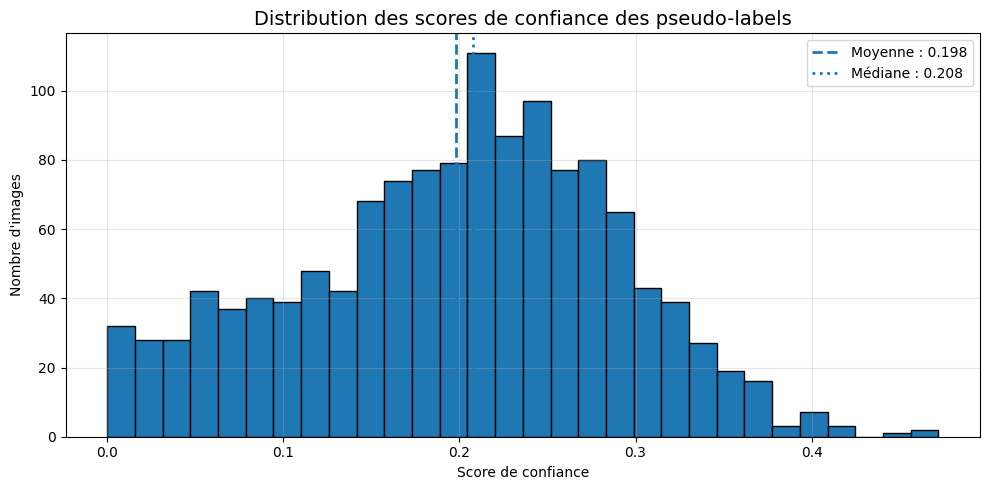

In [4037]:
mean_conf = df_unlabeled_results["confiance_distance"].mean()
median_conf = df_unlabeled_results["confiance_distance"].median()

plt.figure(figsize=(10, 5))

plt.hist(
    df_unlabeled_results["confiance_distance"],
    bins=30,
    edgecolor="black"
)

plt.axvline(
    mean_conf,
    linestyle="--",
    linewidth=2,
    label=f"Moyenne : {mean_conf:.3f}"
)

plt.axvline(
    median_conf,
    linestyle=":",
    linewidth=2,
    label=f"Médiane : {median_conf:.3f}"
)

plt.title(
    "Distribution des scores de confiance des pseudo-labels",
    fontsize=14
)

plt.xlabel("Score de confiance")
plt.ylabel("Nombre d'images")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

<h4 style="color:#48C9B0;">Interprétation des résultats</h4>

<p style="line-height:1.7;">
La distribution des scores de confiance présente une forme relativement unimodale centrée autour de <b>0,20</b>. La moyenne (<b>0,198</b>) et la médiane (<b>0,208</b>) sont proches, ce qui traduit une répartition globalement équilibrée des niveaux de confiance associés aux pseudo-labels générés.
</p>

<p style="line-height:1.7;">
La majorité des observations se concentre entre <b>0,10</b> et <b>0,30</b>, avec un pic de fréquence autour de <b>0,20 à 0,25</b>. Cette distribution confirme que la plupart des images possèdent une appartenance identifiable à l'un des deux clusters, sans pour autant présenter une séparation parfaite entre les groupes.
</p>

<p style="line-height:1.7;">
Les scores très faibles restent relativement peu nombreux, ce qui indique qu'une proportion limitée des images se situe directement à proximité de la frontière entre les clusters. À l'inverse, seules quelques observations atteignent des scores supérieurs à <b>0,35</b>, traduisant un nombre restreint d'images particulièrement faciles à attribuer à un profil médical.
</p>

<p style="line-height:1.7;">
Cette distribution met en évidence différents niveaux de certitude parmi les pseudo-labels générés. L'utilisation de l'ensemble des observations introduirait inévitablement du bruit dans l'apprentissage semi-supervisé. Il apparaît donc préférable de privilégier les images présentant les scores de confiance les plus élevés.
</p>

<p style="line-height:1.7;">
Dans la suite du projet, un filtrage sera appliqué afin de sélectionner les pseudo-labels les plus fiables pour chaque profil. Cette stratégie permettra de constituer un jeu faiblement supervisé plus robuste tout en conservant une représentation équilibrée des classes <i>Normal</i> et <i>Cancer</i>.
</p>

In [4038]:
df_unlabeled_results["rang_confiance"] = (
    df_unlabeled_results["confiance_distance"]
    .rank(pct=True)
)

<!-- Images les plus confiantes -->

<div style="border-left:4px solid #48C9B0; background:#f8fdfc; color: black; padding:14px 18px; margin:18px 0;">

<b>Objectif</b><br><br>

<p style="line-height:1.7;">
Je calcule un score de confiance propre à chaque cluster à partir des données labellisées du jeu d'entraînement.
</p>

<p style="line-height:1.7;">
Ce score correspond à la proportion de la classe majoritaire présente dans chaque cluster. Plus cette proportion est élevée, plus le cluster est homogène et plus les pseudo-labels qui lui sont associés sont susceptibles d'être fiables.
</p>

<p style="line-height:1.7;">
Cette mesure complète le score de confiance basé sur les distances aux centroïdes en intégrant une information sur la qualité réelle du clustering observée sur les données annotées.
</p>

</div>

In [4039]:
cluster_confidence = {}

for cluster in cluster_label_table_train.index:

    total_cluster = (
        cluster_label_table_train.loc[cluster].sum()
    )

    majoritaire = (
        cluster_label_table_train.loc[cluster].max()
    )

    cluster_confidence[cluster] = (
        majoritaire / total_cluster
    )

print(cluster_confidence)

{0: np.float64(0.9333333333333333), 1: np.float64(0.9655172413793104)}


<h4 style="color:#48C9B0;">Interprétation des résultats</h4>

<p style="line-height:1.7;">
Les scores de confiance calculés à partir de la pureté des clusters montrent que les deux groupes identifiés par K-Means sont fortement homogènes. Le cluster 0 atteint un niveau de confiance de <b>93,3 %</b>, tandis que le cluster 1 atteint <b>96,6 %</b>.
</p>

<p style="line-height:1.7;">
Ces valeurs signifient que, parmi les données annotées utilisées pour évaluer le clustering, <b>93,3 %</b> des images du cluster 0 appartiennent à sa classe majoritaire et <b>96,6 %</b> des images du cluster 1 appartiennent à la leur. Les deux clusters présentent donc une forte cohérence avec les labels réels, malgré les limites inhérentes à une approche non supervisée.
</p>

<p style="line-height:1.7;">
Le cluster associé au profil <i>Cancer</i> apparaît comme le plus pur. Cette observation suggère que les pseudo-labels attribués à cette classe sont globalement plus fiables, le nombre d'images appartenant à la classe opposée restant très faible.
</p>

<p style="line-height:1.7;">
Ces scores de pureté apportent une information complémentaire aux distances aux centroïdes. Alors que la confiance basée sur la distance évalue la position individuelle d'une image par rapport aux centres des clusters, la pureté mesure la fiabilité globale du cluster auquel elle appartient.
</p>

<p style="line-height:1.7;">
Dans la suite du projet, ces deux informations seront combinées afin de construire un score de confiance final. Cette stratégie permettra de privilégier les images appartenant à des clusters fiables et présentant une affectation claire, afin de sélectionner les pseudo-labels les plus pertinents pour l'apprentissage semi-supervisé.
</p>

<div style="border-left:4px solid #48C9B0; background:#f8fdfc; color: black; padding:14px 18px; margin:18px 0;">

<b>Objectif</b><br><br>

<p style="line-height:1.7;">
Je cherche à déterminer la meilleure pondération entre la confiance issue de la pureté des clusters et la confiance basée sur la distance aux centroïdes.
</p>

<p style="line-height:1.7;">
Pour cela, j'utilise les données labellisées comme référence et je simule la sélection des pseudo-labels les plus fiables selon différentes combinaisons de pondération.
</p>

<p style="line-height:1.7;">
L'objectif est d'identifier la pondération qui maximise la qualité des pseudo-labels retenus tout en conservant une représentation suffisante des deux classes avant la phase d'apprentissage semi-supervisé.
</p>

</div>

In [4040]:
poids_cluster_list = [0.5, 0.6, 0.7, 0.8, 0.9]

df_demo = df_labeled_results.copy()

# Prédiction du profil à partir du cluster
df_demo["label_pred_cluster"] = df_demo["cluster"].map(cluster_to_label)

# Vérification si le pseudo-label serait correct
df_demo["pseudo_label_correct"] = (
    df_demo["label_pred_cluster"] == df_demo["label_reel"]
)

# Distances aux centroïdes
X_labeled_pca = np.vstack([train_pca, val_pca, test_pca])
distances_labeled = kmeans_final.transform(X_labeled_pca)

df_demo["distance_cluster_0"] = distances_labeled[:, 0]
df_demo["distance_cluster_1"] = distances_labeled[:, 1]

df_demo["confiance_distance"] = (
    np.abs(df_demo["distance_cluster_0"] - df_demo["distance_cluster_1"])
    /
    (df_demo["distance_cluster_0"] + df_demo["distance_cluster_1"] + 1e-8)
)

df_demo["confiance_cluster"] = df_demo["cluster"].map(cluster_confidence)

resultats_ponderation = []

for poids_cluster in poids_cluster_list:

    poids_distance = 1 - poids_cluster

    df_demo["confiance_finale"] = (
        poids_cluster * df_demo["confiance_cluster"]
        +
        poids_distance * df_demo["confiance_distance"]
    )

    # On simule une sélection des 30% pseudo-labels les plus fiables
    seuil = df_demo["confiance_finale"].quantile(0.70)

    df_selection = df_demo[
        df_demo["confiance_finale"] >= seuil
    ]

    resultats_ponderation.append({
        "poids_cluster": poids_cluster,
        "poids_distance": poids_distance,
        "nb_images_retenues": len(df_selection),
        "taux_pseudo_labels_corrects": df_selection["pseudo_label_correct"].mean(),
        "confiance_moyenne": df_selection["confiance_finale"].mean(),
        "part_cancer": (df_selection["label_pred_cluster"] == 1).mean(),
        "part_normal": (df_selection["label_pred_cluster"] == 0).mean()
    })

df_resultats_ponderation = pd.DataFrame(resultats_ponderation)

df_resultats_ponderation

,poids_cluster,poids_distance,nb_images_retenues,taux_pseudo_labels_corrects,confiance_moyenne,part_cancer,part_normal
0,0.5,0.5,30,0.966667,0.613422,0.500000,0.500000
1,0.6,0.4,30,0.966667,0.680794,0.566667,0.433333
2,0.7,0.3,30,0.966667,0.748914,0.666667,0.333333
3,0.8,0.2,30,0.966667,0.818053,0.766667,0.233333
4,0.9,0.1,30,0.966667,0.890331,1.000000,0.000000


<h4 style="color:#48C9B0;">Analyse du poids attribué à la pureté et à la distance</h4>

<p style="line-height:1.7;">
Afin de construire un score de confiance final, plusieurs combinaisons entre la pureté du cluster et la confiance basée sur la distance aux centroïdes ont été évaluées. Pour chaque configuration, les 30 images les mieux classées ont été sélectionnées puis comparées aux pseudo-labels de référence.
</p>

<p style="line-height:1.7;">
Les résultats montrent que le taux de pseudo-labels corrects reste stable à <b>96,7 %</b> quelle que soit la pondération utilisée. Cette observation indique que les images les plus fiables sont identifiées de manière cohérente par les deux critères et que la qualité globale de la sélection varie peu.
</p>

<p style="line-height:1.7;">
En revanche, la répartition des profils évolue fortement lorsque le poids accordé à la pureté du cluster augmente. Avec une pondération équilibrée (<b>50 % pureté / 50 % distance</b>), la sélection contient autant d'images <i>Normal</i> que <i>Cancer</i>. À l'inverse, lorsque la pureté représente 90 % du score, seules des images associées au profil <i>Cancer</i> sont retenues.
</p>

<p style="line-height:1.7;">
Cette évolution s'explique par la pureté plus élevée du cluster cancéreux (96,6 %) comparativement au cluster normal (93,3 %). Plus le poids attribué à la pureté augmente, plus le score favorise mécaniquement les images appartenant au cluster <i>Cancer</i>.
</p>

<h4 style="color:#48C9B0;">Construction du score de confiance final</h4>

<p style="line-height:1.7;">
Afin d'identifier les pseudo-labels les plus fiables, deux sources d'information complémentaires sont combinées : la pureté du cluster et la distance aux centroïdes.
</p>

<p style="line-height:1.7;">
La <b>confiance du cluster</b> mesure la cohérence globale du groupe avec les labels réels observés sur les données annotées. Elle atteint <b>93,3 %</b> pour le cluster associé au profil <i>Normal</i> et <b>96,6 %</b> pour le cluster associé au profil <i>Cancer</i>.
</p>

<p style="line-height:1.7;">
La <b>confiance basée sur la distance</b> évalue quant à elle la position individuelle de chaque image dans l'espace PCA. Une image proche du centroïde de son cluster et éloignée du centroïde opposé obtient un score plus élevé qu'une image située à proximité de la frontière entre les deux groupes.
</p>

<p style="line-height:1.7;">
Plutôt que de réaliser une moyenne pondérée, le score final est obtenu en multipliant les deux composantes :
</p>

<p style="text-align:center; font-size:18px;">
<b>Confiance finale = Confiance cluster × Confiance distance</b>
</p>

<p style="line-height:1.7;">
Cette formulation permet de privilégier les observations qui satisfont simultanément les deux critères. Une image appartenant à un cluster très pur mais située près de la frontière entre les groupes sera pénalisée. À l'inverse, une image bien positionnée dans un cluster fiable obtiendra un score élevé.
</p>

<p style="line-height:1.7;">
Le score obtenu ne représente pas une probabilité d'appartenance à une classe. Il constitue un indicateur de fiabilité utilisé pour classer les images non annotées et sélectionner les pseudo-labels les plus pertinents pour l'apprentissage semi-supervisé.
</p>

In [4041]:
df_unlabeled_results["confiance_cluster"] = (
    df_unlabeled_results["cluster"]
    .map(cluster_confidence)
)

df_unlabeled_results["confiance_finale"] = (
    df_unlabeled_results["confiance_cluster"]
    * df_unlabeled_results["confiance_distance"]
)

df_unlabeled_results.sort_values(
    "confiance_finale",
    ascending=False
).head()

,split,cluster,pca_1,pca_2,profil_probable,profil,distance_cluster_0,distance_cluster_1,distance_centroid,confiance_distance,rang_confiance,confiance_cluster,confiance_finale
562,train_unla,1,18.047623,0.533190,cancer,cancer pseudo,35.358540,12.689794,12.689794,0.471790,1.000000,0.965517,0.455522
329,train_unla,1,21.677311,-2.982656,cancer,cancer pseudo,40.203075,14.998419,14.998419,0.456594,0.999237,0.965517,0.440849
656,train_unla,1,18.872841,-5.359455,cancer,cancer pseudo,37.249237,14.395515,14.395515,0.442518,0.998474,0.965517,0.427259
1063,test_unla,1,19.699177,-8.199937,cancer,cancer pseudo,39.021858,15.811999,15.811999,0.423276,0.997712,0.965517,0.408680
886,train_unla,1,17.324856,-0.878463,cancer,cancer pseudo,35.689156,14.574552,14.574552,0.420077,0.996949,0.965517,0.405591


<div style="border-left:4px solid #48C9B0; background:#f8fdfc; color: black; padding:14px 18px; margin:18px 0;">

<b>Objectif</b><br><br>

<p style="line-height:1.7;">
Je synthétise les résultats de la pseudo-labellisation afin d'évaluer la distribution des scores de confiance et la répartition des profils probables attribués aux images non annotées.
</p>

<p style="line-height:1.7;">
Je compare le score basé uniquement sur la distance avec le score final pondéré, puis j'observe le nombre d'images associées à chaque profil. Cette étape permet de vérifier si la stratégie retenue produit des pseudo-labels suffisamment fiables et exploitables.
</p>

<p style="line-height:1.7;">
Cette synthèse servira à définir le seuil de sélection des pseudo-labels utilisés pour l'entraînement semi-supervisé.
</p>

</div>

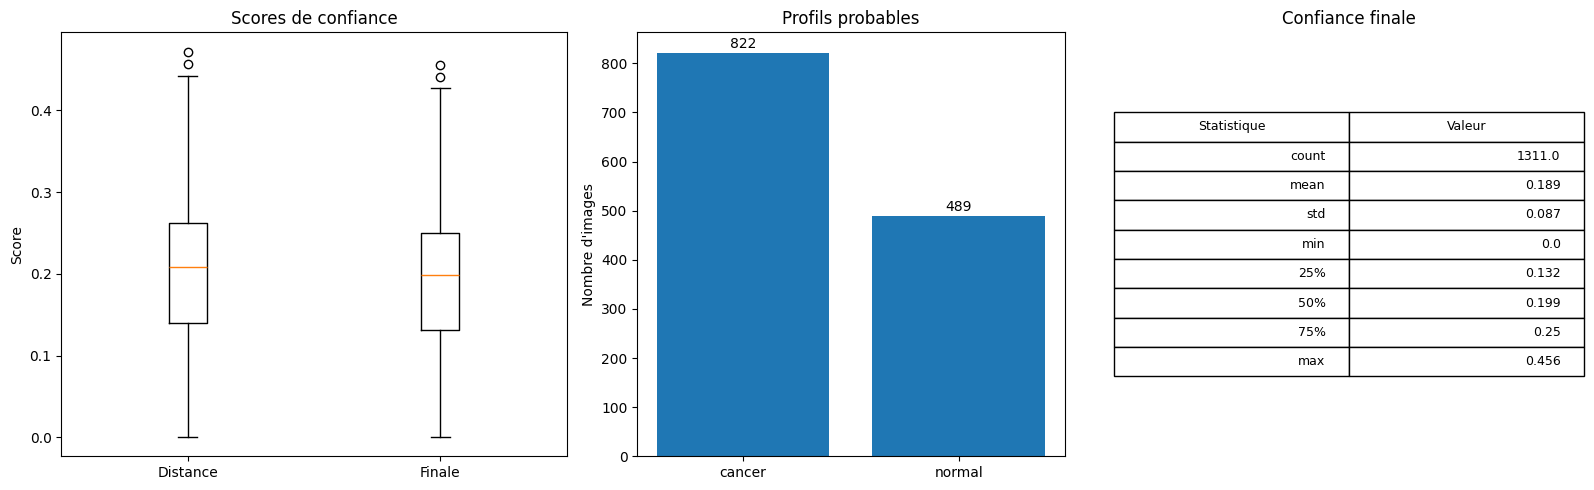

In [4042]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(16, 5),
    gridspec_kw={"width_ratios": [1.3, 1.1, 1.1]}
)

# Boxplot
axes[0].boxplot(
    [
        df_unlabeled_results["confiance_distance"],
        df_unlabeled_results["confiance_finale"]
    ],
    tick_labels=["Distance", "Finale"]
)

axes[0].set_title("Scores de confiance")
axes[0].set_ylabel("Score")

# Répartition des profils
profil_counts = (
    df_unlabeled_results["profil_probable"]
    .value_counts()
)

axes[1].bar(
    profil_counts.index,
    profil_counts.values
)

axes[1].set_title("Profils probables")
axes[1].set_ylabel("Nombre d'images")

for i, v in enumerate(profil_counts.values):
    axes[1].text(
        i,
        v + 10,
        str(v),
        ha="center"
    )

# Statistiques descriptives
axes[2].axis("off")

stats = (
    df_unlabeled_results["confiance_finale"]
    .describe()
    .round(3)
    .reset_index()
)

table = axes[2].table(
    cellText=stats.values,
    colLabels=["Statistique", "Valeur"],
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.1, 1.6)

axes[2].set_title("Confiance finale")

plt.tight_layout()
plt.show()

<h4 style="color:#48C9B0;">Interprétation des résultats</h4>

<p style="line-height:1.7;">
La combinaison de la pureté des clusters et de la confiance basée sur la distance produit un score final dont la distribution reste proche de celle observée pour la confiance distance seule. Les statistiques descriptives indiquent une moyenne de <b>0,189</b>, une médiane de <b>0,199</b> et un écart-type de <b>0,087</b>, avec des valeurs comprises entre <b>0,00</b> et <b>0,456</b>.
</p>

<p style="line-height:1.7;">
Le boxplot montre que les distributions des deux scores sont très similaires. Cette observation s'explique par le fait que les niveaux de pureté des clusters sont déjà très élevés, avec environ <b>93,3 %</b> pour le cluster associé au profil <i>Normal</i> et <b>96,6 %</b> pour celui associé au profil <i>Cancer</i>. <b>Ces valeurs étant proches de 1, la multiplication par la confiance du cluster modifie peu l'ordre relatif des observations.</b>
</p>

<p style="line-height:1.7;">
Autrement dit, dans ce contexte, le score final reste fortement influencé par la confiance distance, qui constitue le principal facteur de différenciation entre les images. La pureté du cluster joue néanmoins un rôle de correction en accordant un léger avantage aux observations appartenant aux groupes les plus fiables.
</p>

<p style="line-height:1.7;">
La répartition des profils probables reste inchangée avec <b>822 images associées au profil Cancer</b> et <b>489 images associées au profil Normal</b>. Cette distribution servira de base à la sélection des pseudo-labels les plus fiables pour l'apprentissage semi-supervisé.
</p>

<p style="line-height:1.7;">
Cette étape valide la stratégie retenue pour le calcul du score de confiance final. Les images peuvent désormais être classées selon leur niveau de fiabilité afin de ne conserver que les pseudo-labels les plus pertinents pour l'entraînement du modèle semi-supervisé.
</p>

<div style="border-left:4px solid #48C9B0; background:#f8fdfc; color: black; padding:14px 18px; margin:18px 0;">

<b>Objectif</b><br><br>

<p style="line-height:1.7;">
J'analyse la distribution des scores de confiance finaux pour chaque profil probable afin d'évaluer si les niveaux de confiance sont comparables entre les pseudo-labels <i>Normal</i> et <i>Cancer</i>.
</p>

<p style="line-height:1.7;">
Cette visualisation permet d'identifier d'éventuelles différences de fiabilité entre les deux profils et de vérifier si un seuil de sélection unique peut être appliqué à l'ensemble des pseudo-labels.
</p>

<p style="line-height:1.7;">
L'objectif est également de détecter un éventuel biais du clustering qui favoriserait systématiquement un profil par rapport à l'autre lors de l'attribution des pseudo-labels.
</p>

</div>

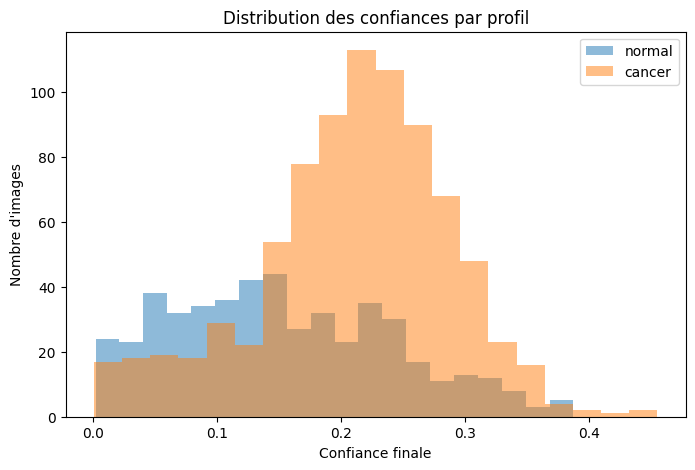

In [4043]:
plt.figure(figsize=(8,5))

for profil in ["normal", "cancer"]:

    plt.hist(
        df_unlabeled_results.loc[
            df_unlabeled_results["profil_probable"] == profil,
            "confiance_finale"
        ],
        bins=20,
        alpha=0.5,
        label=profil
    )

plt.title("Distribution des confiances par profil")
plt.xlabel("Confiance finale")
plt.ylabel("Nombre d'images")
plt.legend()

plt.show()

<h4 style="color:#48C9B0;">Interprétation des résultats</h4>

<p style="line-height:1.7;">
La distribution des scores de confiance présente des différences entre les deux profils probables. Les images associées au profil <i>Cancer</i> obtiennent globalement des scores légèrement plus élevés que celles associées au profil <i>Normal</i>, avec une concentration importante autour des valeurs comprises entre <b>0,18</b> et <b>0,30</b>.
</p>

<p style="line-height:1.7;">
Cette observation est cohérente avec l'analyse de la pureté des clusters. Le cluster associé au profil <i>Cancer</i> présente une pureté légèrement supérieure (<b>96,6 %</b>) à celle du cluster associé au profil <i>Normal</i> (<b>93,3 %</b>). Les pseudo-labels cancéreux bénéficient ainsi d'un léger avantage dans le calcul du score de confiance final.
</p>

<p style="line-height:1.7;">
Les deux distributions présentent toutefois un recouvrement important. Cette situation traduit l'existence d'images ambiguës dont l'appartenance aux clusters est moins marquée. À l'inverse, les observations situées dans la partie droite des distributions correspondent aux pseudo-labels les plus fiables et constituent les meilleurs candidats pour l'apprentissage semi-supervisé.
</p>

<p style="line-height:1.7;">
Ces résultats montrent également qu'un seuil de confiance unique pourrait favoriser davantage les images associées au profil <i>Cancer</i>. Afin de conserver une représentation équilibrée des deux classes, la sélection des pseudo-labels sera réalisée séparément pour chaque profil probable en retenant les observations les mieux classées au sein de chaque groupe.
</p>

<p style="line-height:1.7;">
Cette stratégie permet de limiter le déséquilibre entre les classes tout en conservant les images les plus fiables disponibles pour l'entraînement du modèle semi-supervisé.
</p>

In [4044]:
df_unlabeled_results.groupby(
    "profil_probable"
)["confiance_finale"].describe()

,count,mean,std,min,25%,50%,75%,max
profil_probable,,,,,,,,
cancer,822.0,0.210775,0.078042,0.000329,0.169431,0.215778,0.264409,0.455522
normal,489.0,0.153488,0.089088,0.001737,0.081551,0.143457,0.219349,0.387697


<h4 style="color:#48C9B0;">Interprétation des résultats</h4>

<p style="line-height:1.7;">
L'analyse statistique confirme que les pseudo-labels associés au profil <i>Cancer</i> obtiennent globalement des scores de confiance plus élevés que ceux associés au profil <i>Normal</i>. La confiance moyenne atteint <b>0,211</b> pour les images cancéreuses contre <b>0,153</b> pour les images normales.
</p>

<p style="line-height:1.7;">
Cette différence est cohérente avec la pureté des clusters observée précédemment. Le cluster associé au profil <i>Cancer</i> présente une pureté légèrement supérieure à celle du cluster <i>Normal</i>, ce qui se répercute naturellement sur le calcul du score de confiance final.
</p>

<p style="line-height:1.7;">
Les médianes suivent la même tendance, avec une valeur de <b>0,216</b> pour le profil <i>Cancer</i> contre <b>0,143</b> pour le profil <i>Normal</i>. Les distributions apparaissent relativement étalées, comme en témoignent les écarts-types compris entre <b>0,08</b> et <b>0,09</b>. Cette dispersion traduit l'existence de différents niveaux de certitude parmi les pseudo-labels générés.
</p>

<p style="line-height:1.7;">
Les quartiles montrent également que les images cancéreuses se situent globalement à des niveaux de confiance plus élevés. Le troisième quartile du profil <i>Normal</i> (<b>0,219</b>) est proche de la médiane du profil <i>Cancer</i> (<b>0,216</b>), ce qui confirme le décalage global des distributions en faveur du profil cancéreux.
</p>

<p style="line-height:1.7;">
Ces résultats montrent qu'un seuil de confiance unique risquerait de favoriser excessivement les pseudo-labels associés au profil <i>Cancer</i>. Afin de conserver une représentation équilibrée des deux classes, les observations les plus fiables seront sélectionnées séparément pour chaque profil probable. Cette stratégie permet de limiter le déséquilibre entre les classes tout en conservant les pseudo-labels présentant le plus haut niveau de confiance.
</p>

<div style="border-left:4px solid #48C9B0; background:#f8fdfc; color: black; padding:14px 18px; margin:18px 0;">

<b>Objectif</b><br><br>

<p style="line-height:1.7;">
J'analyse l'impact du seuil de confiance sur le nombre d'images pseudo-labellisées conservées.
</p>

<p style="line-height:1.7;">
Pour chaque seuil, je compte le nombre total d'images retenues ainsi que la répartition entre les profils <i>Normal</i> et <i>Cancer</i>. Cette étape me permet d'évaluer le compromis entre quantité de données disponibles et fiabilité attendue des pseudo-labels.
</p>

<p style="line-height:1.7;">
L'objectif est d'identifier un seuil suffisamment sélectif pour limiter le bruit, sans réduire excessivement le volume d'images utilisables pour l'apprentissage semi-supervisé.
</p>

</div>

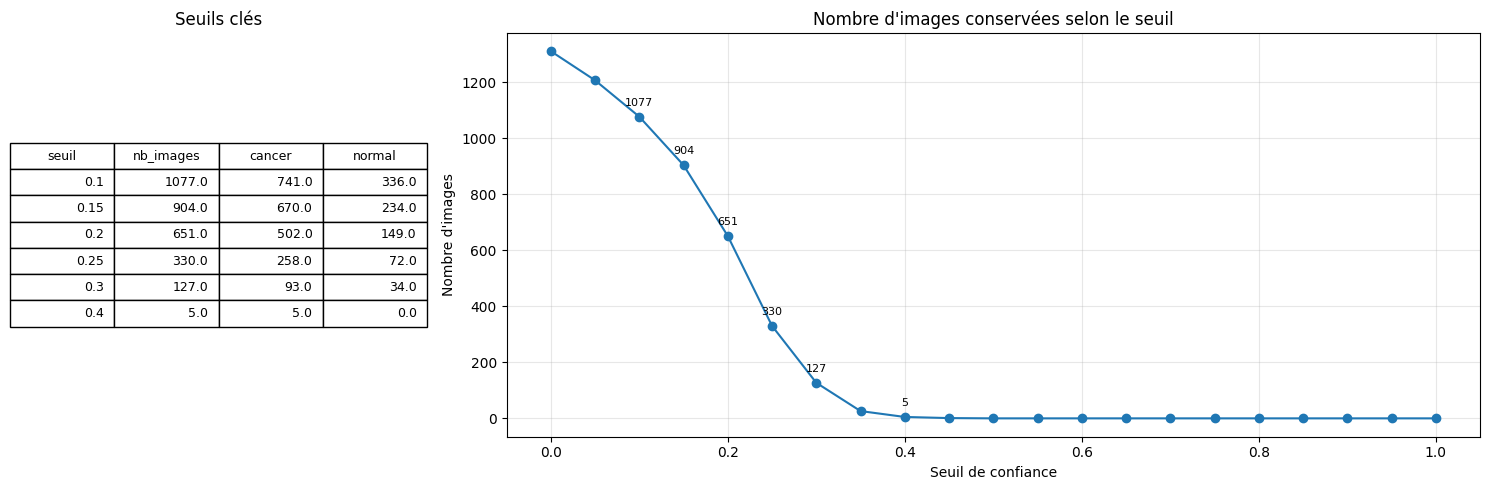

In [4045]:
seuils = np.arange(0, 1.01, 0.05)

resultats = []

for seuil in seuils:

    tmp = df_unlabeled_results[
        df_unlabeled_results["confiance_finale"] >= seuil
    ]

    resultats.append({
        "seuil": seuil,
        "nb_images": len(tmp),
        "cancer": (tmp["profil_probable"] == "cancer").sum(),
        "normal": (tmp["profil_probable"] == "normal").sum()
    })

df_seuils = pd.DataFrame(resultats)

# Seuils clés à afficher dans le tableau
seuils_cles = [0.10, 0.15, 0.20, 0.25, 0.30, 0.40]

df_table = df_seuils[
    df_seuils["seuil"].round(2).isin(seuils_cles)
].copy()

fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 5),
    gridspec_kw={"width_ratios": [0.9, 2.1]}
)

# Tableau simplifié
axes[0].axis("off")

table = axes[0].table(
    cellText=df_table.round(2).values,
    colLabels=df_table.columns,
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.5)

axes[0].set_title("Seuils clés")

# Courbe
axes[1].plot(
    df_seuils["seuil"],
    df_seuils["nb_images"],
    marker="o"
)

axes[1].set_title("Nombre d'images conservées selon le seuil")
axes[1].set_xlabel("Seuil de confiance")
axes[1].set_ylabel("Nombre d'images")
axes[1].grid(alpha=0.3)

# Annotation uniquement sur les seuils clés
for _, row in df_table.iterrows():
    axes[1].annotate(
        int(row["nb_images"]),
        (row["seuil"], row["nb_images"]),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
        fontsize=8
    )

plt.tight_layout()
plt.show()

<h4 style="color:#48C9B0;">Interprétation des résultats</h4>

<p style="line-height:1.7;">
L'analyse du nombre d'images conservées en fonction du seuil de confiance met en évidence une diminution rapide du volume de données lorsque le niveau d'exigence augmente. Avec un seuil de <b>0,10</b>, plus de <b>1 000 images</b> sont encore disponibles, tandis qu'un seuil de <b>0,20</b> réduit déjà le jeu de données à <b>651 observations</b>.
</p>

<p style="line-height:1.7;">
L'effet du filtrage devient particulièrement marqué au-delà de <b>0,25</b>. Le nombre d'images retenues passe alors de <b>330</b> à seulement <b>127</b> pour un seuil de <b>0,30</b>, puis à <b>5 images</b> pour un seuil de <b>0,40</b>.
</p>

<p style="line-height:1.7;">
On observe également un déséquilibre croissant entre les profils. Quel que soit le seuil considéré, les images associées au profil <i>Cancer</i> restent majoritaires. Cette tendance s'accentue lorsque le seuil augmente, jusqu'à atteindre un cas extrême où les cinq images conservées au seuil de <b>0,40</b> appartiennent toutes au profil <i>Cancer</i>.
</p>

<p style="line-height:1.7;">
Ces résultats confirment que les pseudo-labels cancéreux obtiennent globalement des scores de confiance plus élevés que les pseudo-labels normaux. L'application d'un seuil global unique favoriserait donc progressivement la classe <i>Cancer</i> au détriment de la classe <i>Normal</i>.
</p>

<div style="border-left:4px solid #48C9B0; background:#f8fdfc; color:black; padding:14px 18px; margin:18px 0;">

<b>Objectif</b><br><br>

<p style="line-height:1.7;">
J'étudie l'évolution du nombre de pseudo-labels conservés en fonction du seuil de confiance pour chaque profil probable.
</p>

<p style="line-height:1.7;">
Cette analyse permet d'observer séparément le comportement des profils <i>Normal</i> et <i>Cancer</i> lorsque le niveau d'exigence augmente. Elle complète l'étude précédente en mettant en évidence l'impact du seuil sur l'équilibre des classes.
</p>

<p style="line-height:1.7;">
L'objectif est de vérifier si un seuil unique permet de conserver un nombre suffisant d'images dans chaque profil ou s'il est nécessaire d'adopter une stratégie de sélection différente pour constituer un jeu de pseudo-labels équilibré.
</p>

</div>

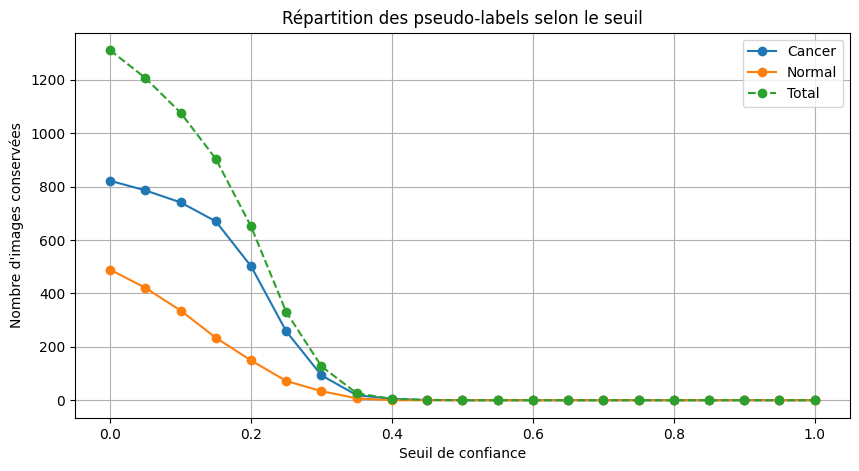

In [4046]:
seuils = np.arange(0, 1.01, 0.05)

stats = []

for seuil in seuils:

    tmp = df_unlabeled_results[
        df_unlabeled_results["confiance_finale"] >= seuil
    ]

    stats.append({
        "seuil": seuil,
        "cancer": (tmp["profil_probable"] == "cancer").sum(),
        "normal": (tmp["profil_probable"] == "normal").sum(),
        "total": len(tmp)
    })

stats = pd.DataFrame(stats)

plt.figure(figsize=(10,5))

plt.plot(
    stats["seuil"],
    stats["cancer"],
    label="Cancer",
    marker="o"
)

plt.plot(
    stats["seuil"],
    stats["normal"],
    label="Normal",
    marker="o"
)

plt.plot(
    stats["seuil"],
    stats["total"],
    label="Total",
    marker="o",
    linestyle="--"
)

plt.title("Répartition des pseudo-labels selon le seuil")
plt.xlabel("Seuil de confiance")
plt.ylabel("Nombre d'images conservées")

plt.legend()
plt.grid(True)

plt.show()

<h4 style="color:#48C9B0;">Interprétation des résultats</h4>

<p style="line-height:1.7;">
L'évolution des effectifs selon le seuil de confiance montre que le volume de pseudo-labels diminue progressivement lorsque les critères de sélection deviennent plus exigeants. Cette décroissance concerne les deux profils, mais elle n'est pas uniforme.
</p>

<p style="line-height:1.7;">
Les pseudo-labels associés au profil <i>Cancer</i> restent majoritaires sur l'ensemble des seuils étudiés. Leur effectif diminue plus lentement que celui du profil <i>Normal</i>, ce qui traduit des niveaux de confiance globalement plus élevés pour cette classe.
</p>

<p style="line-height:1.7;">
À mesure que le seuil augmente, l'écart entre les deux profils se creuse progressivement. Cette évolution confirme que les images associées au profil <i>Cancer</i> occupent plus fréquemment les premières positions du classement établi à partir du score de confiance final.
</p>

<p style="line-height:1.7;">
On observe également qu'au-delà d'un certain niveau d'exigence, le nombre d'images disponibles devient très faible. Cette situation illustre le compromis classique entre quantité et qualité : un filtrage plus strict améliore potentiellement la fiabilité des pseudo-labels retenus mais réduit fortement le volume de données exploitables pour l'apprentissage.
</p>

<p style="line-height:1.7;">
Cette analyse met en évidence l'importance de trouver un équilibre entre confiance et diversité des données. L'objectif n'est pas uniquement de conserver les observations les plus fiables, mais également de disposer d'un volume suffisant d'images représentatives pour enrichir efficacement l'apprentissage semi-supervisé.
</p>

<h4 style="color:#48C9B0;">6.4 Limites de l'approche</h4>

<div style="border-left:5px solid #48C9B0;
background:#f8fdfc;
padding:14px 18px;
margin:18px 0;
color:black;">

<b style="color:black;">Analyse critique de la pseudo-labellisation</b><br><br>

<p>
L'approche de pseudo-labellisation mise en œuvre permet d'exploiter efficacement les données non annotées disponibles. Néanmoins, plusieurs limites doivent être prises en compte afin d'interpréter correctement les résultats obtenus.
</p>

<p>
<b>La principale limite concerne la qualité du clustering utilisé pour générer les pseudo-labels.</b> Bien que les embeddings extraits par ResNet50 présentent une organisation exploitable des données, les performances quantitatives du clustering restent modérées. Les scores ARI et NMI obtenus sur les jeux de validation et de test montrent que la correspondance entre les clusters et les classes réelles demeure imparfaite. Néanmoins, l'analyse de la composition des clusters révèle des puretés élevées de <b>93,3 %</b> pour le cluster associé au profil <i>Normal</i> et de <b>96,6 %</b> pour le cluster associé au profil <i>Cancer</i>. Une partie des pseudo-labels générés reste donc potentiellement erronée malgré cette forte cohérence interne.
</p>

<p>
<b>La qualité des pseudo-labels dépend également directement de la représentation utilisée.</b> Les embeddings extraits par ResNet50 sont projetés dans un espace réduit par PCA avant l'étape de clustering. Cette réduction de dimension simplifie la structure des données et limite le bruit, mais elle entraîne nécessairement une perte d'information. Certaines caractéristiques discriminantes présentes dans les embeddings d'origine peuvent ainsi être partiellement atténuées.
</p>

<p>
<b>Les scores de confiance utilisés pour sélectionner les pseudo-labels présentent eux aussi certaines limites.</b> Le score retenu combine la pureté observée dans le cluster d'appartenance et la position relative de l'image par rapport aux centroïdes du modèle K-Means. Ce score mesure donc la cohérence de l'observation avec la structure découverte par le clustering, mais ne garantit pas que le pseudo-label soit médicalement correct. Une image peut être fortement associée à un cluster tout en appartenant à la mauvaise classe clinique.
</p>

<p>
<b>Une autre limite provient du faible volume de données annotées disponibles.</b> Après nettoyage, moins d'une centaine d'images disposent d'un label réel. Ces observations servent à la fois à évaluer les performances du clustering, à construire le mapping entre clusters et profils probables ainsi qu'à estimer la pureté des groupes obtenus. Les estimations réalisées restent donc sensibles aux variations du découpage entre les jeux d'entraînement, de validation et de test.
</p>

<p>
<b>La distribution des scores de confiance révèle également un risque de déséquilibre entre les classes.</b> Les pseudo-labels associés au profil <i>Cancer</i> obtiennent globalement des scores plus élevés que ceux associés au profil <i>Normal</i>. L'utilisation d'un seuil global unique conduirait donc à sélectionner majoritairement des images cancéreuses. Afin de limiter ce biais, une sélection équilibrée des observations les plus fiables est réalisée indépendamment pour chaque profil probable.
</p>

<p>
<b>Enfin, les pseudo-labels ne constituent pas une vérité terrain.</b> Contrairement aux annotations médicales réalisées par un expert, ils résultent d'un processus automatique basé sur des similarités statistiques observées dans les données. Ils doivent donc être considérés comme une source d'information complémentaire permettant d'augmenter le volume de données disponibles, et non comme un remplacement des labels réels.
</p>

<p>
<b>Malgré ces limitations, l'approche reste pertinente dans le contexte du projet.</b> Elle permet d'exploiter les informations contenues dans plus de 1 300 images non annotées afin d'identifier les observations les plus fiables. La sélection finale de <b>200 pseudo-labels à forte confiance</b> constitue un compromis entre quantité de données supplémentaires et maîtrise du bruit introduit dans l'apprentissage semi-supervisé. Cette stratégie permet d'enrichir l'apprentissage tout en conservant un niveau de contrôle satisfaisant sur la qualité des données utilisées.
</p>

</div>

<h2 style="color:#48C9B0;">7. Entraînement supervisé et semi-supervisé</h2>

7.1 Préparation des jeux de données

In [4047]:
# Préparation des jeux de données
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Device utilisé :", device)    


Device utilisé : cpu


Transformations adaptées à ResNet18

<div style="border-left:4px solid #48C9B0; background:#f8fdfc; color: black; padding:14px 18px; margin:18px 0;">

<b>Objectif</b><br><br>

<p style="line-height:1.7;">
Avant l'entraînement des modèles supervisé et semi-supervisé, les images doivent être transformées dans un format compatible avec l'architecture ResNet18 pré-entraînée sur ImageNet.
</p>

<p style="line-height:1.7;">
Toutes les images sont redimensionnées en <b>224 × 224 pixels</b>, taille attendue par le réseau. Les valeurs des pixels sont ensuite converties en tenseurs PyTorch puis normalisées à l'aide des statistiques du jeu de données ImageNet afin de conserver la cohérence avec le pré-entraînement du modèle.
</p>

<p style="line-height:1.7;">
Pour le jeu d'entraînement, des techniques d'<b>augmentation de données</b> sont également appliquées. Les retournements horizontaux aléatoires et les rotations légères permettent de générer des variations artificielles des images et d'améliorer la capacité de généralisation du modèle tout en limitant le surapprentissage.
</p>

<p style="line-height:1.7;">
Les jeux de validation et de test utilisent quant à eux uniquement les transformations déterministes afin de garantir une évaluation reproductible des performances.
</p>

</div>

<h4 style="color:#48C9B0;">Justification des transformations retenues</h4>

<p style="line-height:1.7;">
Le redimensionnement en 224 × 224 permet d'utiliser directement les poids pré-entraînés de ResNet18. La normalisation avec les moyennes et écarts-types d'ImageNet assure une distribution des données cohérente avec celle observée lors du pré-entraînement du réseau.
</p>

<p style="line-height:1.7;">
Les augmentations retenues restent volontairement modérées. Les retournements horizontaux et les rotations limitées à ±10° permettent d'améliorer la robustesse du modèle sans altérer significativement les structures anatomiques présentes dans les images médicales. Des transformations plus agressives pourraient au contraire modifier des caractéristiques cliniques importantes et dégrader les performances du modèle.
</p>


In [4048]:
# Transformations adaptées à ResNet
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

<div style="border-left:4px solid #48C9B0; background:#f8fdfc; color: black; padding:14px 18px; margin:18px 0;">

<b>Objectif</b><br><br>

<p style="line-height:1.7;">
Afin de faciliter l'entraînement des modèles de deep learning, je crée une classe <b>BrainDataset</b> héritant de l'interface <code>Dataset</code> de PyTorch.
</p>

<p style="line-height:1.7;">
Cette classe assure le chargement dynamique des images à partir des chemins stockés dans les différents DataFrames ainsi que la récupération des labels associés. Les images sont lues uniquement au moment où elles sont nécessaires, ce qui limite la consommation mémoire et permet de manipuler efficacement plusieurs centaines d'observations.
</p>

<p style="line-height:1.7;">
Les transformations définies précédemment sont appliquées directement lors du chargement des images. Cette approche garantit que les augmentations de données sont réalisées de manière aléatoire à chaque époque d'entraînement tout en conservant un pipeline de prétraitement homogène entre les différents jeux de données.
</p>

<p style="line-height:1.7;">
La classe est utilisée aussi bien pour les données labellisées que pour les jeux de pseudo-labels sélectionnés dans le cadre de l'apprentissage semi-supervisé.
</p>

</div>

<h4 style="color:#48C9B0;">Fonctionnement de la classe</h4>

<ul>
    <li><b>__init__()</b> : stocke le DataFrame contenant les chemins d'images et les labels, ainsi que les transformations à appliquer ;</li>
    <li><b>__len__()</b> : retourne le nombre total d'observations présentes dans le dataset ;</li>
    <li><b>__getitem__()</b> : charge une image à partir de son chemin, applique les transformations puis retourne l'image et son label sous une forme directement exploitable par PyTorch.</li>
</ul>

<p style="line-height:1.7;">
L'utilisation d'un objet <code>Dataset</code> personnalisé permet ensuite de construire facilement des <code>DataLoader</code> pour gérer le batching, le mélange aléatoire des données et l'optimisation des performances lors de l'entraînement des réseaux de neurones.
</p>


In [4049]:
# Dataset PyTorch
class BrainDataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.loc[idx, "chemin"]
        label = int(self.dataframe.loc[idx, "label"])

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

7.2 Préparation stricte des données fortement labellisées

<div style="border-left:4px solid #48C9B0; background:#f8fdfc; color: black; padding:14px 18px; margin:18px 0;">

<b>Objectif</b><br><br>

<p style="line-height:1.7;">
Avant la création des jeux de données PyTorch, les labels textuels doivent être convertis en valeurs numériques afin d'être exploitables par les algorithmes de machine learning et les fonctions de perte utilisées lors de l'entraînement.
</p>

<p style="line-height:1.7;">
Je définis donc une table de correspondance permettant d'associer chaque profil médical à un identifiant numérique unique. Les profils <i>Normal</i> et <i>Cancer</i> sont respectivement codés par les valeurs <b>0</b> et <b>1</b>.
</p>

<p style="line-height:1.7;">
Cette conversion garantit une représentation homogène des labels dans l'ensemble du pipeline, qu'il s'agisse des données annotées d'origine ou des pseudo-labels générés lors de la phase de clustering.
</p>

<p style="line-height:1.7;">
La prise en charge simultanée des variantes en minuscules et en majuscules permet également d'éviter d'éventuelles incohérences liées au format des données provenant de différentes sources.
</p>

</div>

<h4 style="color:#48C9B0;">Codage retenu</h4>

<ul>
    <li><b>0</b> → Profil normal</li>
    <li><b>1</b> → Profil cancéreux</li>
</ul>

<p style="line-height:1.7;">
Ce codage binaire sera utilisé tout au long des phases d'entraînement, d'évaluation et de calcul des métriques. Dans le cadre du projet, la classe positive (<code>1</code>) correspond au profil <i>Cancer</i>, ce qui facilite notamment l'interprétation du rappel (<i>Recall</i>) utilisé comme métrique prioritaire pour limiter les faux négatifs.
</p>


In [4050]:
label_mapping = {
    "normal": 0,
    "cancer": 1,
    "Normal": 0,
    "Cancer": 1
}

<div style="border-left:4px solid #48C9B0; background:#f8fdfc; color : black; padding:14px 18px; margin:18px 0;">

<b>Objectif</b><br><br>

<p style="line-height:1.7;">
Je prépare les jeux de données annotés qui serviront de référence pour l'entraînement et l'évaluation des modèles supervisés et semi-supervisés.
</p>

<p style="line-height:1.7;">
Les ensembles d'entraînement, de validation et de test sont construits à partir des métadonnées labellisées puis les labels textuels sont convertis en valeurs numériques selon le codage défini précédemment (<b>0 = Normal</b>, <b>1 = Cancer</b>).
</p>

<p style="line-height:1.7;">
Une vérification de cohérence est ensuite réalisée afin de garantir que chaque observation possède bien un label valide avant la création des jeux de données PyTorch.
</p>

<p style="line-height:1.7;">
Cette étape permet de disposer d'un ensemble de données fiables qui servira de référence pour évaluer l'apport réel de la pseudo-labellisation lors de l'apprentissage semi-supervisé.
</p>

</div>

<h4 style="color:#48C9B0;">Contrôle des données annotées</h4>

<p style="line-height:1.7;">
La répartition des classes est affichée pour chacun des jeux afin de vérifier le maintien de l'équilibre entre profils <i>Normal</i> et <i>Cancer</i>. Les assertions permettent également de détecter immédiatement toute anomalie de codage susceptible de compromettre l'entraînement du modèle.
</p>


In [4051]:
strong_train_df = train_metadata.copy()
strong_val_df = val_metadata.copy()
strong_test_df = test_metadata.copy()

strong_train_df["label"] = strong_train_df["classe"].map(label_mapping)
strong_val_df["label"] = strong_val_df["classe"].map(label_mapping)
strong_test_df["label"] = strong_test_df["classe"].map(label_mapping)

print("Train fort :", strong_train_df["classe"].value_counts().to_dict())
print("Validation forte :", strong_val_df["classe"].value_counts().to_dict())
print("Test fort :", strong_test_df["classe"].value_counts().to_dict())

assert strong_train_df["label"].isin([0, 1]).all()
assert strong_val_df["label"].isin([0, 1]).all()
assert strong_test_df["label"].isin([0, 1]).all()

strong_train_df.head()

Train fort : {'cancer': 30, 'normal': 29}
Validation forte : {'cancer': 10, 'normal': 10}
Test fort : {'normal': 10, 'cancer': 10}


,chemin,nom_fichier,classe,label
0,..\data\images_clean\avec_labels\cancer\9de0f2...,9de0f27b-f3db-4bd7-a2ad-6e785ef36cdc.jpg,cancer,1
1,..\data\images_clean\avec_labels\normal\22164f...,22164f5b-9b9f-4fcc-897a-9f902d730bbe.jpg,normal,0
2,..\data\images_clean\avec_labels\cancer\0f7182...,0f718241-8f63-4b55-81ce-315324b51069.jpg,cancer,1
3,..\data\images_clean\avec_labels\cancer\b6a41c...,b6a41ca0-aeea-43a8-b629-7c433cf03143.jpg,cancer,1
4,..\data\images_clean\avec_labels\normal\3c213a...,3c213abc-ab17-4037-a8e5-caa7bc1babe1.jpg,normal,0


<div style="border-left:4px solid #48C9B0; background:#f8fdfc; color: black; padding:14px 18px; margin:18px 0;">

<b>Objectif</b><br><br>

<p style="line-height:1.7;">
Je transforme les jeux de données annotés en objets <code>Dataset</code> puis en <code>DataLoader</code> PyTorch afin de faciliter leur utilisation lors de l'entraînement et de l'évaluation des modèles.
</p>

<p style="line-height:1.7;">
Les transformations d'augmentation de données sont appliquées uniquement au jeu d'entraînement afin d'améliorer la capacité de généralisation du modèle. Les jeux de validation et de test utilisent quant à eux des transformations déterministes pour garantir une évaluation stable et reproductible.
</p>

<p style="line-height:1.7;">
Les <code>DataLoader</code> permettent de charger automatiquement les images par mini-lots (<i>batches</i>), de mélanger les observations du jeu d'entraînement et d'optimiser les performances du pipeline d'apprentissage.
</p>

<p style="line-height:1.7;">
Ces jeux fortement labellisés constitueront la référence utilisée pour entraîner le modèle supervisé et pour évaluer l'apport des données pseudo-labellisées dans l'approche semi-supervisée.
</p>

</div>

<h4 style="color:#48C9B0;">Configuration retenue</h4>

<ul>
    <li><b>Train</b> : augmentation de données et mélange aléatoire des observations (<code>shuffle=True</code>) ;</li>
    <li><b>Validation</b> : prétraitement déterministe sans mélange ;</li>
    <li><b>Test</b> : prétraitement déterministe sans mélange ;</li>
    <li><b>Batch size</b> : traitement des images par mini-lots afin de stabiliser et accélérer l'apprentissage.</li>
</ul>


In [4052]:
# DataLoaders fortement labellisés
strong_train_dataset = BrainDataset(strong_train_df, transform=train_transform)
strong_val_dataset = BrainDataset(strong_val_df, transform=eval_transform)
strong_test_dataset = BrainDataset(strong_test_df, transform=eval_transform)

strong_train_loader = DataLoader(strong_train_dataset, batch_size=BATCH_SIZE, shuffle=True)
strong_val_loader = DataLoader(strong_val_dataset, batch_size=BATCH_SIZE, shuffle=False)
strong_test_loader = DataLoader(strong_test_dataset, batch_size=BATCH_SIZE, shuffle=False)

8.6 Préparation des données faiblement labellisées

<div style="border-left:4px solid #48C9B0; background:#f8fdfc; color: black; padding:14px 18px; margin:18px 0;">

<b>Objectif</b><br><br>

<p style="line-height:1.7;">
Après l'entraînement du modèle de clustering, j'attribue un profil probable à chaque image non annotée à partir du cluster auquel elle appartient.
</p>

<p style="line-height:1.7;">
Le mapping <i>cluster → profil probable</i> est construit à partir des données annotées en associant chaque cluster à la classe majoritaire qu'il contient. Cette étape permet de transformer les identifiants de clusters produits par K-Means en pseudo-labels directement interprétables.
</p>

<p style="line-height:1.7;">
Les profils probables sont attribués séparément aux ensembles non annotés d'entraînement et de test afin de conserver une organisation cohérente des données tout au long du pipeline.
</p>

<p style="line-height:1.7;">
Ces pseudo-labels constituent la base de l'approche semi-supervisée et seront ensuite enrichis par les scores de confiance afin de sélectionner les observations les plus fiables.
</p>

</div>

<h4 style="color:#48C9B0;">Attribution des pseudo-labels</h4>

<p style="line-height:1.7;">
Chaque image non annotée hérite du profil majoritaire associé à son cluster. Les identifiants internes de K-Means n'ayant aucune signification clinique, cette étape est indispensable pour convertir les regroupements non supervisés en profils <i>Normal</i> ou <i>Cancer</i> exploitables par les modèles de classification.
</p>


In [4053]:
# Création de la colonne profil_probable si elle n'existe pas
df_train_unla_results["profil_probable"] = (
    df_train_unla_results["cluster"]
    .map(cluster_to_profil)
)

df_test_unla_results["profil_probable"] = (
    df_test_unla_results["cluster"]
    .map(cluster_to_profil)
)

df_train_unla_results.head()

,split,cluster,pca_1,pca_2,profil_probable
0,train_unla,1,21.711174,3.146717,cancer
1,train_unla,1,6.334544,-3.416196,cancer
2,train_unla,1,23.596767,5.924696,cancer
3,train_unla,1,9.405924,-16.354042,cancer
4,train_unla,1,14.928967,4.285727,cancer


<div style="border-left:4px solid #48C9B0; background:#f8fdfc; color: black; padding:14px 18px; margin:18px 0;">

<b>Objectif</b><br><br>

<p style="line-height:1.7;">
Je construis les jeux de données faiblement labellisés à partir des images non annotées auxquelles un profil probable a été attribué par le clustering.
</p>

<p style="line-height:1.7;">
Pour chaque image, j'ajoute le pseudo-label, le score de confiance final et le label numérique associé. Cette structure permet de transformer les données non annotées en données exploitables par le modèle CNN.
</p>

<p style="line-height:1.7;">
Les assertions vérifient la cohérence entre les métadonnées initiales et les résultats de pseudo-labellisation afin d'éviter tout décalage entre images, labels et scores de confiance.
</p>

</div>

In [4054]:
# Création des datasets faibles train et test
df_train_unla_conf = (
    df_unlabeled_results[df_unlabeled_results["split"] == "train_unla"]
    .reset_index(drop=True)
)

df_test_unla_conf = (
    df_unlabeled_results[df_unlabeled_results["split"] == "test_unla"]
    .reset_index(drop=True)
)

weak_train_base_df = train_unla_metadata.copy().reset_index(drop=True)
weak_test_df = test_unla_metadata.copy().reset_index(drop=True)

for df_meta, df_conf in [
    (weak_train_base_df, df_train_unla_conf),
    (weak_test_df, df_test_unla_conf)
]:
    df_meta["profil_probable"] = df_conf["profil_probable"].values
    df_meta["confiance_finale"] = df_conf["confiance_finale"].values
    df_meta["label"] = df_meta["profil_probable"].map({
        "normal": 0,
        "cancer": 1
    })

assert len(weak_train_base_df) == len(df_train_unla_conf)
assert len(weak_test_df) == len(df_test_unla_conf)
assert weak_train_base_df["label"].isin([0, 1]).all()
assert weak_test_df["label"].isin([0, 1]).all()

weak_test_df.head()

,chemin,nom_fichier,classe,label,profil_probable,confiance_finale
0,..\data\images_clean\sans_label\sans_label\dc6...,dc69e5ea-da2b-4060-b2ee-b2f29f2f914c.jpg,sans_label,1,cancer,0.238061
1,..\data\images_clean\sans_label\sans_label\d34...,d34bebae-f6e3-4909-87c9-005a6a769642.jpg,sans_label,1,cancer,0.308020
2,..\data\images_clean\sans_label\sans_label\21b...,21ba4389-dd6d-420f-a764-8fec9af826e7.jpg,sans_label,1,cancer,0.330281
3,..\data\images_clean\sans_label\sans_label\6c4...,6c4e751a-c8c2-41f6-914b-81e86cf46ae1.jpg,sans_label,0,normal,0.073462
4,..\data\images_clean\sans_label\sans_label\3db...,3dba1589-a66c-4282-afe8-5b25c19a2990.jpg,sans_label,1,cancer,0.026075


Filtrage des pseudo-labels peu fiables

<div style="border-left:4px solid #48C9B0; background:#f8fdfc; color: black; padding:14px 18px; margin:18px 0;">

<b>Objectif</b><br><br>

<p style="line-height:1.7;">
Je sélectionne les pseudo-labels présentant les niveaux de confiance les plus élevés séparément pour les profils <i>Cancer</i> et <i>Normal</i>.
</p>

<p style="line-height:1.7;">
Les distributions de confiance n'étant pas identiques entre les deux profils, les seuils sont déterminés indépendamment pour chaque classe. Cette approche évite qu'un seuil global privilégie excessivement les pseudo-labels cancéreux, qui présentent généralement des scores de confiance plus élevés.
</p>

<p style="line-height:1.7;">
Je limite ensuite la sélection à <code>N_PAR_CLASSE</code> images par profil afin de construire un jeu faiblement labellisé équilibré. Ce choix permet de contrôler le rapport entre quantité de données et qualité des pseudo-labels tout en évitant un déséquilibre susceptible d'influencer l'apprentissage du modèle.
</p>

<p style="line-height:1.7;">
Les images retenues correspondent ainsi aux observations les plus cohérentes avec la structure identifiée par le clustering et constituent le jeu utilisé lors de la phase de pré-entraînement semi-supervisé.
</p>

</div>

In [4055]:
# Sélection des cancers pseudo-labellisés les plus fiables
weak_cancer_df = (
    weak_train_base_df[
        weak_train_base_df["profil_probable"] == "cancer"
    ]
    .sort_values("confiance_finale", ascending=False)
    .head(N_PAR_CLASSE)
)

# Sélection des normaux pseudo-labellisés les plus fiables
weak_normal_df = (
    weak_train_base_df[
        weak_train_base_df["profil_probable"] == "normal"
    ]
    .sort_values("confiance_finale", ascending=False)
    .head(N_PAR_CLASSE)
)

# Construction du train faible équilibré
weak_train_df = (
    pd.concat(
        [weak_cancer_df, weak_normal_df],
        ignore_index=True
    )
    .sample(frac=1, random_state=42)
    .reset_index(drop=True)
)

# Contrôles
print("Train faible retenu :")
print(weak_train_df["profil_probable"].value_counts())

print("\nConfiance minimale retenue :")
print(
    weak_train_df
    .groupby("profil_probable")["confiance_finale"]
    .min()
)

print("\nConfiance moyenne train :")
print(
    weak_train_df
    .groupby("profil_probable")["confiance_finale"]
    .mean()
)

print("\nNombre total d'images retenues :", len(weak_train_df))

# Sécurité : vérifie que le nombre demandé est disponible pour chaque classe
assert len(weak_cancer_df) == N_PAR_CLASSE, "Pas assez de pseudo-labels cancer disponibles."
assert len(weak_normal_df) == N_PAR_CLASSE, "Pas assez de pseudo-labels normal disponibles."

Train faible retenu :
profil_probable
cancer    100
normal    100
Name: count, dtype: int64

Confiance minimale retenue :
profil_probable
cancer    0.275714
normal    0.216389
Name: confiance_finale, dtype: float64

Confiance moyenne train :
profil_probable
cancer    0.314115
normal    0.268226
Name: confiance_finale, dtype: float64

Nombre total d'images retenues : 200


<div style="border-left:4px solid #48C9B0; background:#f8fdfc; color: black; padding:14px 18px; margin:18px 0;">

<b>Objectif</b><br><br>

<p style="line-height:1.7;">
Je convertis les jeux de données faiblement labellisés en objets <code>Dataset</code> et <code>DataLoader</code> PyTorch afin de pouvoir les utiliser lors de la phase de pré-entraînement semi-supervisé.
</p>

<p style="line-height:1.7;">
Le jeu <code>weak_train</code> contient les pseudo-labels les plus fiables sélectionnés à partir des données non annotées. Il sera utilisé pour apprendre une première représentation des classes avant le fine-tuning sur les données annotées.
</p>

<p style="line-height:1.7;">
Le jeu <code>weak_test</code> regroupe l'ensemble des images non annotées associées à leurs pseudo-labels. Il permettra d'analyser le comportement du modèle sur les données issues de la pseudo-labellisation.
</p>

<p style="line-height:1.7;">
Comme pour les données fortement annotées, les augmentations sont appliquées uniquement au jeu d'entraînement afin d'améliorer la capacité de généralisation du réseau, tandis que les jeux d'évaluation utilisent uniquement des transformations déterministes.
</p>

</div>

<h4 style="color:#48C9B0;">Rôle des données faiblement labellisées</h4>

<p style="line-height:1.7;">
Ces données constituent la composante non supervisée de l'approche semi-supervisée. Elles permettent d'exploiter l'information contenue dans les images initialement non annotées afin d'enrichir l'apprentissage du modèle tout en limitant le coût d'acquisition de nouveaux labels réels.
</p>


In [4056]:
# DataLoaders faiblement labellisés
weak_train_dataset = BrainDataset(weak_train_df,transform=train_transform)
weak_test_dataset = BrainDataset(weak_test_df,transform=eval_transform)

weak_train_loader = DataLoader(weak_train_dataset,batch_size=BATCH_SIZE,shuffle=True)
weak_test_loader = DataLoader(weak_test_dataset,batch_size=BATCH_SIZE,shuffle=False)

8.7 Création du modèle CNN

<div style="border-left:4px solid #48C9B0; background:#f8fdfc; color: black; padding:14px 18px; margin:18px 0;">

<b>Objectif</b><br><br>

<p style="line-height:1.7;">
Je construis un modèle de classification basé sur l'architecture <b>ResNet18</b> pré-entraînée sur le jeu de données ImageNet. L'utilisation d'un modèle pré-entraîné permet de bénéficier de représentations visuelles déjà apprises sur plusieurs millions d'images et d'accélérer l'apprentissage sur un jeu de données médical de taille limitée.
</p>

<p style="line-height:1.7;">
La couche de classification d'origine est remplacée par une nouvelle tête adaptée à la problématique du projet. Cette dernière produit deux sorties correspondant aux profils <i>Normal</i> et <i>Cancer</i>.
</p>

<p style="line-height:1.7;">
Cette modification permet de conserver les connaissances générales acquises lors du pré-entraînement tout en spécialisant le réseau sur la tâche de classification des IRM cérébrales.
</p>

</div>

<h4 style="color:#48C9B0;">Adaptation du modèle</h4>

<p style="line-height:1.7;">
L'architecture ResNet18 est chargée avec les poids pré-entraînés ImageNet. La couche finale d'origine est ensuite remplacée par une couche linéaire à deux sorties afin de respecter la contrainte métier imposant une classification binaire entre profils <i>Normal</i> et <i>Cancer</i>.
</p>

<p style="line-height:1.7;">
La nouvelle tête de classification est initialisée aléatoirement puis entraînée sur les données du projet. Cette stratégie de transfert d'apprentissage permet de réduire le temps d'entraînement et de limiter le risque de surapprentissage lié au faible nombre d'images annotées disponibles.
</p>


In [4057]:
def create_resnet18_model():
    model = models.resnet18(
        weights=models.ResNet18_Weights.IMAGENET1K_V1
    )

    # Nouvelle tête de classification
    # la derniere couche est une contrainte metier
    model.fc = nn.Linear(
        model.fc.in_features,
        2
    )

    for param in model.fc.parameters():
        param.requires_grad = True

    return model.to(device)

8.8 Fonction d’entraînement avec early stopping

<div style="border-left:5px solid #48C9B0;
background:#f8fdfc;
padding:14px 18px;
margin:18px 0;
color:black;">

<b style="color:black;">Calcul des métriques de classification</b><br><br>

<p>Je définis une fonction permettant de calculer automatiquement les principales métriques utilisées pour évaluer les performances des modèles de classification binaire.</p>

<p>À partir des labels réels (<code>y_true</code>) et des prédictions du modèle (<code>y_pred</code>), cette fonction calcule l'accuracy, la précision, le rappel, le score F1 et le F2. Le paramètre <code>zero_division=0</code> permet d'éviter les erreurs lorsque l'une des classes n'est jamais prédite.</p>

<p>Cette fonction sera utilisée de manière identique pour évaluer les modèles supervisé et semi-supervisé afin de garantir une comparaison cohérente des performances.</p>

</div>

In [4058]:
# Fonction de calcul des métriques
def compute_classification_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "f2": fbeta_score(y_true, y_pred, beta=2, zero_division=0)
    }

<div style="border-left:4px solid #48C9B0; background:#f8fdfc; color: black; padding:14px 18px; margin:18px 0;">

<b>Objectif</b><br><br>

<p style="line-height:1.7;">
Cette fonction réalise une époque complète d'entraînement du réseau de neurones sur le jeu de données fourni. Son objectif est d'ajuster progressivement les poids du modèle afin de minimiser l'erreur de classification entre les prédictions produites et les labels attendus.
</p>

<p style="line-height:1.7;">
Au cours de chaque mini-batch, le modèle effectue une propagation avant pour générer des prédictions, calcule la fonction de coût, puis applique la rétropropagation afin de mettre à jour ses paramètres.
</p>

<p style="line-height:1.7;">
La fonction calcule également plusieurs métriques de classification permettant de suivre l'évolution des performances du modèle au fil des époques.
</p>

</div>

<h4 style="color:#48C9B0;">Déroulement de l'entraînement</h4>

<ul>
    <li><b>Passage en mode entraînement</b> avec <code>model.train()</code> afin d'activer les mécanismes spécifiques à l'apprentissage ;</li>
    <li><b>Chargement des mini-batchs</b> et transfert des données vers le processeur ou la carte graphique ;</li>
    <li><b>Remise à zéro des gradients</b> avant chaque mise à jour des poids ;</li>
    <li><b>Propagation avant</b> pour produire les prédictions du modèle ;</li>
    <li><b>Calcul de la fonction de coût</b> à partir des prédictions et des labels réels ;</li>
    <li><b>Rétropropagation</b> afin de calculer les gradients associés à chaque paramètre ;</li>
    <li><b>Clipping des gradients</b> pour éviter les mises à jour excessives susceptibles de déstabiliser l'apprentissage ;</li>
    <li><b>Mise à jour des poids</b> via l'optimiseur choisi ;</li>
    <li><b>Calcul des métriques</b> sur l'ensemble des prédictions réalisées pendant l'époque.</li>
</ul>

<h4 style="color:#48C9B0;">Gestion du clipping des gradients</h4>

<p style="line-height:1.7;">
Une limitation de la norme des gradients est appliquée à l'aide de <code>clip_grad_norm_</code>. Cette technique permet d'éviter les mises à jour trop importantes des poids du réseau qui pourraient provoquer une instabilité de l'entraînement ou ralentir la convergence du modèle.
</p>

<p style="line-height:1.7;">
Bien que ResNet18 soit généralement stable, cette précaution renforce la robustesse de l'apprentissage, notamment lors des phases de fine-tuning où seules certaines couches du réseau sont optimisées.
</p>

<h4 style="color:#48C9B0;">Métriques suivies</h4>

<p style="line-height:1.7;">
À la fin de chaque époque, la fonction retourne la perte moyenne d'entraînement ainsi que les principales métriques de classification (accuracy, précision, rappel et score F1). Ces indicateurs permettent de suivre la progression du modèle et d'identifier d'éventuels phénomènes de sous-apprentissage ou de surapprentissage.
</p>

In [4059]:
# Fonction d'entraînement d'une époque
def train_one_epoch(
    model,
    train_loader,
    criterion,
    optimizer,
    device,
    max_grad_norm=1.0
):
    # Réalise une époque complète d'entraînement du modèle.
    # Passage du modèle en mode entraînement
    model.train()

    # Variables de suivi
    running_loss = 0.0
    y_true = []
    y_pred = []

    # Parcours des mini-batchs
    for images, labels in train_loader:

        # Envoi des données vers le CPU ou le GPU
        images = images.to(device)
        labels = labels.to(device)

        # Remise à zéro des gradients
        optimizer.zero_grad()

        # Propagation avant (forward pass)
        outputs = model(images)

        # Calcul de la fonction de coût
        loss = criterion(outputs, labels)

        # Rétropropagation des gradients
        loss.backward()

        # Limitation des gradients pour éviter
        # les mises à jour trop importantes
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=max_grad_norm
        )

        # Mise à jour des poids du réseau
        optimizer.step()

        # Accumulation de la perte pondérée
        # par la taille du batch
        running_loss += loss.item() * images.size(0)

        # Classe prédite pour chaque image
        preds = outputs.argmax(dim=1)

        # Sauvegarde des labels réels
        y_true.extend(labels.cpu().numpy())

        # Sauvegarde des prédictions
        y_pred.extend(preds.cpu().numpy())

    # Calcul de la perte moyenne sur l'ensemble du dataset
    train_loss = running_loss / len(train_loader.dataset)

    # Calcul des métriques de classification
    metrics = compute_classification_metrics(
        y_true,
        y_pred
    )

    return train_loss, metrics

<div style="border-left:4px solid #48C9B0; background:#f8fdfc; color: black; padding:14px 18px; margin:18px 0;">

<b>Objectif</b><br><br>

<p style="line-height:1.7;">
Cette fonction réalise une époque complète de validation du modèle sur un jeu de données indépendant de l'entraînement. Son rôle est d'évaluer les performances du réseau sur des images jamais utilisées pour la mise à jour des poids afin de mesurer sa capacité de généralisation.
</p>

<p style="line-height:1.7;">
Contrairement à la phase d'entraînement, aucun calcul de gradient ni aucune mise à jour des paramètres ne sont effectués. Le modèle est uniquement utilisé pour produire des prédictions et calculer les métriques de performance.
</p>

<p style="line-height:1.7;">
La fonction retourne à la fois la perte moyenne sur l'ensemble du jeu de validation ainsi que plusieurs métriques de classification permettant de suivre l'évolution du modèle au cours de l'apprentissage.
</p>

</div>

<h4 style="color:#48C9B0;">Déroulement de la validation</h4>

<ul>
    <li><b>Passage en mode évaluation</b> avec <code>model.eval()</code> afin de désactiver certains mécanismes spécifiques à l'entraînement ;</li>
    <li><b>Désactivation du calcul des gradients</b> grâce à <code>torch.no_grad()</code> pour réduire la consommation mémoire et accélérer les calculs ;</li>
    <li><b>Propagation avant</b> des images dans le réseau afin d'obtenir les prédictions ;</li>
    <li><b>Calcul de la fonction de coût</b> sur chaque mini-batch ;</li>
    <li><b>Accumulation des prédictions et des labels réels</b> afin de calculer les métriques globales de classification ;</li>
    <li><b>Calcul de la perte moyenne</b> sur l'ensemble du jeu de validation.</li>
</ul>

<h4 style="color:#48C9B0;">Rôle dans l'entraînement</h4>

<p style="line-height:1.7;">
Les résultats de validation permettent de surveiller l'apparition d'un éventuel surapprentissage. Dans ce projet, les métriques calculées à chaque époque sont utilisées pour suivre l'évolution du modèle et alimenter le mécanisme d'<i>early stopping</i>, qui interrompt automatiquement l'entraînement lorsque les performances cessent de progresser.
</p>

<p style="line-height:1.7;">
Une attention particulière est portée au rappel (<i>Recall</i>) de la classe <i>Cancer</i>, car l'objectif métier consiste à limiter au maximum le nombre de faux négatifs susceptibles de manquer une image cancéreuse.
</p>

In [4060]:
def validate_one_epoch(
    model,
    val_loader,
    criterion,
    device
):
    #Réalise une époque complète de validation du modèle.
    
    # Passage du modèle en mode évaluation
    model.eval()

    # Variables de suivi
    running_loss = 0.0
    y_true = []
    y_pred = []

    # Désactivation du calcul des gradients
    # afin de réduire la consommation mémoire
    # et accélérer les calculs
    with torch.no_grad():

        # Parcours des mini-batchs de validation
        for images, labels in val_loader:

            # Envoi des données vers le CPU ou le GPU
            images = images.to(device)
            labels = labels.to(device)

            # Propagation avant
            outputs = model(images)

            # Calcul de la fonction de coût
            loss = criterion(outputs, labels)

            # Accumulation de la perte pondérée
            # par la taille du batch
            running_loss += loss.item() * images.size(0)

            # Classe prédite pour chaque image
            preds = outputs.argmax(dim=1)

            # Sauvegarde des labels réels
            y_true.extend(labels.cpu().numpy())

            # Sauvegarde des prédictions
            y_pred.extend(preds.cpu().numpy())

    # Calcul de la perte moyenne sur l'ensemble du jeu
    val_loss = running_loss / len(val_loader.dataset)

    # Calcul des métriques de classification
    metrics = compute_classification_metrics(
        y_true,
        y_pred
    )

    return val_loss, metrics

<div style="border-left:4px solid #48C9B0; background:#f8fdfc; color: black; padding:14px 18px; margin:18px 0;">

<b>Objectif</b><br><br>

<p style="line-height:1.7;">
Je définis une fonction d'entraînement complète afin de piloter l'apprentissage du modèle sur plusieurs époques, en alternant une phase d'entraînement et une phase de validation.
</p>

<p style="line-height:1.7;">
À chaque époque, je conserve les pertes et les métriques principales afin de suivre l'évolution du modèle : accuracy, précision, rappel, F1 et F2. Le score F2 est particulièrement utile ici, car il donne plus d'importance au rappel, ce qui est cohérent avec l'objectif de limiter les faux négatifs sur la classe <i>Cancer</i>.
</p>

<p style="line-height:1.7;">
La fonction sauvegarde automatiquement les meilleurs poids observés selon la perte de validation et applique un mécanisme d'<i>early stopping</i>. Cette stratégie permet de limiter le surapprentissage et de restaurer le modèle le plus performant sur les données de validation.
</p>

</div>

<h4 style="color:#48C9B0;">Stratégie d'entraînement retenue</h4>

<p style="line-height:1.7;">
L'entraînement est interrompu lorsque la perte de validation ne s'améliore plus pendant plusieurs époques consécutives. Cette approche permet d'éviter de continuer à ajuster le modèle sur le bruit du jeu d'entraînement, en particulier dans un contexte où le nombre d'images annotées reste limité.
</p>

<p style="line-height:1.7;">
Le meilleur modèle est donc sélectionné à partir de sa capacité à généraliser sur le jeu de validation, puis restauré en fin d'entraînement avant l'évaluation finale.
</p>

In [4061]:
# Fonction d'entraînement complète du modèle
def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    num_epochs,
    device,
    patience=3
):

    # Historique des métriques d'entraînement
    # et de validation pour chaque époque
    history = {
        "train_loss": [],
        "train_accuracy": [],
        "train_precision": [],
        "train_recall": [],
        "train_f1": [],
        "train_f2": [],
        "val_loss": [],
        "val_accuracy": [],
        "val_precision": [],
        "val_recall": [],
        "val_f1": [],
        "val_f2": []
    }

    # Sauvegarde du meilleur modèle observé
    best_model_weights = copy.deepcopy(model.state_dict())
    
    best_val_loss = np.inf
    
    # Compteur utilisé pour l'early stopping
    epochs_without_improvement = 0

    # Boucle principale d'entraînement
    for epoch in range(num_epochs):

        # Phase d'entraînement
        train_loss, train_metrics = train_one_epoch(
            model=model,
            train_loader=train_loader,
            criterion=criterion,
            optimizer=optimizer,
            device=device
        )

        # Phase de validation
        val_loss, val_metrics = validate_one_epoch(
            model=model,
            val_loader=val_loader,
            criterion=criterion,
            device=device
        )

        # Sauvegarde des métriques
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        for metric_name in [
            "accuracy",
            "precision",
            "recall",
            "f1",
            "f2"
        ]:

            history[f"train_{metric_name}"].append(
                train_metrics[metric_name]
            )

            history[f"val_{metric_name}"].append(
                val_metrics[metric_name]
            )

        # Affichage du suivi d'entraînement
        print(
            f"Epoch {epoch + 1}/{num_epochs} | "
            f"Train loss: {train_loss:.4f} | "
            f"Train acc: {train_metrics['accuracy']:.4f} | "
            f"Train recall: {train_metrics['recall']:.4f} | "
            f"Train F1: {train_metrics['f1']:.4f} | "
            f"Train F2: {train_metrics['f2']:.4f} | "
            f"Val loss: {val_loss:.4f} | "
            f"Val acc: {val_metrics['accuracy']:.4f} | "
            f"Val recall: {val_metrics['recall']:.4f}"
            f"Val precision: {val_metrics['precision']:.4f} | "
            f"Val F1: {val_metrics['f1']:.4f} | "
            f"Val F2: {val_metrics['f2']:.4f} | "
        )
    
        # Conservation du meilleur modèle
        # Critère principal : validation loss
        if val_loss < best_val_loss :
            best_val_loss = val_loss

            best_model_weights = copy.deepcopy(
                model.state_dict()
            )

            epochs_without_improvement = 0

        else:
            epochs_without_improvement += 1
                        
        # Early Stopping
        # Arrêt anticipé si aucune amélioration
        # n'est observée pendant plusieurs époques
        if epochs_without_improvement >= patience:
            print("Early stopping déclenché.")
            break

    # Restauration du meilleur modèle observé
    model.load_state_dict(best_model_weights)

    return model, history

<div style="border-left:4px solid #48C9B0; background:#f8fdfc; color: black; padding:14px 18px; margin:18px 0;">

<b>Objectif</b><br><br>

<p style="line-height:1.7;">
Cette fonction réalise l'inférence du modèle sur un jeu de données complet et récupère les prédictions associées à chaque image.
</p>

<p style="line-height:1.7;">
Son rôle est de produire les classes prédites par le réseau tout en conservant les labels réels afin de permettre le calcul des métriques d'évaluation et la construction des matrices de confusion.
</p>

<p style="line-height:1.7;">
Aucune mise à jour des poids n'est effectuée durant cette phase. Le modèle est utilisé uniquement pour générer des prédictions à partir des données fournies.
</p>

</div>

<h4 style="color:#48C9B0;">Déroulement de l'inférence</h4>

<ul>
    <li><b>Passage en mode évaluation</b> avec <code>model.eval()</code> afin de désactiver les mécanismes spécifiques à l'entraînement ;</li>
    <li><b>Désactivation du calcul des gradients</b> grâce à <code>torch.no_grad()</code> afin de réduire la consommation mémoire et accélérer les calculs ;</li>
    <li><b>Propagation avant</b> des images dans le réseau ;</li>
    <li><b>Extraction de la classe prédite</b> à partir du score maximal retourné par le modèle ;</li>
    <li><b>Stockage des labels réels et des prédictions</b> pour l'évaluation finale.</li>
</ul>

<h4 style="color:#48C9B0;">Utilisation dans le projet</h4>

<p style="line-height:1.7;">
Cette fonction est utilisée après l'entraînement des modèles supervisés et semi-supervisés afin d'obtenir les prédictions sur les jeux de validation, de test ou de pseudo-labels. Les résultats retournés servent ensuite au calcul des métriques de performance telles que l'accuracy, la précision, le rappel, le score F1 et le score F2.
</p>

<p style="line-height:1.7;">
Elle constitue ainsi l'étape finale permettant d'évaluer objectivement la capacité du modèle à distinguer les profils <i>Normal</i> et <i>Cancer</i> sur des données jamais vues durant l'apprentissage.
</p>

In [4062]:
def predict_dataset(
    model,
    dataloader,
    device
):
    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():

        for images, labels in dataloader:

            images = images.to(device)
            outputs = model(images)
            preds = outputs.argmax(dim=1)

            y_pred.extend(preds.cpu().numpy())
            y_true.extend(labels.numpy())

    return y_true, y_pred

<div style="border-left:4px solid #48C9B0; background:#f8fdfc; color: black; padding:14px 18px; margin:18px 0;">

<b>Objectif</b><br><br>

<p style="line-height:1.7;">
Cette fonction réalise l'évaluation complète d'un modèle de classification sur un jeu de données donné. Elle centralise les différentes étapes nécessaires à l'analyse des performances du réseau après l'entraînement.
</p>

<p style="line-height:1.7;">
La fonction commence par générer les prédictions du modèle à l'aide de la fonction <code>predict_dataset()</code>, puis calcule automatiquement les principales métriques de classification à partir des labels réels et des classes prédites.
</p>

<p style="line-height:1.7;">
Elle retourne à la fois les métriques globales et les prédictions individuelles, ce qui permet d'effectuer des analyses plus détaillées telles que l'étude des erreurs de classification ou la construction d'une matrice de confusion.
</p>

</div>

<h4 style="color:#48C9B0;">Informations retournées</h4>

<ul>
    <li><b>metrics</b> : dictionnaire contenant les métriques globales de performance ;</li>
    <li><b>y_true</b> : labels réels du jeu évalué ;</li>
    <li><b>y_pred</b> : classes prédites par le modèle.</li>
</ul>

<h4 style="color:#48C9B0;">Rôle dans le pipeline</h4>

<p style="line-height:1.7;">
Cette fonction est utilisée pour évaluer de manière identique le modèle supervisé et le modèle semi-supervisé sur les jeux de validation et de test. Elle garantit ainsi une comparaison équitable des performances obtenues par les différentes approches étudiées.
</p>

<p style="line-height:1.7;">
Les métriques calculées incluent notamment l'accuracy, la précision, le rappel, les scores F1 et F2. Dans le contexte médical du projet, une attention particulière est portée au rappel de la classe <i>Cancer</i>, afin de limiter le risque de faux négatifs correspondant à des images cancéreuses incorrectement classées comme normales.
</p>

<p style="line-height:1.7;">
Les vecteurs <code>y_true</code> et <code>y_pred</code> sont également conservés afin de permettre l'analyse détaillée des erreurs de prédiction et l'identification des cas les plus difficiles pour le modèle.
</p>

</div>

In [4063]:
def evaluate_model(
    model,
    test_loader,
    device
):

    y_true, y_pred = predict_dataset(
        model,
        test_loader,
        device
    )

    metrics = compute_classification_metrics(
        y_true,
        y_pred
    )

    return metrics, y_true, y_pred

<div style="border-left:4px solid #48C9B0; background:#f8fdfc; color: black; padding:14px 18px; margin:18px 0;">

<b>Objectif</b><br><br>

<p style="line-height:1.7;">
Cette fonction permet de mettre en œuvre une stratégie de <i>fine-tuning partiel</i> du réseau ResNet18. L'objectif est de conserver les représentations visuelles générales apprises lors du pré-entraînement sur ImageNet tout en adaptant uniquement les couches les plus spécialisées à la tâche de classification médicale.
</p>

<p style="line-height:1.7;">
Pour cela, l'ensemble des paramètres du réseau est d'abord gelé, puis seules les couches du bloc résiduel <code>layer4</code> ainsi que la couche de classification finale <code>fc</code> sont rendues entraînables.
</p>

<p style="line-height:1.7;">
Cette approche réduit fortement le nombre de paramètres à optimiser et limite le risque de surapprentissage, particulièrement important lorsque le volume de données annotées est restreint.
</p>

</div>

<h4 style="color:#48C9B0;">Justification du choix</h4>

<p style="line-height:1.7;">
Dans ResNet18, les premières couches apprennent principalement des caractéristiques génériques telles que les contours, les textures ou les formes simples. Ces informations sont généralement réutilisables pour de nombreuses tâches de vision par ordinateur et ne nécessitent donc pas d'être réapprises.
</p>

<p style="line-height:1.7;">
À l'inverse, le bloc <code>layer4</code> correspond aux couches les plus profondes du réseau. Il capture des représentations beaucoup plus spécifiques aux objets présents dans les images. Le rendre entraînable permet d'adapter ces caractéristiques aux particularités des IRM cérébrales tout en conservant les connaissances acquises lors du pré-entraînement.
</p>

<p style="line-height:1.7;">
La couche <code>fc</code>, ajoutée spécifiquement pour le projet, doit quant à elle être entièrement entraînée puisqu'elle réalise la classification finale entre les profils <i>Normal</i> et <i>Cancer</i>.
</p>

</div>

<h4 style="color:#48C9B0;">Utilisation dans le projet</h4>

<p style="line-height:1.7;">
Cette stratégie est utilisée lors des phases de pré-entraînement semi-supervisé et de fine-tuning. Elle constitue un compromis entre la conservation des connaissances du modèle pré-entraîné et l'adaptation aux caractéristiques propres aux images médicales du projet.
</p>

<p style="line-height:1.7;">
Par rapport à un entraînement complet du réseau, cette approche réduit le temps de calcul, améliore la stabilité de l'apprentissage et limite le risque de surapprentissage sur un jeu de données de taille modeste.
</p>

In [4064]:
def freeze_all_but_layer4_and_fc(model):
    for param in model.parameters():
        param.requires_grad = False

    for param in model.layer4.parameters():
        param.requires_grad = True

    for param in model.fc.parameters():
        param.requires_grad = True

    return model

In [4065]:
def freeze_all_but_fc(model):
    """
    Gèle toutes les couches du réseau
    sauf la couche de classification finale (fc).
    """

    for param in model.parameters():
        param.requires_grad = False

    for param in model.fc.parameters():
        param.requires_grad = True

    return model

8.9 Entraînement supervisé seul

<div style="border-left:4px solid #48C9B0; background:#f8fdfc; color: black; padding:14px 18px; margin:18px 0;">

<b>Objectif</b><br><br>

<p style="line-height:1.7;">
Afin d'entraîner le modèle de classification, je définis une fonction de perte chargée de mesurer l'écart entre les prédictions du réseau et les labels réels.
</p>

<p style="line-height:1.7;">
Le problème étudié correspond à une classification binaire entre les profils <i>Normal</i> et <i>Cancer</i>. Le modèle produit deux scores de sortie, un pour chaque classe, et la fonction <code>CrossEntropyLoss</code> permet d'évaluer la qualité de ces prédictions.
</p>

<p style="line-height:1.7;">
Cette fonction de perte constitue le signal d'apprentissage utilisé lors de la rétropropagation. Plus la perte est élevée, plus les poids du réseau seront ajustés afin d'améliorer les prédictions lors des itérations suivantes.
</p>

</div>

<h4 style="color:#48C9B0;">Pourquoi utiliser CrossEntropyLoss ?</h4>

<p style="line-height:1.7;">
La fonction <code>CrossEntropyLoss</code> est la référence pour les problèmes de classification multi-classes et binaires lorsque le réseau produit une sortie par classe. Elle combine automatiquement une fonction <i>Softmax</i> et le calcul de l'entropie croisée, ce qui permet d'obtenir un apprentissage stable et efficace.
</p>

<p style="line-height:1.7;">
Dans ce projet, la couche finale de ResNet18 retourne deux scores correspondant aux classes <i>Normal</i> et <i>Cancer</i>. Les labels sont codés sous forme d'entiers (<code>0</code> ou <code>1</code>), ce qui est directement compatible avec <code>CrossEntropyLoss</code>.
</p>

<h4 style="color:#48C9B0;">Lien avec l'objectif métier</h4>

<p style="line-height:1.7;">
Bien que l'optimisation du modèle soit réalisée à partir de la perte d'entropie croisée, l'évaluation finale repose principalement sur les métriques de classification, en particulier le rappel (<i>Recall</i>) et le score F2. Ces indicateurs sont plus adaptés au contexte médical puisqu'ils permettent de mesurer la capacité du modèle à détecter correctement les images cancéreuses et à limiter les faux négatifs.
</p>

In [4066]:
# Fonction de perte
criterion = nn.CrossEntropyLoss()

<div style="border-left:4px solid #48C9B0; background:#f8fdfc; color: black; padding:14px 18px; margin:18px 0;">

<b>Objectif</b><br><br>

<p style="line-height:1.7;">
Cette étape correspond à l'entraînement du modèle supervisé de référence. Seules les données disposant d'un label réel sont utilisées afin d'établir une base de comparaison avec l'approche semi-supervisée développée par la suite.
</p>

<p style="line-height:1.7;">
Le modèle ResNet18 pré-entraîné est initialisé puis adapté à la tâche de classification binaire entre profils <i>Normal</i> et <i>Cancer</i>. Une stratégie de fine-tuning partiel est appliquée en ne rendant entraînables que le dernier bloc convolutionnel (<code>layer4</code>) et la couche de classification finale (<code>fc</code>).
</p>

<p style="line-height:1.7;">
Cette approche permet de conserver les représentations visuelles génériques apprises sur ImageNet tout en adaptant les couches les plus spécialisées aux caractéristiques des IRM cérébrales.
</p>

</div>

<h4 style="color:#48C9B0;">Configuration de l'entraînement supervisé</h4>

<ul>
    <li><b>Architecture :</b> ResNet18 pré-entraîné sur ImageNet ;</li>
    <li><b>Couches optimisées :</b> <code>layer4</code> et <code>fc</code> uniquement ;</li>
    <li><b>Optimiseur :</b> Adam ;</li>
    <li><b>Taux d'apprentissage :</b> <code>LEARNING_RATE</code> ;</li>
    <li><b>Weight decay :</b> 1e-4 pour limiter le surapprentissage ;</li>
    <li><b>Nombre maximal d'époques :</b> <code>NUM_EPOCHS_SUPERVISED</code> ;</li>
    <li><b>Early stopping :</b> arrêt automatique après <code>PATIENCE</code> époques sans amélioration de la perte de validation.</li>
</ul>

<h4 style="color:#48C9B0;">Rôle dans le projet</h4>

<p style="line-height:1.7;">
Le modèle supervisé constitue le point de référence de l'étude. Ses performances serviront à mesurer l'apport réel de la pseudo-labellisation et de l'apprentissage semi-supervisé.
</p>

<p style="line-height:1.7;">
L'objectif n'est pas uniquement d'obtenir les meilleures performances possibles, mais également de déterminer si l'exploitation des données non annotées permet d'améliorer la capacité de généralisation du modèle par rapport à un apprentissage reposant uniquement sur les labels réels.
</p>

In [4067]:
supervised_model = create_resnet18_model()

supervised_model = freeze_all_but_layer4_and_fc(supervised_model)

optimizer_supervised = torch.optim.Adam(
    filter(lambda p: p.requires_grad, supervised_model.parameters()),
    lr=LEARNING_RATE,
    weight_decay=1e-4
)

supervised_model, history_supervised = train_model(
    model=supervised_model,
    train_loader=strong_train_loader,
    val_loader=strong_val_loader,
    criterion=criterion,
    optimizer=optimizer_supervised,
    num_epochs=NUM_EPOCHS_SUPERVISED,
    device=device,
    patience=PATIENCE
)

Epoch 1/20 | Train loss: 0.4611 | Train acc: 0.7458 | Train recall: 0.8667 | Train F1: 0.7761 | Train F2: 0.8280 | Val loss: 0.3893 | Val acc: 0.8000 | Val recall: 1.0000Val precision: 0.7143 | Val F1: 0.8333 | Val F2: 0.9259 | 
Epoch 2/20 | Train loss: 0.2004 | Train acc: 0.9492 | Train recall: 0.9667 | Train F1: 0.9508 | Train F2: 0.9603 | Val loss: 0.2494 | Val acc: 0.9000 | Val recall: 0.9000Val precision: 0.9000 | Val F1: 0.9000 | Val F2: 0.9000 | 
Epoch 3/20 | Train loss: 0.1203 | Train acc: 0.9661 | Train recall: 0.9667 | Train F1: 0.9667 | Train F2: 0.9667 | Val loss: 0.2228 | Val acc: 0.9000 | Val recall: 0.8000Val precision: 1.0000 | Val F1: 0.8889 | Val F2: 0.8333 | 
Epoch 4/20 | Train loss: 0.0627 | Train acc: 0.9831 | Train recall: 0.9667 | Train F1: 0.9831 | Train F2: 0.9732 | Val loss: 0.3209 | Val acc: 0.9000 | Val recall: 0.8000Val precision: 1.0000 | Val F1: 0.8889 | Val F2: 0.8333 | 
Epoch 5/20 | Train loss: 0.2312 | Train acc: 0.9322 | Train recall: 0.9000 | Train F

In [4068]:
supervised_metrics, y_true_sup, y_pred_sup = evaluate_model(
    supervised_model,
    strong_test_loader,
    device
)

print(supervised_metrics)

{'accuracy': 0.9, 'precision': 0.9, 'recall': 0.9, 'f1': 0.9, 'f2': 0.9}


8.10 Approche semi-supervisée

Pré-entraînement faible

<div style="border-left:4px solid #48C9B0; background:#f8fdfc; color: black; padding:14px 18px; margin:18px 0;">

<b>Objectif</b><br><br>

<p style="line-height:1.7;">
Cette première phase du modèle semi-supervisé consiste à réaliser un pré-entraînement sur les données pseudo-labellisées sélectionnées lors de l'étape de clustering.
</p>

<p style="line-height:1.7;">
Afin de garantir une comparaison équitable avec le modèle supervisé, la même architecture ResNet18, la même stratégie de fine-tuning, le même optimiseur et les mêmes hyperparamètres sont utilisés. La seule différence réside dans la nature des labels employés pour l'apprentissage : des pseudo-labels générés automatiquement à partir du clustering plutôt que des annotations réelles.
</p>

<p style="line-height:1.7;">
Cette étape permet au réseau d'exploiter l'information contenue dans les données initialement non annotées et d'apprendre une première représentation adaptée à la structure du jeu de données avant le fine-tuning final sur les labels réels.
</p>

</div>

<h4 style="color:#48C9B0;">Configuration du pré-entraînement faible</h4>

<ul>
    <li><b>Architecture :</b> ResNet18 pré-entraîné sur ImageNet ;</li>
    <li><b>Couches optimisées :</b> <code>layer4</code> et <code>fc</code> uniquement ;</li>
    <li><b>Optimiseur :</b> Adam ;</li>
    <li><b>Taux d'apprentissage :</b> <code>LEARNING_RATE</code> ;</li>
    <li><b>Weight decay :</b> 1e-4 ;</li>
    <li><b>Nombre maximal d'époques :</b> <code>NUM_EPOCHS_WEAK</code> ;</li>
    <li><b>Early stopping :</b> arrêt automatique après <code>PATIENCE</code> époques sans amélioration de la perte de validation.</li>
</ul>

<h4 style="color:#48C9B0;">Choix du jeu de validation</h4>

<p style="line-height:1.7;">
Bien que l'entraînement soit réalisé sur des pseudo-labels, le suivi des performances est effectué à l'aide du jeu de validation fortement annoté. Cette stratégie permet d'évaluer les progrès du modèle sur des labels fiables et d'éviter d'optimiser l'apprentissage uniquement sur la cohérence interne des pseudo-labels.
</p>

<p style="line-height:1.7;">
Les poids conservés à l'issue de cette phase correspondent ainsi au modèle obtenant les meilleures performances sur les données réellement annotées disponibles.
</p>
</div>

In [4069]:
# Pré-entraînement faible
semi_model = create_resnet18_model()

semi_model = freeze_all_but_layer4_and_fc(semi_model)

optimizer_weak = torch.optim.Adam(
    filter(lambda p: p.requires_grad, semi_model.parameters()),
    lr=LEARNING_RATE,
    weight_decay=1e-4
)

semi_model, history_weak = train_model(
    model=semi_model,
    train_loader=weak_train_loader,
    val_loader=strong_val_loader,
    criterion=criterion,
    optimizer=optimizer_weak,
    num_epochs=NUM_EPOCHS_WEAK,
    device=device,
    patience=PATIENCE
)

Epoch 1/20 | Train loss: 0.7943 | Train acc: 0.5100 | Train recall: 0.3400 | Train F1: 0.4096 | Train F2: 0.3648 | Val loss: 0.5239 | Val acc: 0.8500 | Val recall: 0.9000Val precision: 0.8182 | Val F1: 0.8571 | Val F2: 0.8824 | 
Epoch 2/20 | Train loss: 0.5991 | Train acc: 0.6550 | Train recall: 0.7000 | Train F1: 0.6699 | Train F2: 0.6876 | Val loss: 0.5604 | Val acc: 0.7500 | Val recall: 1.0000Val precision: 0.6667 | Val F1: 0.8000 | Val F2: 0.9091 | 
Epoch 3/20 | Train loss: 0.4736 | Train acc: 0.8000 | Train recall: 0.8100 | Train F1: 0.8020 | Train F2: 0.8068 | Val loss: 0.3184 | Val acc: 0.8500 | Val recall: 0.8000Val precision: 0.8889 | Val F1: 0.8421 | Val F2: 0.8163 | 
Epoch 4/20 | Train loss: 0.3951 | Train acc: 0.8300 | Train recall: 0.8100 | Train F1: 0.8265 | Train F2: 0.8165 | Val loss: 0.5048 | Val acc: 0.7000 | Val recall: 0.7000Val precision: 0.7000 | Val F1: 0.7000 | Val F2: 0.7000 | 
Epoch 5/20 | Train loss: 0.3257 | Train acc: 0.8250 | Train recall: 0.8400 | Train F

Le modèle semi-supervisé est d'abord pré-entraîné sur les images non labellisées auxquelles un pseudo-label a été attribué par clustering. Ces labels sont considérés comme faibles, car ils ne proviennent pas d'une annotation médicale humaine.

sauvegarde des resultats du modele semi avant fine tuning

In [4070]:
semi_metrics_before, y_true_before, y_pred_before = evaluate_model(
    semi_model,
    strong_test_loader,
    device
)

print(semi_metrics_before)

{'accuracy': 0.75, 'precision': 0.8571428571428571, 'recall': 0.6, 'f1': 0.7058823529411765, 'f2': 0.6382978723404256}


Fine-tuning sur données fortement labellisées

<div style="border-left:4px solid #48C9B0; background:#f8fdfc; color: black; padding:14px 18px; margin:18px 0;">

<b>Objectif</b><br><br>

<p style="line-height:1.7;">
Après le pré-entraînement sur les pseudo-labels, je réalise une phase de fine-tuning sur les données fortement annotées afin d'ajuster le modèle avec des labels fiables.
</p>

<p style="line-height:1.7;">
Le modèle n'est pas réinitialisé : il repart des poids appris lors de la phase faible. Cette stratégie permet de conserver l'information extraite des données non annotées tout en corrigeant progressivement les erreurs liées aux pseudo-labels.
</p>

<p style="line-height:1.7;">
J'utilise un taux d'apprentissage plus faible (<code>LEARNING_RATE_FINE</code>) et une patience réduite afin d'effectuer un ajustement prudent. L'objectif est d'améliorer la spécialisation du modèle sur les vraies annotations sans écraser les représentations acquises pendant le pré-entraînement.
</p>

</div>

<h4 style="color:#48C9B0;">Configuration du fine-tuning</h4>

<p style="line-height:1.7;">
L'optimiseur <code>AdamW</code> est appliqué uniquement aux couches <code>layer4</code> et <code>fc</code>, déjà utilisées lors du pré-entraînement. Le faible taux d'apprentissage permet d'affiner les poids du modèle de manière contrôlée, tandis que le <code>weight_decay</code> limite le risque de surapprentissage.
</p>

<p style="line-height:1.7;">
Cette phase constitue l'étape finale de l'approche semi-supervisée : le modèle exploite d'abord les pseudo-labels pour apprendre une structure générale, puis les labels réels pour ajuster sa décision de classification.
</p>

In [4071]:
optimizer_ft = torch.optim.AdamW(
    [
        {"params": semi_model.layer4.parameters(), "lr": LEARNING_RATE_FINE},
        {"params": semi_model.fc.parameters(), "lr": LEARNING_RATE_FINE}
    ],
    weight_decay=1e-4
)

semi_model_ft, history_finetune = train_model(
    model=semi_model,
    train_loader=strong_train_loader,
    val_loader=strong_val_loader,
    criterion=criterion,
    optimizer=optimizer_ft,
    num_epochs=NUM_EPOCHS_FINETUNE,
    device=device,
    patience=PATIENCE_FINE
)

Epoch 1/5 | Train loss: 0.6923 | Train acc: 0.6271 | Train recall: 0.6667 | Train F1: 0.6452 | Train F2: 0.6579 | Val loss: 0.2840 | Val acc: 0.9000 | Val recall: 0.9000Val precision: 0.9000 | Val F1: 0.9000 | Val F2: 0.9000 | 
Epoch 2/5 | Train loss: 0.4748 | Train acc: 0.7288 | Train recall: 0.7667 | Train F1: 0.7419 | Train F2: 0.7566 | Val loss: 0.2757 | Val acc: 0.9000 | Val recall: 0.9000Val precision: 0.9000 | Val F1: 0.9000 | Val F2: 0.9000 | 
Epoch 3/5 | Train loss: 0.3841 | Train acc: 0.8305 | Train recall: 0.8667 | Train F1: 0.8387 | Train F2: 0.8553 | Val loss: 0.2656 | Val acc: 0.8500 | Val recall: 0.8000Val precision: 0.8889 | Val F1: 0.8421 | Val F2: 0.8163 | 
Epoch 4/5 | Train loss: 0.3314 | Train acc: 0.8814 | Train recall: 0.9000 | Train F1: 0.8852 | Train F2: 0.8940 | Val loss: 0.2593 | Val acc: 0.8500 | Val recall: 0.7000Val precision: 1.0000 | Val F1: 0.8235 | Val F2: 0.7447 | 
Epoch 5/5 | Train loss: 0.2194 | Train acc: 0.9661 | Train recall: 0.9667 | Train F1: 0.

Après un premier entraînement sur les pseudo-labels, le modèle est affiné sur les données fortement labellisées. Cette étape permet de corriger partiellement le bruit introduit par les pseudo-labels et de réancrer le modèle sur les annotations fiables Cancer / Normal.

In [4072]:
semi_metrics, y_true_semi, y_pred_semi = evaluate_model(
    semi_model,
    strong_test_loader,
    device
)

print(semi_metrics)

{'accuracy': 0.95, 'precision': 0.9090909090909091, 'recall': 1.0, 'f1': 0.9523809523809523, 'f2': 0.9803921568627451}


<div style="border-left:4px solid #48C9B0; background:#f8fdfc; color: black; padding:14px 18px; margin:18px 0;">

<b>Objectif</b><br><br>

<p style="line-height:1.7;">
Après la phase de pré-entraînement sur les pseudo-labels, j'évalue l'impact du fine-tuning réalisé sur les données fortement annotées.
</p>

<p style="line-height:1.7;">
L'objectif est de mesurer dans quelle mesure les labels réels permettent d'améliorer les performances du modèle semi-supervisé. Pour cela, je compare les métriques obtenues avant et après la phase de fine-tuning.
</p>

<p style="line-height:1.7;">
Les gains observés sur l'accuracy, la précision, le rappel et le score F1 permettent de quantifier la contribution des annotations réelles dans l'ajustement final du modèle.
</p>

</div>

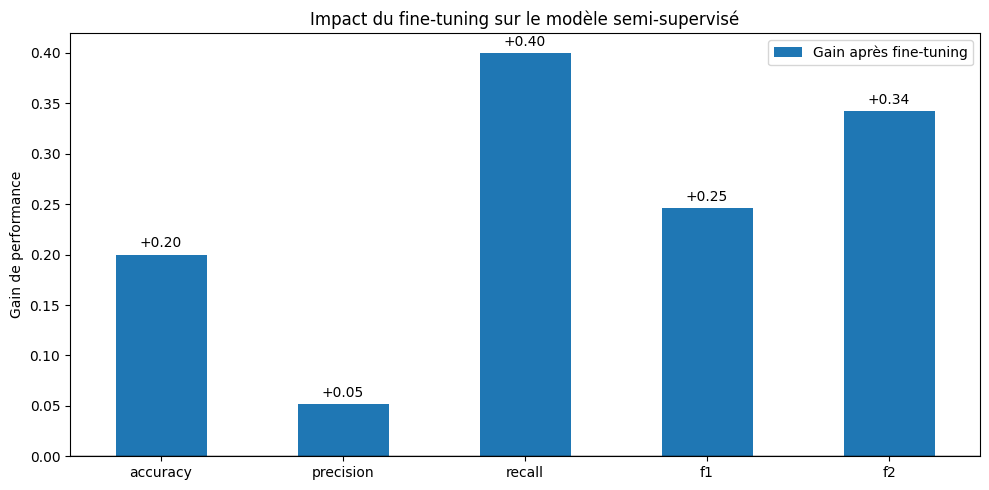

In [4073]:
metrics = ["accuracy", "precision", "recall", "f1", "f2"]

gain_finetuning = (
    pd.Series(semi_metrics)[metrics].astype(float)
    - pd.Series(semi_metrics_before)[metrics].astype(float)
)

gain_df = pd.DataFrame({
    "Gain après fine-tuning": gain_finetuning
})

ax = gain_df.plot(
    kind="bar",
    figsize=(10, 5)
)

ax.axhline(0, color="black", linewidth=1)

ax.set_title("Impact du fine-tuning sur le modèle semi-supervisé")
ax.set_ylabel("Gain de performance")
ax.set_xticklabels(metrics, rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt="%+.2f", padding=3)

plt.tight_layout()
plt.show()

<h4 style="color:#48C9B0;">Analyse de l'impact du fine-tuning</h4>

<p style="line-height:1.7;">
Le fine-tuning réalisé sur les données fortement annotées améliore l'ensemble des métriques de performance du modèle semi-supervisé. Cette étape permet de corriger une partie des erreurs introduites lors de la pseudo-labellisation tout en adaptant les représentations apprises à la tâche médicale étudiée.
</p>

<p style="line-height:1.7;">
L'amélioration la plus importante concerne le <b>rappel</b>, qui progresse de <b>+0,40</b>. Ce résultat est particulièrement important dans le contexte du projet, car il traduit une meilleure capacité du modèle à détecter les images cancéreuses et à limiter le nombre de faux négatifs.
</p>

<p style="line-height:1.7;">
L'<b>accuracy</b> progresse de <b>+0,20</b>, tandis que le <b>score F1</b> augmente de <b>+0,25</b>. Ces gains montrent que le modèle améliore simultanément ses performances globales et l'équilibre entre précision et rappel.
</p>

<p style="line-height:1.7;">
La <b>précision</b> progresse plus modestement avec un gain de <b>+0,05</b>. Cette évolution suggère que le principal apport du fine-tuning réside davantage dans l'amélioration de la détection des cas positifs que dans la réduction des faux positifs.
</p>

<p style="line-height:1.7;">
Le <b>score F2</b>, qui accorde davantage d'importance au rappel, augmente de <b>+0,34</b>. Cette progression confirme que le fine-tuning renforce principalement la sensibilité du modèle, ce qui correspond à l'objectif prioritaire du projet où manquer un cancer est plus critique que générer un faux positif.
</p>

<p style="line-height:1.7;">
Ces résultats montrent que le pré-entraînement sur les pseudo-labels fournit une base d'apprentissage utile, tandis que le fine-tuning sur les labels réels permet d'affiner les connaissances acquises et de corriger une partie du bruit introduit par la pseudo-labellisation.
</p>

<p style="line-height:1.7;">
L'amélioration simultanée de toutes les métriques suggère que les informations apprises lors de la phase semi-supervisée ont été conservées puis enrichies par les données annotées. Le fine-tuning agit ainsi comme une étape de spécialisation qui transforme des connaissances approximatives issues du clustering en représentations plus adaptées à la classification médicale.
</p>

8.12 Comparaison des performances

<div style="border-left:5px solid #48C9B0;
background:#f8fdfc;
padding:14px 18px;
margin:18px 0;
color:black;">

<b style="color:black;">Comparaison globale des performances des modèles</b><br><br>

<p>Après avoir entraîné et évalué les différentes approches étudiées, je rassemble les principales métriques de performance afin de comparer objectivement l'apprentissage supervisé et l'apprentissage semi-supervisé.</p>

<p>Cette comparaison repose sur cinq indicateurs complémentaires : <b>l'accuracy</b>, qui mesure la proportion globale de prédictions correctes, <b>la précision</b>, qui évalue la fiabilité des prédictions positives, <b>le rappel</b>, qui mesure la capacité du modèle à détecter les cas cancéreux, <b>le score F1</b>, qui équilibre précision et rappel, ainsi que <b>le score F2</b>, particulièrement pertinent dans ce contexte médical puisqu'il accorde davantage d'importance au rappel.</p>

<p>Trois configurations sont comparées :</p>

<ul>
<li><b>Le modèle supervisé</b>, entraîné uniquement sur les images disposant d'un label réel ;</li>
<li><b>Le modèle semi-supervisé avant fine-tuning</b>, pré-entraîné exclusivement sur les pseudo-labels générés par le clustering ;</li>
<li><b>Le modèle semi-supervisé final</b>, obtenu après ajustement sur les données fortement annotées.</li>
</ul>

<p>Le tableau récapitulatif permet d'obtenir les valeurs exactes de chaque métrique tandis que la représentation graphique facilite l'identification des écarts de performance entre les différentes approches.</p>

<p>Cette analyse constitue l'étape finale de l'évaluation expérimentale. Elle permet de mesurer l'apport réel de la pseudo-labellisation, d'évaluer l'intérêt du fine-tuning sur labels réels et de vérifier si l'exploitation des données non annotées améliore les performances du modèle par rapport à une approche supervisée classique.</p>

</div>

<h4 style="color:#48C9B0;">Synthèse comparative des résultats</h4>

<p style="line-height:1.7;">
Les résultats présentés ci-dessous permettent d'analyser l'évolution des performances tout au long du pipeline semi-supervisé. La comparaison entre le modèle supervisé et le modèle semi-supervisé final permet notamment d'évaluer la contribution des données non annotées dans l'apprentissage.
</p>

<p style="line-height:1.7;">
Une attention particulière est portée aux scores de <b>Recall</b> et de <b>F2</b>, qui constituent les indicateurs les plus importants pour ce projet. En effet, dans un contexte de détection de cancer, l'objectif prioritaire consiste à limiter le nombre de faux négatifs afin de réduire le risque qu'une image cancéreuse soit classée comme normale.
</p>

<p style="line-height:1.7;">
Les écarts observés permettront de déterminer si la stratégie combinant clustering, pseudo-labellisation et fine-tuning apporte un bénéfice mesurable par rapport à un apprentissage reposant uniquement sur les données annotées disponibles.
</p>


In [4074]:
comparison_df = pd.DataFrame([
    {
        "Approche": "Supervisée seule",
        **supervised_metrics
    },
    {
        "Approche": "S-supervisée av.ft",
        **semi_metrics_before
    },
    {
        "Approche": "S-supervisée apr.ft",
        **semi_metrics
    }
])

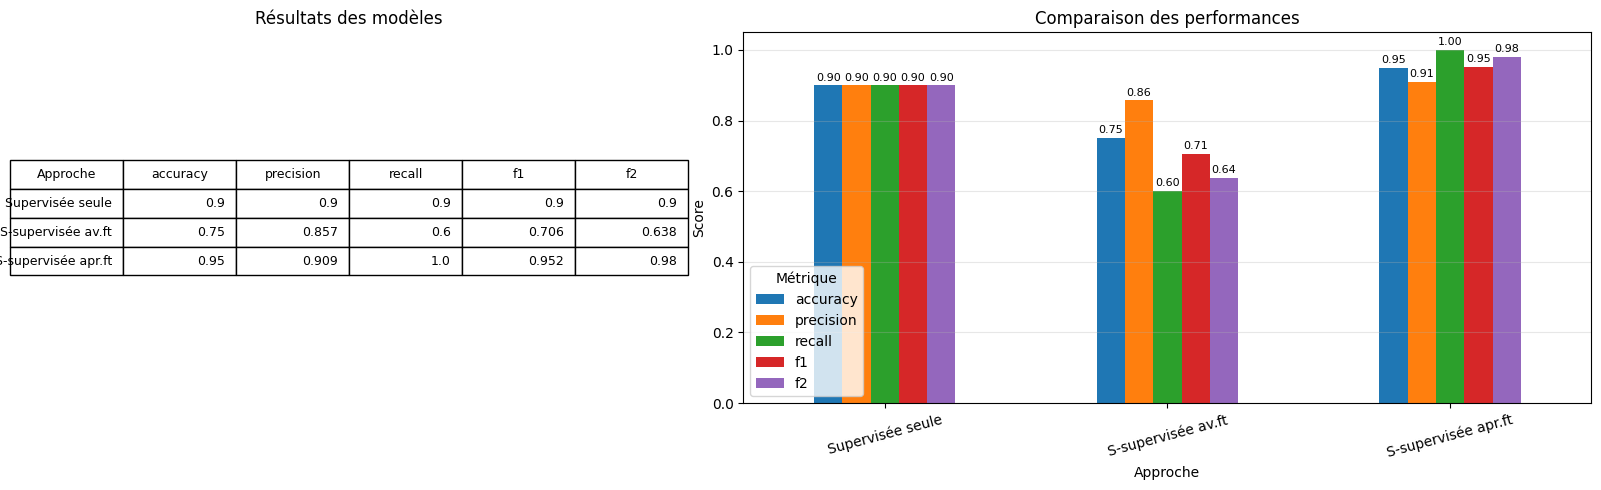

In [4075]:
# Tableau + graphique côte à côte
fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 5),
    gridspec_kw={"width_ratios": [1.2, 1.8]}
)

# Tableau
axes[0].axis("off")
table_data = comparison_df.copy()
table = axes[0].table(
    cellText=table_data.round(3).values,
    colLabels=table_data.columns,
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.8)

axes[0].set_title("Résultats des modèles")

# Graphique
df_comparison_plot = comparison_df.set_index("Approche")

ax = df_comparison_plot.plot(
    kind="bar",
    ax=axes[1]
)

axes[1].set_title("Comparaison des performances")
axes[1].set_ylabel("Score")
axes[1].set_ylim(0, 1.05)
axes[1].tick_params(axis="x", rotation=15)
axes[1].legend(title="Métrique")
axes[1].grid(axis="y", alpha=0.3)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=2,
        fontsize=8
    )

plt.tight_layout()
plt.show()

<h4 style="color:#48C9B0;">Analyse comparative des performances</h4>

<p style="line-height:1.7;">
Le modèle supervisé constitue la référence de l'étude puisqu'il est entraîné exclusivement sur les données disposant d'annotations réelles. Il obtient des performances élevées avec une accuracy, une précision, un rappel, un score F1 et un score F2 de <b>0,90</b>.
</p>

<p style="line-height:1.7;">
Le modèle semi-supervisé évalué immédiatement après le pré-entraînement sur les pseudo-labels présente des performances plus modestes. Son rappel atteint <b>0,60</b> et son score F1 <b>0,706</b>. Ces résultats restent néanmoins encourageants compte tenu du fait que le modèle a été entraîné uniquement à partir de labels générés automatiquement par le processus de clustering.
</p>

<p style="line-height:1.7;">
Après la phase de fine-tuning réalisée sur les données fortement annotées, les performances progressent fortement sur l'ensemble des métriques. Le rappel atteint <b>1,00</b>, ce qui signifie qu'aucun cas cancéreux n'est manqué parmi les observations du jeu de test. Le score F2 atteint <b>0,98</b>, confirmant l'amélioration de la capacité de détection du modèle sur le critère prioritaire du projet.
</p>

<p style="line-height:1.7;">
Les performances finales du modèle semi-supervisé dépassent légèrement celles du modèle supervisé de référence. L'accuracy atteint <b>0,95</b> contre <b>0,90</b> pour le modèle supervisé, tandis que le score F1 progresse à <b>0,952</b>. Cette amélioration suggère que les informations extraites des données non annotées apportent un complément utile aux données annotées disponibles.
</p>

<p style="line-height:1.7;">
La comparaison entre les deux versions du modèle semi-supervisé met clairement en évidence l'importance du fine-tuning. Le pré-entraînement sur les pseudo-labels permet au modèle d'apprendre une première représentation des données non annotées, tandis que l'ajustement sur les labels réels corrige une partie du bruit introduit par la pseudo-labellisation et spécialise le modèle sur la tâche médicale étudiée.
</p>

<p style="line-height:1.7;">
Ces résultats montrent que l'approche semi-supervisée est capable d'exploiter efficacement les informations contenues dans les données non annotées. Néanmoins, le jeu de test restant de taille limitée, les écarts observés doivent être interprétés avec prudence. Les performances obtenues suggèrent un bénéfice potentiel de l'approche semi-supervisée, mais des expérimentations complémentaires sur un volume plus important de données seraient nécessaires pour confirmer statistiquement cet avantage.
</p>

<div style="border-left:5px solid #48C9B0;
background:#f8fdfc;
padding:14px 18px;
margin:18px 0;
color:black;">

<b style="color:black;">Analyse des matrices de confusion</b><br><br>

<p>Les matrices de confusion permettent d'étudier en détail le comportement des différents modèles en distinguant les prédictions correctes des erreurs de classification. Contrairement aux métriques globales, elles offrent une vision précise de la nature des erreurs commises et de leur répartition entre les classes <i>Normal</i> et <i>Cancer</i>.</p>

<p>La première matrice correspond au <b>modèle supervisé</b>, entraîné uniquement à partir des images annotées. Elle constitue la référence utilisée pour comparer les performances des approches semi-supervisées.</p>

<p>La deuxième matrice présente les résultats du <b>modèle semi-supervisé après pré-entraînement sur les pseudo-labels</b>. Cette étape permet d'évaluer la qualité des représentations apprises à partir des données non annotées avant toute correction par les labels réels.</p>

<p>La troisième matrice correspond au <b>modèle semi-supervisé final après fine-tuning</b>. Sa comparaison avec la matrice précédente permet d'identifier l'impact réel des données fortement annotées sur la correction des erreurs héritées de la pseudo-labellisation.</p>

<p>Cette analyse est particulièrement importante dans le contexte médical du projet. Les <b>faux négatifs</b>, correspondant à des images cancéreuses classées comme normales, représentent l'erreur la plus critique puisqu'ils peuvent conduire à manquer un cas pathologique. Les <b>faux positifs</b>, bien que moins problématiques, restent également à surveiller car ils peuvent générer des examens complémentaires inutiles.</p>

<p>Les matrices de confusion complètent ainsi l'analyse des métriques globales en mettant en évidence les mécanismes qui expliquent les variations observées sur le rappel, la précision, les scores F1 et F2 au cours des différentes phases d'apprentissage.</p>

</div>

<h4 style="color:#48C9B0;">Comparaison des erreurs de classification</h4>

<p style="line-height:1.7;">
L'évolution des matrices de confusion permet d'observer comment les erreurs de classification sont progressivement corrigées au cours du pipeline semi-supervisé. Une attention particulière est portée à la réduction des faux négatifs, objectif principal de cette étude compte tenu des enjeux liés à la détection des cancers.
</p>

<p style="line-height:1.7;">
La comparaison entre les trois modèles permet également de vérifier si l'exploitation des données non annotées apporte une information utile ou si elle introduit au contraire du bruit susceptible de dégrader les performances. Les résultats observés dans les matrices seront interprétés conjointement avec les métriques précédemment calculées afin d'obtenir une évaluation complète de chaque approche.
</p>

<p style="line-height:1.7;">
Compte tenu de la taille limitée du jeu de test, les résultats doivent toutefois être interprétés avec prudence. Une seule image mal classée peut entraîner une variation importante des métriques ainsi que de la structure des matrices de confusion observées.
</p>


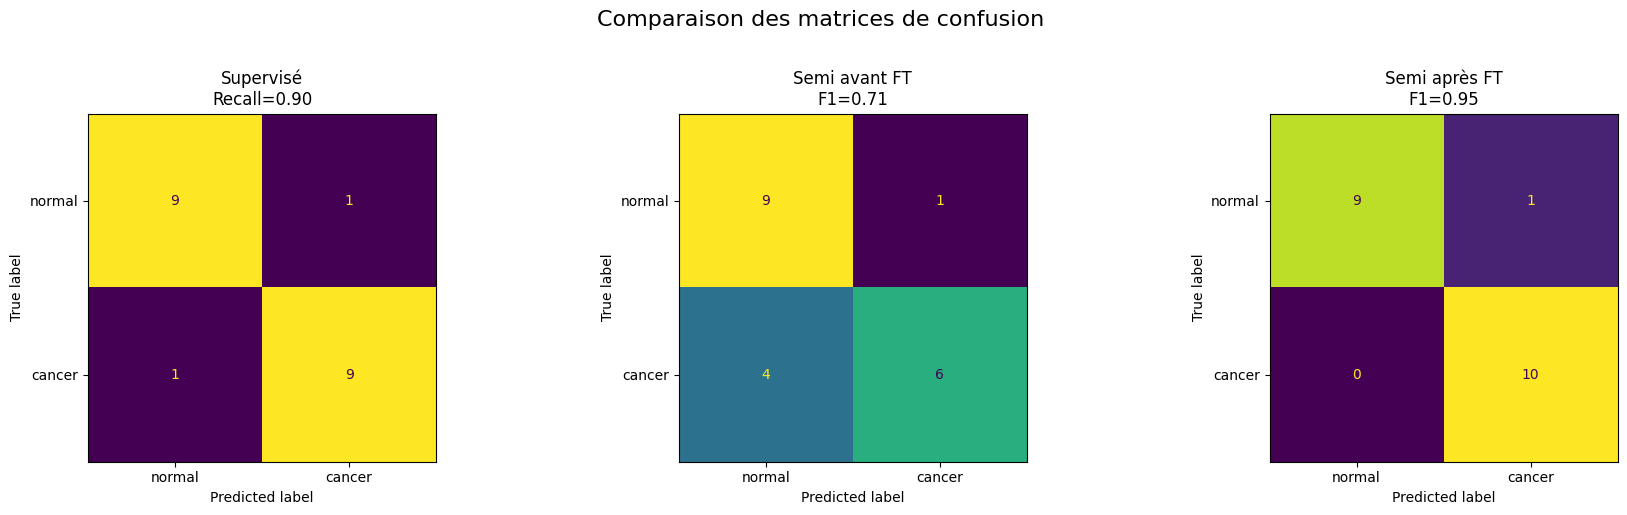

In [4076]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Supervisé
ConfusionMatrixDisplay.from_predictions(
    y_true_sup,
    y_pred_sup,
    display_labels=["normal", "cancer"],
    ax=axes[0],
    colorbar=False
)

axes[0].set_title(
    f"Supervisé\nRecall={supervised_metrics['recall']:.2f}"
)

# Semi-supervisé avant fine-tuning
ConfusionMatrixDisplay.from_predictions(
    y_true_before,
    y_pred_before,
    display_labels=["normal", "cancer"],
    ax=axes[1],
    colorbar=False
)

axes[1].set_title(
    f"Semi avant FT\nF1={semi_metrics_before['f1']:.2f}"
)

# Semi-supervisé après fine-tuning
ConfusionMatrixDisplay.from_predictions(
    y_true_semi,
    y_pred_semi,
    display_labels=["normal", "cancer"],
    ax=axes[2],
    colorbar=False
)

axes[2].set_title(
    f"Semi après FT\nF1={semi_metrics['f1']:.2f}"
)

plt.suptitle(
    "Comparaison des matrices de confusion",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

<h4 style="color:#48C9B0;">Interprétation des matrices de confusion</h4>

<p style="line-height:1.7;">
Les matrices de confusion complètent l'analyse des métriques globales en mettant en évidence la nature exacte des erreurs commises par chaque modèle.
</p>

<p style="line-height:1.7;">
Le <b>modèle supervisé</b> obtient une matrice très équilibrée avec <b>18 prédictions correctes sur 20 images</b>. Une image normale est classée à tort comme cancéreuse et une image cancéreuse est classée comme normale. Cette répartition explique les scores homogènes observés précédemment, avec un rappel de <b>0,90</b> et un score F1 de <b>0,90</b>.
</p>

<p style="line-height:1.7;">
Le <b>modèle semi-supervisé avant fine-tuning</b> conserve une bonne capacité à identifier les images normales puisque 9 des 10 cas sont correctement classés. En revanche, il ne détecte correctement que <b>6 cancers sur 10</b> et produit <b>4 faux négatifs</b>. Cette difficulté explique la baisse du rappel à <b>0,60</b> et montre que les représentations apprises uniquement à partir des pseudo-labels restent insuffisantes pour une détection fiable des cas pathologiques.
</p>

<p style="line-height:1.7;">
Après la phase de <b>fine-tuning sur les données annotées</b>, les performances progressent fortement. Le modèle détecte correctement <b>les 10 cancers présents dans le jeu de test</b> et ne produit donc <b>aucun faux négatif</b>. Cette amélioration se traduit directement par un rappel de <b>1,00</b>, ce qui constitue un résultat particulièrement intéressant dans le contexte médical du projet.
</p>

<p style="line-height:1.7;">
Le modèle semi-supervisé final conserve par ailleurs un très bon niveau de précision. Une seule image normale est classée comme cancéreuse, soit le même nombre de faux positifs que le modèle supervisé. Les gains observés proviennent donc essentiellement de la disparition des faux négatifs sans augmentation notable des erreurs sur les images normales.
</p>

<p style="line-height:1.7;">
Ces résultats montrent que le pré-entraînement sur pseudo-labels fournit une base d'apprentissage utile mais encore imparfaite. Le fine-tuning sur les labels réels joue ensuite un rôle déterminant en corrigeant les erreurs les plus critiques et en améliorant fortement la détection des cas cancéreux.
</p>

<p style="line-height:1.7;">
Dans une perspective médicale, le modèle semi-supervisé final apparaît particulièrement intéressant puisqu'il ne manque aucun cancer sur le jeu de test tout en conservant un nombre limité de faux positifs. Ce compromis est généralement préférable dans un contexte de dépistage où l'absence de faux négatifs constitue un objectif prioritaire.
</p>

<p style="line-height:1.7;">
Ces résultats doivent néanmoins être interprétés avec prudence compte tenu de la taille limitée du jeu de test. Avec seulement vingt images évaluées, une ou deux erreurs supplémentaires pourraient modifier sensiblement les métriques observées.
</p>

<div style="border-left:5px solid #48C9B0;
background:#f8fdfc;
padding:14px 18px;
margin:18px 0;
color:black;">

<b style="color:black;">Analyse des courbes d'apprentissage</b><br><br>

<p>Afin de mieux comprendre le comportement des différents modèles au cours de l'entraînement, j'analyse l'évolution de la perte (<i>loss</i>) et du rappel (<i>Recall</i>) sur les jeux d'entraînement et de validation.</p>

<p>Cette analyse permet d'étudier la dynamique d'apprentissage des modèles, d'évaluer leur capacité de généralisation et d'identifier d'éventuels phénomènes de sous-apprentissage ou de surapprentissage.</p>

<p>Les graphiques de la première ligne présentent l'évolution de la fonction de perte. Une diminution progressive de la perte d'entraînement traduit l'amélioration des prédictions du modèle au fil des itérations. La comparaison avec la perte de validation permet de vérifier si cette amélioration se généralise à des données non utilisées lors de l'apprentissage.</p>

<p>Les graphiques de la seconde ligne présentent l'évolution du rappel (<i>Recall</i>), métrique particulièrement importante dans ce projet. En effet, l'objectif principal consiste à maximiser la détection des images cancéreuses et donc à limiter le nombre de faux négatifs.</p>

<p>Les courbes permettent également de comparer les trois étapes du pipeline : l'entraînement supervisé, le pré-entraînement semi-supervisé sur les pseudo-labels et le fine-tuning réalisé sur les données fortement annotées.</p>

<p>L'analyse conjointe de ces courbes complète les métriques finales en apportant une vision dynamique du processus d'apprentissage et des mécanismes ayant conduit aux performances observées sur le jeu de test.</p>

</div>

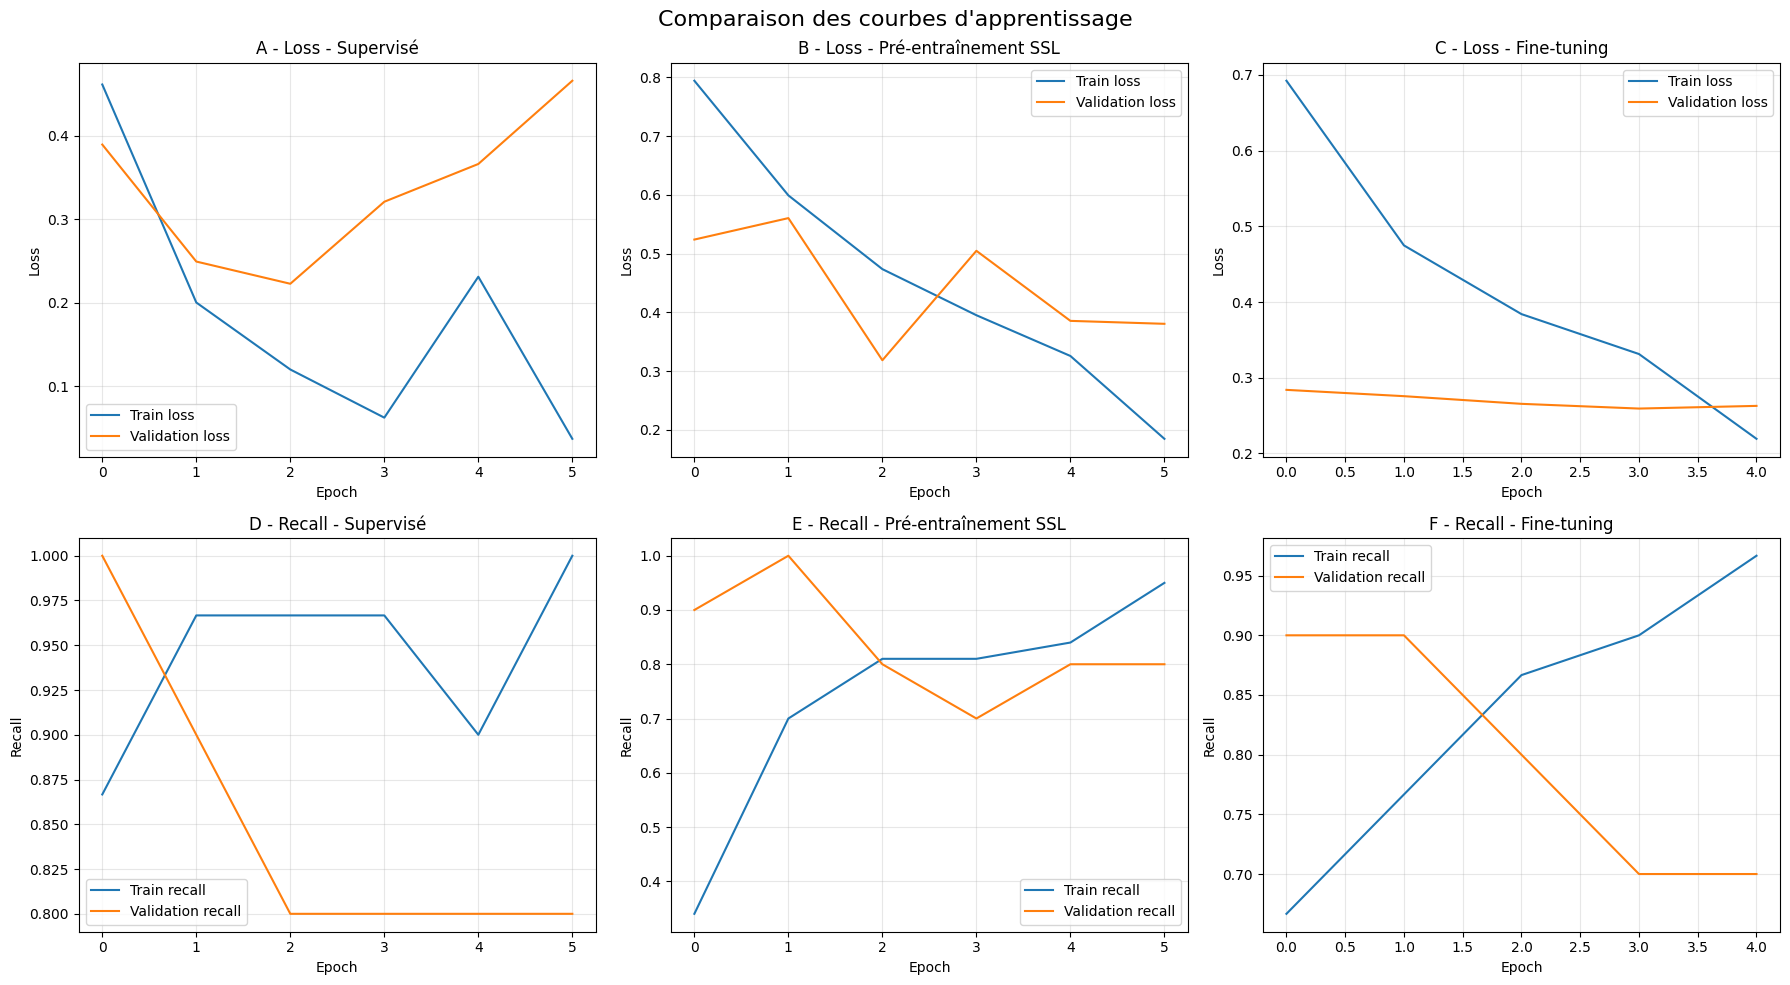

In [4077]:
fig, axes = plt.subplots(
    2,
    3,
    figsize=(18, 10)
)

# Loss

# Supervisé
axes[0, 0].plot(
    history_supervised["train_loss"],
    label="Train loss"
)

axes[0, 0].plot(
    history_supervised["val_loss"],
    label="Validation loss"
)

axes[0, 0].set_title("A - Loss - Supervisé")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Loss")
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Semi avant fine-tuning
axes[0, 1].plot(
    history_weak["train_loss"],
    label="Train loss"
)

axes[0, 1].plot(
    history_weak["val_loss"],
    label="Validation loss"
)

axes[0, 1].set_title("B - Loss - Pré-entraînement SSL")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Loss")
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Semi après fine-tuning
axes[0, 2].plot(
    history_finetune["train_loss"],
    label="Train loss"
)

axes[0, 2].plot(
    history_finetune["val_loss"],
    label="Validation loss"
)

axes[0, 2].set_title("C - Loss - Fine-tuning")
axes[0, 2].set_xlabel("Epoch")
axes[0, 2].set_ylabel("Loss")
axes[0, 2].legend()
axes[0, 2].grid(alpha=0.3)

# Recall

# Supervisé
axes[1, 0].plot(
    history_supervised["train_recall"],
    label="Train recall"
)

axes[1, 0].plot(
    history_supervised["val_recall"],
    label="Validation recall"
)

axes[1, 0].set_title("D - Recall - Supervisé")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Recall")
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Semi avant fine-tuning
axes[1, 1].plot(
    history_weak["train_recall"],
    label="Train recall"
)

axes[1, 1].plot(
    history_weak["val_recall"],
    label="Validation recall"
)

axes[1, 1].set_title("E - Recall - Pré-entraînement SSL")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("Recall")
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

# Semi après fine-tuning
axes[1, 2].plot(
    history_finetune["train_recall"],
    label="Train recall"
)

axes[1, 2].plot(
    history_finetune["val_recall"],
    label="Validation recall"
)

axes[1, 2].set_title("F - Recall - Fine-tuning")
axes[1, 2].set_xlabel("Epoch")
axes[1, 2].set_ylabel("Recall")
axes[1, 2].legend()
axes[1, 2].grid(alpha=0.3)

plt.suptitle(
    "Comparaison des courbes d'apprentissage",
    fontsize=16
)

plt.tight_layout()
plt.show()

<h4 style="color:#48C9B0;">Interprétation des courbes d'apprentissage</h4>

<p style="line-height:1.7;">
Les courbes d'apprentissage mettent en évidence des comportements distincts entre l'approche supervisée, le pré-entraînement semi-supervisé et la phase de fine-tuning. Elles permettent d'analyser à la fois l'évolution de la fonction de perte et la capacité des modèles à détecter les cas cancéreux au cours de l'entraînement.
</p>

<p style="line-height:1.7;">
Pour le <b>modèle supervisé</b>, la perte d'entraînement diminue rapidement alors que la perte de validation cesse de s'améliorer après les premières époques avant d'augmenter progressivement. Cette divergence entre les deux courbes suggère l'apparition d'un phénomène de surapprentissage, probablement lié au faible nombre d'images annotées disponibles.
</p>

<p style="line-height:1.7;">
L'évolution du rappel confirme cette observation. Le rappel d'entraînement atteint rapidement des valeurs très élevées tandis que le rappel de validation se stabilise autour de <b>0,80</b>. Le modèle continue donc à s'adapter aux données d'entraînement sans obtenir de gain significatif sur les données non observées.
</p>

<p style="line-height:1.7;">
Lors du <b>pré-entraînement semi-supervisé</b>, la perte d'entraînement diminue régulièrement, montrant que le modèle apprend à partir des pseudo-labels générés par le clustering. La perte de validation reste cependant plus instable, ce qui reflète la présence de bruit et d'incertitude dans les pseudo-labels utilisés.
</p>

<p style="line-height:1.7;">
Le rappel de validation atteint ponctuellement des valeurs élevées puis oscille entre <b>0,70</b> et <b>0,80</b>. Cette évolution indique que les données non annotées contiennent une information exploitable, mais que les pseudo-labels seuls ne permettent pas encore d'obtenir un modèle suffisamment robuste.
</p>

<p style="line-height:1.7;">
La phase de <b>fine-tuning sur les labels réels</b> présente le comportement le plus régulier. La perte d'entraînement diminue fortement tandis que la perte de validation reste faible et relativement stable. Cette situation suggère que le modèle affine efficacement les connaissances acquises lors du pré-entraînement sans montrer de signe marqué de surapprentissage.
</p>

<p style="line-height:1.7;">
Le rappel de validation reste élevé tout au long du fine-tuning malgré une légère baisse en fin d'entraînement. Cette stabilité montre que les annotations réelles permettent de corriger une partie des erreurs héritées de la pseudo-labellisation tout en conservant les représentations apprises sur les données non annotées.
</p>

<p style="line-height:1.7;">
Dans l'ensemble, ces courbes suggèrent que le pré-entraînement semi-supervisé fournit une base d'apprentissage utile mais imparfaite. Le fine-tuning sur les labels réels joue ensuite un rôle essentiel pour spécialiser le modèle sur la tâche médicale étudiée et obtenir les meilleures performances finales observées sur le jeu de test.
</p>

In [4078]:
# Sauvegarde des résultats
comparison_df.to_csv(
    "../data/features/comparaison_supervise_semi_supervise.csv",
    index=False
)

print("Résultats sauvegardés.")

Résultats sauvegardés.


<h4 style="color:#48C9B0;">Définition d'un modèle opérationnel</h4>

<p style="line-height:1.7;">
Dans le cadre de ce projet, un modèle peut être considéré comme opérationnel uniquement s'il respecte plusieurs critères de validation.
</p>

<p style="line-height:1.7;">
Le critère prioritaire est le <b>rappel sur la classe Cancer</b>, car l'erreur la plus critique consiste à classer une image cancéreuse comme normale. Le modèle final doit donc maximiser la détection des cancers et limiter au maximum les faux négatifs.
</p>

<p style="line-height:1.7;">
Sur le jeu de test disponible, le modèle semi-supervisé final obtient un <b>rappel de 1,00</b>, ce qui signifie qu'aucun cas cancéreux n'est manqué parmi les images évaluées. Le score <b>F2 de 0,98</b> confirme également que le modèle est performant sur le critère prioritaire du projet.
</p>

<p style="line-height:1.7;">
Cependant, le jeu de test ne contient que <b>20 images</b>. Ces résultats sont donc encourageants, mais ils ne suffisent pas à valider un usage réel en production médicale. Le modèle peut être considéré comme opérationnel pour un <b>prototype expérimental</b>, mais pas encore pour une utilisation clinique.
</p>

<p style="line-height:1.7;">
Pour passer à un modèle réellement opérationnel, il faudrait confirmer ces performances sur un jeu de test externe plus volumineux, annoté par des experts, vérifier la stabilité des résultats sur plusieurs découpages de données, analyser les erreurs restantes et définir un seuil de décision adapté au niveau de risque acceptable.
</p>

### analyse de la robustesse des modéles

In [4081]:
strong_df = pd.concat(
    [
        strong_train_df,
        strong_val_df,
        strong_test_df
    ],
    ignore_index=True
)

print(len(strong_df))
print(strong_df["label"].value_counts())

99
label
1    50
0    49
Name: count, dtype: int64


In [4082]:
weak_df = pd.concat(
    [
        weak_train_df,
        weak_test_df
    ],
    ignore_index=True
)

print(len(weak_df))
print(weak_df["label"].value_counts())

594
label
1    354
0    240
Name: count, dtype: int64


In [4083]:
def verifier_split(train_df, val_df, test_df):
    print("Répartition train :")
    print(train_df["label"].value_counts())

    print("\nRépartition val :")
    print(val_df["label"].value_counts())

    print("\nRépartition test :")
    print(test_df["label"].value_counts())

    assert train_df["label"].nunique() == 2, "Train incomplet"
    assert val_df["label"].nunique() == 2, "Val incomplet"
    assert test_df["label"].nunique() == 2, "Test incomplet"

In [4084]:
if analyse_seed:
    SEEDS = [0, 42, 123, 2025, 999]

    resultats_multiseed = []

    for seed in SEEDS:
        print(f"\nSEED : {seed}")

        # Split 60 / 20 / 20
        train_df, temp_df = train_test_split(
            strong_df,
            test_size=0.40,
            stratify=strong_df["label"],
            random_state=seed
        )

        val_df, test_df = train_test_split(
            temp_df,
            test_size=0.50,
            stratify=temp_df["label"],
            random_state=seed
        )

        # Datasets forts
        train_dataset = BrainDataset(train_df, transform=train_transform)
        val_dataset = BrainDataset(val_df, transform=eval_transform)
        test_dataset = BrainDataset(test_df, transform=eval_transform)

        verifier_split(train_df, val_df, test_df)

        # Dataset faible
        weak_dataset = BrainDataset(weak_df, transform=train_transform)

        # Loaders
        train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
        test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
        weak_loader = DataLoader(weak_dataset, batch_size=BATCH_SIZE, shuffle=True)

        # Modèle supervisé
        supervised_model = create_resnet18_model()
        supervised_model = freeze_all_but_fc(supervised_model)
        supervised_model = supervised_model.to(device)

        optimizer_sup = torch.optim.AdamW(
            filter(lambda p: p.requires_grad, supervised_model.parameters()),
            lr=LEARNING_RATE,
            weight_decay=1e-4
        )

        supervised_model, history_sup = train_model(
            model=supervised_model,
            train_loader=train_loader,
            val_loader=val_loader,
            criterion=criterion,
            optimizer=optimizer_sup,
            num_epochs=NUM_EPOCHS_SUPERVISED,
            device=device,
            patience=PATIENCE
        )

        metrics_sup, _, _ = evaluate_model(
            supervised_model,
            test_loader,
            device
        )

        # Modèle semi-supervisé
        semi_model_seed = create_resnet18_model()
        semi_model_seed = freeze_all_but_layer4_and_fc(semi_model_seed)
        semi_model_seed = semi_model_seed.to(device)

        optimizer_weak = torch.optim.AdamW(
            filter(lambda p: p.requires_grad, semi_model_seed.parameters()),
            lr=LEARNING_RATE,
            weight_decay=1e-4
        )

        semi_model_seed, history_weak = train_model(
            model=semi_model_seed,
            train_loader=weak_loader,
            val_loader=val_loader,
            criterion=criterion,
            optimizer=optimizer_weak,
            num_epochs=NUM_EPOCHS_WEAK,
            device=device,
            patience=PATIENCE
        )

        # Fine-tuning sur les vrais labels
        semi_model_seed = freeze_all_but_layer4_and_fc(semi_model_seed)

        optimizer_ft = torch.optim.AdamW(
            filter(lambda p: p.requires_grad, semi_model_seed.parameters()),
            lr=LEARNING_RATE_FINE,
            weight_decay=1e-4
        )

        semi_model_seed, history_ft = train_model(
            model=semi_model_seed,
            train_loader=train_loader,
            val_loader=val_loader,
            criterion=criterion,
            optimizer=optimizer_ft,
            num_epochs=NUM_EPOCHS_FINETUNE,
            device=device,
            patience=PATIENCE_FINE
        )

        metrics_semi, _, _ = evaluate_model(
            semi_model_seed,
            test_loader,
            device
        )

        # Sauvegarde résultats
        resultats_multiseed.append({
            "seed": seed,

            "accuracy_supervise": metrics_sup["accuracy"],
            "precision_supervise": metrics_sup["precision"],
            "recall_supervise": metrics_sup["recall"],
            "f1_supervise": metrics_sup["f1"],
            "f2_supervise": metrics_sup["f2"],

            "accuracy_semi": metrics_semi["accuracy"],
            "precision_semi": metrics_semi["precision"],
            "recall_semi": metrics_semi["recall"],
            "f1_semi": metrics_semi["f1"],
            "f2_semi": metrics_semi["f2"],
        })

    df_multiseed = pd.DataFrame(resultats_multiseed)
    display(df_multiseed)


SEED : 0
Répartition train :
label
1    30
0    29
Name: count, dtype: int64

Répartition val :
label
1    10
0    10
Name: count, dtype: int64

Répartition test :
label
1    10
0    10
Name: count, dtype: int64
Epoch 1/20 | Train loss: 0.9043 | Train acc: 0.3051 | Train recall: 0.1000 | Train F1: 0.1277 | Train F2: 0.1095 | Val loss: 0.8427 | Val acc: 0.2500 | Val recall: 0.1000Val precision: 0.1429 | Val F1: 0.1176 | Val F2: 0.1064 | 
Epoch 2/20 | Train loss: 0.8999 | Train acc: 0.2542 | Train recall: 0.1000 | Train F1: 0.1200 | Train F2: 0.1071 | Val loss: 0.7822 | Val acc: 0.4000 | Val recall: 0.3000Val precision: 0.3750 | Val F1: 0.3333 | Val F2: 0.3125 | 
Epoch 3/20 | Train loss: 0.8235 | Train acc: 0.4407 | Train recall: 0.4667 | Train F1: 0.4590 | Train F2: 0.4636 | Val loss: 0.8035 | Val acc: 0.4000 | Val recall: 0.4000Val precision: 0.4000 | Val F1: 0.4000 | Val F2: 0.4000 | 
Epoch 4/20 | Train loss: 0.8505 | Train acc: 0.2881 | Train recall: 0.3000 | Train F1: 0.3000 | Trai

,seed,accuracy_supervise,precision_supervise,recall_supervise,f1_supervise,f2_supervise,accuracy_semi,precision_semi,recall_semi,f1_semi,f2_semi
0,0,0.45,0.461538,0.6,0.521739,0.566038,1.00,1.0,1.0,1.000000,1.000000
1,42,0.65,0.714286,0.5,0.588235,0.531915,0.95,1.0,0.9,0.947368,0.918367
2,123,0.95,1.000000,0.9,0.947368,0.918367,1.00,1.0,1.0,1.000000,1.000000
3,2025,0.60,0.571429,0.8,0.666667,0.740741,0.95,1.0,0.9,0.947368,0.918367
4,999,0.65,0.600000,0.9,0.720000,0.818182,0.90,0.9,0.9,0.900000,0.900000


In [ ]:
# Copie de sécurité
df_plot = df_multiseed.copy()

# Ordre des seeds en texte pour l'affichage
df_plot["seed_str"] = df_plot["seed"].astype(str)

# Création des gains si besoin
df_plot["gain_accuracy"] = df_plot["accuracy_semi"] - df_plot["accuracy_supervise"]
df_plot["gain_precision"] = df_plot["precision_semi"] - df_plot["precision_supervise"]
df_plot["gain_recall"] = df_plot["recall_semi"] - df_plot["recall_supervise"]
df_plot["gain_f1"] = df_plot["f1_semi"] - df_plot["f1_supervise"]
df_plot["gain_f2"] = df_plot["f2_semi"] - df_plot["f2_supervise"]

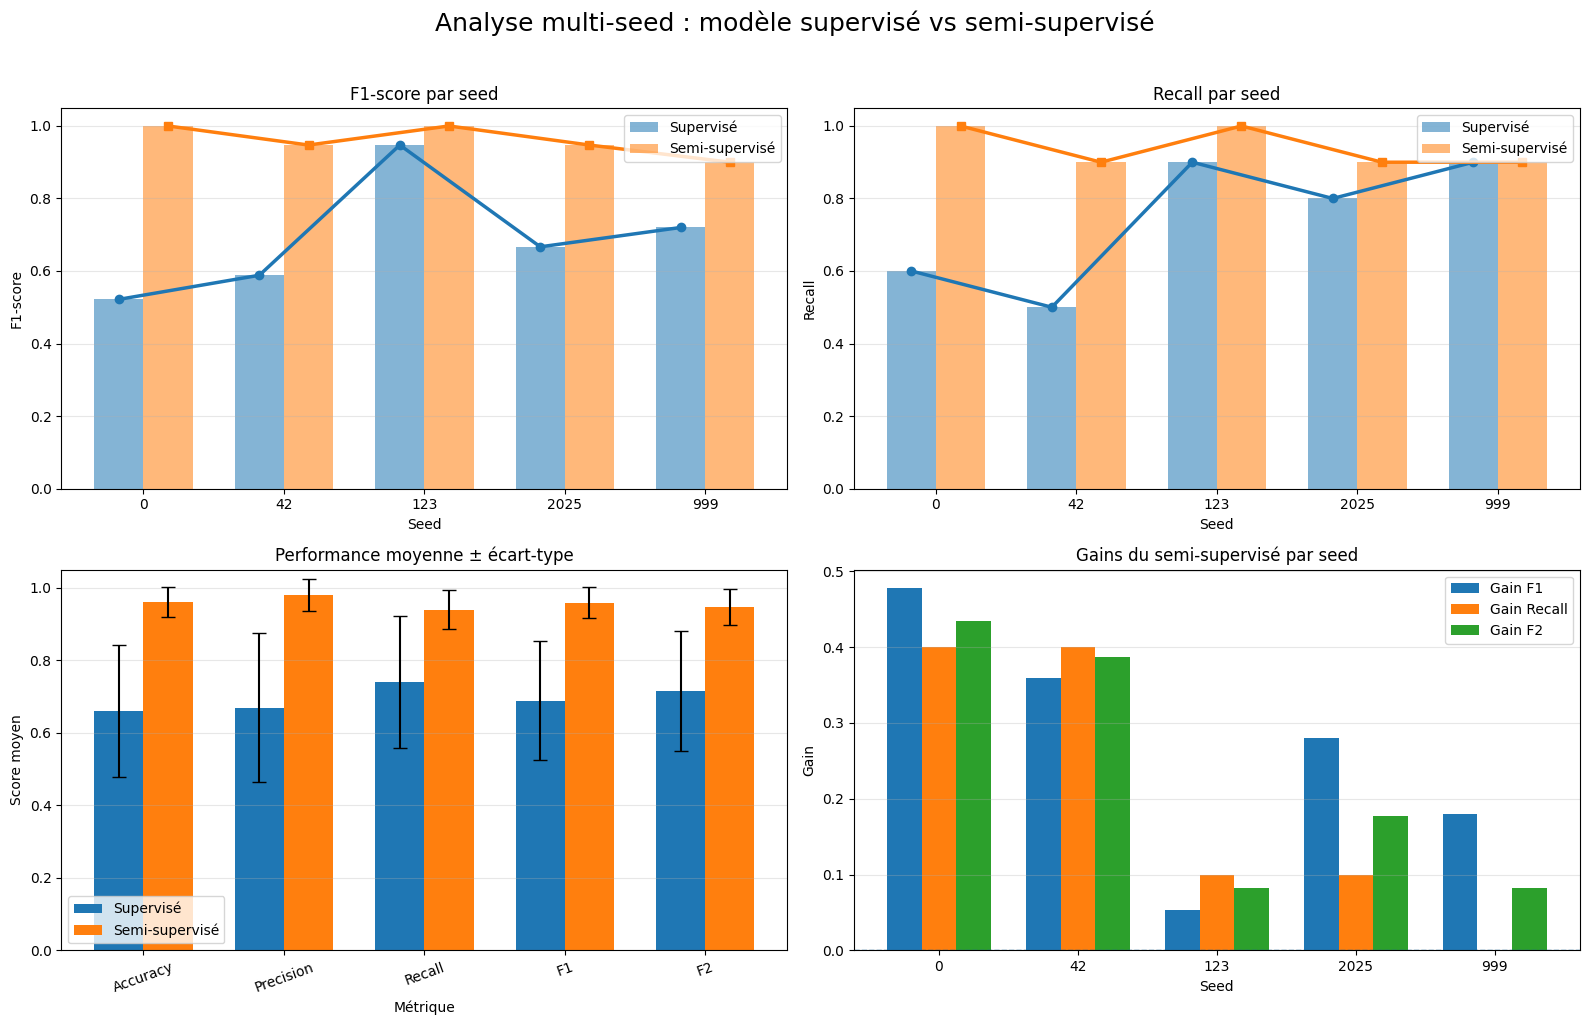

In [ ]:
# Seeds en catégories, pas en valeurs numériques continues
df_plot["seed_str"] = df_plot["seed"].astype(str)
x = np.arange(len(df_plot))
width = 0.35

# Gains si absents
df_plot["gain_f1"] = df_plot["f1_semi"] - df_plot["f1_supervise"]
df_plot["gain_recall"] = df_plot["recall_semi"] - df_plot["recall_supervise"]
df_plot["gain_f2"] = df_plot["f2_semi"] - df_plot["f2_supervise"]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. F1-score par seed
axes[0, 0].bar(
    x - width / 2,
    df_plot["f1_supervise"],
    width,
    alpha=0.55,
    label="Supervisé"
)

axes[0, 0].bar(
    x + width / 2,
    df_plot["f1_semi"],
    width,
    alpha=0.55,
    label="Semi-supervisé"
)

# Courbes
axes[0, 0].plot(
    x - width/2,
    df_plot["f1_supervise"],
    marker="o",
    linewidth=2.5
)

axes[0, 0].plot(
    x + width/2,
    df_plot["f1_semi"],
    marker="s",
    linewidth=2.5
)

axes[0, 0].set_title("F1-score par seed")
axes[0, 0].set_xlabel("Seed")
axes[0, 0].set_ylabel("F1-score")
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(df_plot["seed_str"])
axes[0, 0].set_ylim(0,1.05)
axes[0, 0].grid(axis="y", alpha=.3)
axes[0, 0].legend()

# 2. Recall par seed
axes[0,1].bar(
    x-width/2,
    df_plot["recall_supervise"],
    width,
    alpha=0.55,
    label="Supervisé"
)

axes[0,1].bar(
    x+width/2,
    df_plot["recall_semi"],
    width,
    alpha=0.55,
    label="Semi-supervisé"
)

# Courbes
axes[0,1].plot(
    x-width/2,
    df_plot["recall_supervise"],
    marker="o",
    linewidth=2.5
)

axes[0,1].plot(
    x+width/2,
    df_plot["recall_semi"],
    marker="s",
    linewidth=2.5
)

axes[0,1].set_title("Recall par seed")
axes[0,1].set_xlabel("Seed")
axes[0,1].set_ylabel("Recall")
axes[0,1].set_xticks(x)
axes[0,1].set_xticklabels(df_plot["seed_str"])
axes[0,1].set_ylim(0,1.05)
axes[0,1].grid(axis="y", alpha=.3)
axes[0,1].legend()

# 3. Moyenne ± écart-type
metrics = ["accuracy", "precision", "recall", "f1", "f2"]
labels = ["Accuracy", "Precision", "Recall", "F1", "F2"]

mean_supervise = [df_plot[f"{m}_supervise"].mean() for m in metrics]
std_supervise = [df_plot[f"{m}_supervise"].std() for m in metrics]

mean_semi = [df_plot[f"{m}_semi"].mean() for m in metrics]
std_semi = [df_plot[f"{m}_semi"].std() for m in metrics]

x_metrics = np.arange(len(metrics))

axes[1, 0].bar(
    x_metrics - width / 2,
    mean_supervise,
    width,
    yerr=std_supervise,
    capsize=5,
    label="Supervisé"
)

axes[1, 0].bar(
    x_metrics + width / 2,
    mean_semi,
    width,
    yerr=std_semi,
    capsize=5,
    label="Semi-supervisé"
)

axes[1, 0].set_title("Performance moyenne ± écart-type")
axes[1, 0].set_xlabel("Métrique")
axes[1, 0].set_ylabel("Score moyen")
axes[1, 0].set_xticks(x_metrics)
axes[1, 0].set_xticklabels(labels, rotation=20)
axes[1, 0].set_ylim(0, 1.05)
axes[1, 0].grid(axis="y", alpha=0.3)
axes[1, 0].legend()

# 4. Gains du semi-supervisé
gain_metrics = ["gain_f1", "gain_recall", "gain_f2"]
gain_labels = ["Gain F1", "Gain Recall", "Gain F2"]

x_gain = np.arange(len(df_plot))
gain_width = 0.25

for i, gain in enumerate(gain_metrics):
    axes[1, 1].bar(
        x_gain + (i - 1) * gain_width,
        df_plot[gain],
        gain_width,
        label=gain_labels[i]
    )

axes[1, 1].axhline(0, linestyle="--", linewidth=1)
axes[1, 1].set_title("Gains du semi-supervisé par seed")
axes[1, 1].set_xlabel("Seed")
axes[1, 1].set_ylabel("Gain")
axes[1, 1].set_xticks(x_gain)
axes[1, 1].set_xticklabels(df_plot["seed_str"])
axes[1, 1].grid(axis="y", alpha=0.3)
axes[1, 1].legend()

# Mise en forme générale
fig.suptitle(
    "Analyse multi-seed : modèle supervisé vs semi-supervisé",
    fontsize=18,
    y=1.02
)

plt.tight_layout()
plt.show()

<h3 style="color:#48C9B0;">Analyse de la robustesse du modèle sur plusieurs seeds</h3>

<div style="border-left:5px solid #48C9B0;
background:#f8fdfc;
padding:14px 18px;
margin:18px 0;
color:black;">

<b style="color:black;">Objectif</b><br><br>

<p>
Afin d'évaluer la robustesse des résultats obtenus, j'ai répété l'ensemble de la phase d'entraînement sur <b>cinq découpages aléatoires différents</b> des données fortement labellisées (seeds 0, 42, 123, 2025 et 999). Le jeu faiblement labellisé (<code>weak_df</code>) est volontairement conservé identique afin d'isoler uniquement l'impact de la variabilité des données annotées sur les performances finales.
</p>

</div>

<h4 style="color:#48C9B0;">Comparaison des performances par seed</h4>

<p>
Les deux premiers graphiques montrent l'évolution du <b>F1-score</b> et du <b>Recall</b> pour chacun des cinq découpages.
</p>

<ul>

<li>
Le modèle <b>supervisé</b> présente une forte variabilité selon le découpage des données. Son F1-score varie d'environ <b>0,52 à 0,95</b>, tandis que le Recall fluctue entre <b>0,50 et 0,90</b>. Cette instabilité est attendue compte tenu du faible nombre d'images fortement annotées disponibles pour l'entraînement.
</li>

<li>
À l'inverse, le modèle <b>semi-supervisé</b> conserve des performances élevées pour l'ensemble des seeds. Le F1-score reste compris entre <b>0,90 et 1,00</b>, tandis que le Recall varie seulement entre <b>0,90 et 1,00</b>.
</li>

<li>
Le bénéfice du pré-entraînement sur les pseudo-labels apparaît particulièrement marqué lorsque le découpage supervisé est défavorable. Par exemple, pour la seed <b>0</b>, le F1-score passe de <b>0,52 à 1,00</b>, soit un gain de près de <b>48 points</b>.
</li>

</ul>

<h4 style="color:#48C9B0;">Analyse de la stabilité des modèles</h4>

<p>
Le troisième graphique compare les performances moyennes obtenues sur les cinq découpages, accompagnées de leur écart-type.
</p>

<ul>

<li>
Le modèle supervisé obtient une moyenne d'environ <b>0,69 en F1</b>, mais avec une dispersion importante, traduisant une forte sensibilité au choix du découpage des données.
</li>

<li>
Le modèle semi-supervisé atteint une moyenne proche de <b>0,96 en F1</b>, tout en présentant une variabilité beaucoup plus faible.
</li>

<li>
Cette diminution de l'écart-type montre que le pré-entraînement sur les données pseudo-labellisées fournit une représentation plus robuste avant le fine-tuning sur les données annotées.
</li>

</ul>

<h4 style="color:#48C9B0;">Analyse des gains du semi-supervisé</h4>

<p>
Le dernier graphique présente les gains obtenus par le modèle semi-supervisé relativement au modèle supervisé.
</p>

<ul>

<li>
Les gains sont positifs pour l'ensemble des métriques et pour toutes les seeds.
</li>

<li>
L'amélioration est particulièrement importante lorsque le modèle supervisé obtient des performances modestes, ce qui suggère que le pré-entraînement sur les pseudo-labels compense efficacement le manque de données annotées.
</li>

<li>
Lorsque le modèle supervisé est déjà performant (seed 123), le gain devient naturellement plus faible, ce qui indique que le modèle semi-supervisé ne dégrade jamais les performances mais apporte surtout un bénéfice lorsque les données d'entraînement sont moins favorables.
</li>

</ul>

<h4 style="color:#48C9B0;">Conclusion</h4>

<p>
Cette étude multi-seed montre que l'approche semi-supervisée ne se contente pas d'améliorer les performances moyennes : elle les rend également <b>beaucoup plus stables</b> face aux variations du jeu d'entraînement fortement annoté. Dans un contexte médical où les données labellisées sont rares et coûteuses à produire, cette robustesse constitue un avantage majeur. Les résultats obtenus suggèrent que le pré-entraînement sur des pseudo-labels de haute confiance permet de construire une représentation plus générale des images avant le fine-tuning supervisé, réduisant ainsi la dépendance au découpage aléatoire des données.
</p>

<div style="border-left:4px solid #48C9B0; background:#f8fdfc; color: black; padding:14px 18px; margin:18px 0;">

<b>Objectif</b><br><br>

<p style="line-height:1.7;">
Je réalise une analyse par budget de labels afin d'évaluer l'intérêt de l'approche semi-supervisée lorsque le nombre d'images réellement annotées est limité.
</p>

<p style="line-height:1.7;">
Pour chaque budget, je construis un petit jeu d'entraînement équilibré entre les profils <i>Normal</i> et <i>Cancer</i>. J'entraîne ensuite deux modèles dans les mêmes conditions : un modèle supervisé utilisant uniquement ces labels réels, et un modèle semi-supervisé pré-entraîné sur les pseudo-labels puis ajusté sur le même petit jeu annoté.
</p>

<p style="line-height:1.7;">
Cette expérimentation permet de mesurer si l'exploitation des données non annotées apporte un gain de performance lorsque les annotations médicales sont rares ou coûteuses.
</p>

</div>

In [ ]:
if analyse_budgets :
    budgets = [10, 20, 30, 40, 50, 58]
    resultats_budget = []

    for n in budgets:

        print(f"\n===== Budget labels forts : {n} images =====")

        n_par_classe = n // 2

        petit_train_df = pd.concat([
            strong_train_df[strong_train_df["label"] == 0].sample(
                n=n_par_classe,
                random_state=42
            ),
            strong_train_df[strong_train_df["label"] == 1].sample(
                n=n_par_classe,
                random_state=42
            )
        ]).sample(frac=1, random_state=42).reset_index(drop=True)

        print(petit_train_df["label"].value_counts().to_dict())

        petit_train_dataset = BrainDataset(
            petit_train_df,
            transform=train_transform
        )

        petit_train_loader = DataLoader(
            petit_train_dataset,
            batch_size=BATCH_SIZE,
            shuffle=True
        )

        # 1. Supervisé pur
        supervised_budget_model = create_resnet18_model()
        
        supervised_budget_model = freeze_all_but_layer4_and_fc(supervised_budget_model)

        optimizer_sup = torch.optim.Adam(
            filter(lambda p: p.requires_grad, supervised_budget_model.parameters()),
            lr=LEARNING_RATE,
            weight_decay=1e-4
        )

        supervised_budget_model, history_sup = train_model(
            model=supervised_budget_model,
            train_loader=petit_train_loader,
            val_loader=strong_val_loader,
            criterion=criterion,
            optimizer=optimizer_sup,
            num_epochs=NUM_EPOCHS_SUPERVISED,
            device=device,
            patience=PATIENCE
        )

        metrics_sup, _, _ = evaluate_model(
            supervised_budget_model,
            strong_test_loader,
            device
        )

        # 2. Semi-supervisé
        semi_budget_model = create_resnet18_model()
        semi_budget_model = freeze_all_but_layer4_and_fc(semi_budget_model)

        optimizer_pretrain = torch.optim.Adam(
            filter(lambda p: p.requires_grad, semi_budget_model.parameters()),
            lr=LEARNING_RATE,
            weight_decay=1e-4
        )

        semi_budget_model, history_pretrain = train_model(
            model=semi_budget_model,
            train_loader=weak_train_loader,
            val_loader=strong_val_loader,
            criterion=criterion,
            optimizer=optimizer_pretrain,
            num_epochs=NUM_EPOCHS_WEAK,
            device=device,
            patience=PATIENCE
        )

        # Fine-tuning léger
        # semi_budget_model = freeze_all_but_fc(semi_budget_model)

        optimizer_finetune = torch.optim.AdamW(
            [
                {"params": semi_budget_model.layer4.parameters(), "lr": LEARNING_RATE_FINE},
                {"params": semi_budget_model.fc.parameters(), "lr": LEARNING_RATE_FINE}
            ],
            weight_decay=1e-4
        )

        semi_budget_model, history_finetune = train_model(
            model=semi_budget_model,
            train_loader=petit_train_loader,
            val_loader=strong_val_loader,
            criterion=criterion,
            optimizer=optimizer_finetune,
            num_epochs=NUM_EPOCHS_FINETUNE,
            device=device,
            patience=PATIENCE_FINE
        )

        metrics_semi, _, _ = evaluate_model(
            semi_budget_model,
            strong_test_loader,
            device
        )

        resultats_budget.append({
            "budget_labels": n,

            "f1_supervise": metrics_sup["f1"],
            "recall_supervise": metrics_sup["recall"],
            "precision_supervise": metrics_sup["precision"],
            "accuracy_supervise": metrics_sup["accuracy"],

            "f1_semi_supervise": metrics_semi["f1"],
            "recall_semi_supervise": metrics_semi["recall"],
            "precision_semi_supervise": metrics_semi["precision"],
            "accuracy_semi_supervise": metrics_semi["accuracy"],

            "gain_f1": metrics_semi["f1"] - metrics_sup["f1"]
        })

    resultats_budget_df = pd.DataFrame(resultats_budget)
    resultats_budget_df

In [ ]:
if analyse_budgets:

    plt.figure(figsize=(8, 5))

    plt.plot(
        resultats_budget_df["budget_labels"],
        resultats_budget_df["recall_supervise"],
        marker="o",
        label="Supervisé"
    )

    plt.plot(
        resultats_budget_df["budget_labels"],
        resultats_budget_df["recall_semi_supervise"],
        marker="o",
        label="Semi-supervisé"
    )

    plt.xlabel("Nombre d'images labellisées utilisées")
    plt.ylabel("Recall sur le jeu de test fort")
    plt.title(
        "Impact du nombre de labels forts sur le rappel"
    )

    plt.legend()
    plt.grid(True)

    plt.show()

<h4 style="color:#48C9B0;">Impact du budget d'annotation sur les performances</h4>

<p style="line-height:1.7;">
Cette expérimentation vise à mesurer l'influence du nombre d'images annotées disponibles sur les performances des approches supervisée et semi-supervisée.
</p>

<p style="line-height:1.7;">
Les résultats montrent que l'approche semi-supervisée conserve systématiquement un rappel supérieur ou égal à celui du modèle supervisé pour l'ensemble des budgets étudiés. Cet avantage est particulièrement marqué lorsque le nombre de labels réels disponibles est faible.
</p>

<p style="line-height:1.7;">
Avec seulement <b>10 à 15 images annotées</b>, le modèle supervisé ne parvient pas à détecter correctement les images cancéreuses du jeu de test et obtient un rappel nul. À l'inverse, le modèle semi-supervisé conserve un rappel de <b>0,70</b>, ce qui montre que les connaissances acquises lors du pré-entraînement sur les pseudo-labels compensent partiellement le manque d'annotations réelles.
</p>

<p style="line-height:1.7;">
Lorsque le budget augmente à <b>20 images annotées</b>, les performances du modèle supervisé progressent fortement et atteignent un rappel de <b>0,80</b>. Le modèle semi-supervisé conserve néanmoins un avantage avec un rappel de <b>0,90</b>.
</p>

<p style="line-height:1.7;">
Pour des budgets intermédiaires de <b>30 à 50 images annotées</b>, les deux approches convergent progressivement vers des performances élevées. Le modèle semi-supervisé conserve cependant un léger avantage et atteint même un rappel de <b>1,00</b> pour un budget de 40 images.
</p>

<p style="line-height:1.7;">
Ces résultats suggèrent que l'intérêt principal de l'approche semi-supervisée apparaît lorsque les données annotées sont rares. Dans cette situation, les pseudo-labels apportent une information complémentaire permettant d'améliorer significativement la capacité du modèle à détecter les cas cancéreux.
</p>

<p style="line-height:1.7;">
À mesure que le nombre de labels réels augmente, l'écart entre les deux approches tend à diminuer. Cette observation est cohérente avec la littérature sur l'apprentissage semi-supervisé : l'apport des données non annotées est maximal lorsque les annotations disponibles sont limitées.
</p>

<p style="line-height:1.7;">
Même si ces résultats doivent être interprétés avec prudence compte tenu de la taille réduite du jeu de test, ils montrent que la pseudo-labellisation permet de réduire la dépendance aux annotations manuelles et d'obtenir des performances plus robustes lorsque le budget d'annotation est contraint.
</p>


<h3 style="color:#48C9B0;">Conclusion générale du notebook 2</h3>

<div style="border-left:5px solid #48C9B0;
background:#f8fdfc;
padding:14px 18px;
margin:18px 0;
color:black;">

<b style="color:black;">Bilan de la démarche semi-supervisée</b><br><br>

<p>Dans ce second notebook, l'objectif était d'exploiter au mieux les informations contenues dans plus de <b>1 300 images non annotées</b> afin de compléter les connaissances apportées par le faible volume de données labellisées disponible. Pour répondre à cette problématique, j'ai mis en œuvre une démarche progressive combinant réduction de dimension, clustering, pseudo-labellisation et apprentissage semi-supervisé.</p>

<p>Dans un premier temps, les représentations extraites par <b>ResNet50</b> ont été analysées afin d'identifier une structure exploitable au sein des données. Les différentes expérimentations de clustering ont montré qu'il existait une organisation partielle des images permettant de distinguer des groupes présentant des caractéristiques communes. Bien que ces regroupements ne reproduisent pas parfaitement les classes médicales réelles, ils constituent une base exploitable pour la génération de pseudo-labels.</p>

<p>À partir de ces clusters, j'ai développé une stratégie de pseudo-labellisation reposant sur un score de confiance combinant l'homogénéité des groupes identifiés et la position relative des images au sein de leur cluster. Cette approche permet de hiérarchiser les observations selon leur niveau de fiabilité et de sélectionner les exemples les plus pertinents pour l'apprentissage.</p>

<p>Les analyses réalisées ont mis en évidence l'importance d'un filtrage rigoureux des pseudo-labels. Toutes les images non annotées ne présentent pas le même niveau de confiance et l'intégration massive de pseudo-labels incertains pourrait introduire du bruit dans l'apprentissage. Une sélection prudente des observations les plus fiables a donc été privilégiée, tout en maintenant un équilibre entre les profils probables <b>normal</b> et <b>cancer</b>.</p>

<p>Sur cette base, deux approches ont été comparées : un modèle supervisé entraîné uniquement sur les données annotées et un modèle semi-supervisé bénéficiant d'une phase de pré-entraînement sur les pseudo-labels avant un fine-tuning final sur les labels réels. Cette organisation permet d'évaluer directement la contribution potentielle des données non annotées.</p>

<p>Les résultats montrent que les pseudo-labels constituent une source d'information complémentaire utile lorsqu'ils sont utilisés avec précaution. Le pré-entraînement expose le réseau à un volume d'images largement supérieur à celui disponible dans le jeu annoté et lui permet d'apprendre une première représentation de la structure des données. Le fine-tuning sur les labels réels corrige ensuite les erreurs issues de la pseudo-labellisation et recentre l'apprentissage sur des annotations fiables.</p>

<p>L'analyse des courbes d'apprentissage, des matrices de confusion et des métriques de classification confirme cette dynamique. Le pré-entraînement seul reste insuffisant pour atteindre des performances élevées, mais il fournit une base d'apprentissage exploitable qui est ensuite améliorée lors du fine-tuning. Cette étape apparaît comme un élément essentiel de l'approche semi-supervisée mise en œuvre.</p>

<p>Les expérimentations réalisées avec différents budgets d'annotation montrent également que l'intérêt du semi-supervisé est particulièrement marqué lorsque le nombre de labels réels est limité. Avec de faibles volumes d'annotations, l'apport des données non annotées permet d'obtenir des performances plus robustes que l'apprentissage supervisé seul, notamment sur le rappel, métrique prioritaire dans le contexte médical étudié.</p>

<p>Une analyse qualitative des images présentant les plus faibles scores de confiance a également été menée. Ces observations mettent en évidence plusieurs cas ambigus pour lesquels le clustering et les modèles de classification présentent des incertitudes importantes. Ces exemples constituent des candidats naturels pour une future campagne d'annotation ciblée et ouvrent des perspectives intéressantes en matière d'apprentissage actif (<i>active learning</i>).</p>

<p>Malgré ces résultats encourageants, plusieurs limites doivent être soulignées. Le nombre d'images annotées reste faible, ce qui limite la robustesse statistique des évaluations réalisées. Les pseudo-labels générés par le clustering ne constituent pas une vérité terrain et certaines erreurs peuvent être propagées lors du pré-entraînement. De plus, les performances observées sur le jeu de test annoté doivent être interprétées avec prudence compte tenu de sa taille réduite.</p>

<p>Par ailleurs, les évaluations réalisées sur le jeu <code>weak_test</code> ont uniquement une valeur exploratoire. Les labels utilisés pour cette analyse proviennent eux-mêmes du processus de pseudo-labellisation et ne permettent donc pas d'évaluer directement les performances médicales réelles du modèle. Les conclusions principales reposent exclusivement sur les jeux de validation et de test disposant d'annotations réelles.</p>

<p><b>Je considère néanmoins que les objectifs du projet sont atteints.</b> La démarche proposée démontre qu'il est possible de valoriser un grand volume de données non annotées à partir d'un nombre restreint de labels réels, tout en mettant en place des mécanismes de contrôle visant à limiter les erreurs de pseudo-labellisation. Cette approche répond directement à la problématique de Curelytics IA, qui souhaite réduire les coûts d'annotation tout en exploitant efficacement l'ensemble de ses données disponibles.</p>

<p>À plus long terme, plusieurs pistes d'amélioration peuvent être envisagées : l'acquisition de nouveaux labels validés par des experts, l'évaluation sur des bases de données externes, l'utilisation de méthodes semi-supervisées plus avancées ou encore la mise en place d'une stratégie d'annotation active ciblant prioritairement les cas les plus incertains. Ces évolutions permettraient d'améliorer progressivement la qualité des modèles tout en optimisant les efforts d'annotation humaine.</p>

</div>
